# 🚀 EVASÃO FLY, CAPÍTULO 2: dos dados crus ao modelo (e ao que o modelo ainda não pode dizer)

**Grupo Ada Lovelace (G4) · Turma Fly · diversiData**

Este notebook é a continuação do V10 do grupo. Ele pega os arquivos que a Fly mandou e vai
até o fim: entende a base, constrói as variáveis, testa as hipóteses, treina modelos,
mede com honestidade e diz **exatamente** o que dá e o que não dá para afirmar hoje.

## A pergunta do TCC

> **Dá para prever, no momento da inscrição, quais alunas correm mais risco de evadir do curso da Fly,
> usando só o que elas responderam no formulário?**

Repare no "só o que elas responderam no formulário". Essa restrição é o coração do trabalho,
e é ela que produz a resposta mais importante do notebook.

## As 4 entregas deste notebook

| # | Entrega | Onde |
|---|---|---|
| 1 | **Raio-X e reconstrução da base**: 163 colunas bagunçadas viram 15 variáveis limpas e documentadas | Estações 1 a 5 |
| 2 | **Um alvo `evadiu` auditado**, com as fontes, as regras e os riscos escritos | Estação 6 |
| 3 | **EDA com hipóteses**, incerteza medida e o confundimento exposto | Estações 7 e 8 |
| 4 | **Modelo honesto**: comparação com validação cruzada repetida, limiar escolhido pelo custo real, teste de embaralhamento e ficha técnica | Estações 9 a 15 |

## Como ler este notebook

Todo bloco tem duas âncoras. Antes do código, **🔎 O que vamos fazer** diz o objetivo em uma frase.
Depois do resultado, **📖 Como ler** diz o que aquilo significa e o que ele **não** significa.
Se você só quiser a história, leia as duas âncoras e pule o código.

> ### Duas regras inegociáveis deste notebook
>
> **1. Dado é gente.** A base tem texto livre com endereço e relato pessoal. Nunca damos `head()`
> na base crua. Só na versão harmonizada, que é 100% não identificável.
>
> **2. Nada de número enfeitado.** Se o modelo for fraco, o notebook diz que é fraco, mostra a
> conta e explica o que faltou. Ausência de resultado documentada é resultado.

---
# Estação 0: ambiente, identidade visual e as ferramentas de gráfico

**🔎 O que vamos fazer:** importar tudo, fixar a semente aleatória (para o notebook dar o mesmo
resultado toda vez que rodar) e montar a **caixa de ferramentas visual** do projeto: uma paleta
com significado fixo e três funções de gráfico que vamos reusar do começo ao fim.

**Por que uma paleta fixa importa:** quando a cor significa sempre a mesma coisa, a leitora para
de decodificar legenda e passa a ler o gráfico. Neste notebook, **verde é quem ficou** e
**coral é quem evadiu**, sempre, em todos os gráficos.

In [ ]:
%matplotlib inline
import os, re, warnings, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RepeatedStratifiedKFold, cross_validate,
                                     cross_val_predict, StratifiedKFold)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, average_precision_score, roc_auc_score,
                             precision_recall_curve, brier_score_loss)

warnings.filterwarnings('ignore')
SEMENTE = 42
np.random.seed(SEMENTE)

# ---------------------------------------------------------------- identidade visual
TINTA   = '#0d1b2a'   # texto e eixos
TEAL    = '#1da67a'   # SEMPRE: concluiu / ativa / protege
TEAL_ESCURO = '#0f6e52'
CORAL   = '#d8562e'   # SEMPRE: evadiu / risco
SKY     = '#3a9ad9'
AMBER   = '#c9820e'
PURPLE  = '#7b5ea7'
CINZA   = '#9aa0a6'
CREME   = '#f7f4ee'
CATEG   = [TEAL, CORAL, SKY, AMBER, PURPLE]   # ordem fixa, nunca ciclada
COR_ALVO = {0: TEAL, 1: CORAL}
ROTULO_ALVO = {0: 'concluiu / ativa', 1: 'evadiu'}

plt.rcParams.update({
    'figure.figsize': (7.4, 4.3), 'figure.dpi': 120, 'figure.facecolor': 'white',
    'font.size': 10.5, 'font.family': ['DejaVu Sans'],
    'axes.titlesize': 12.5, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
    'axes.labelsize': 10, 'axes.labelcolor': TINTA, 'axes.edgecolor': '#d6d3cd',
    'axes.facecolor': 'white', 'axes.grid': True, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': '#e8e5df', 'grid.linewidth': 0.8,
    'xtick.color': TINTA, 'ytick.color': TINTA,
    'xtick.labelsize': 9.5, 'ytick.labelsize': 9.5,
    'legend.frameon': False, 'legend.fontsize': 9.5,
})

def enfeita(ax, titulo=None, sub=None, xlabel=None, ylabel=None, eixo_grade='y'):
    """Padroniza um eixo: titulo, subtitulo cinza, grade recessiva em um eixo so."""
    if titulo:
        ax.set_title(titulo, loc='left', color=TINTA, pad=24 if sub else 10)
    if sub:
        ax.annotate(sub, xy=(0, 1), xycoords='axes fraction', xytext=(0, 6),
                    textcoords='offset points', fontsize=9.2, color='#6b7280',
                    va='bottom', ha='left', annotation_clip=False)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if eixo_grade in ('x', 'y'):
        ax.grid(axis=eixo_grade, visible=True)
        ax.grid(axis='x' if eixo_grade == 'y' else 'y', visible=False)
    else:
        ax.grid(False)
    return ax

def rotula_barras(ax, barras, valores, fmt='{:.0f}%', desloc=1.0, fontsize=9):
    """Rotulo direto em cada barra: identidade nunca fica so na cor."""
    for b, v in zip(barras, valores):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + desloc, fmt.format(v),
                ha='center', va='bottom', fontsize=fontsize, color=TINTA)

def quebra(rotulos, largura=16):
    """Quebra rotulo comprido em duas linhas para nao colidir no eixo."""
    saida = []
    for r in rotulos:
        r = str(r)
        if len(r) <= largura: saida.append(r); continue
        meio, palavras, linha, linhas = 0, r.split(), '', []
        for p in palavras:
            if len(linha) + len(p) + 1 > largura and linha:
                linhas.append(linha); linha = p
            else:
                linha = (linha + ' ' + p).strip()
        linhas.append(linha)
        saida.append('\n'.join(linhas[:3]))
    return saida

print('Ambiente pronto. Semente fixa em', SEMENTE)
print('Verde =', TEAL, '(ficou)   |   Coral =', CORAL, '(evadiu)')

Ambiente pronto. Semente fixa em 42
Verde = #1da67a (ficou)   |   Coral = #d8562e (evadiu)


**📖 Como ler:** nada aconteceu com os dados ainda. O que ficou pronto foi o **padrão**: toda figura
daqui pra frente sai com a mesma grade discreta, o mesmo tamanho de letra e as mesmas cores com o
mesmo significado. Isso não é vaidade. É o que faz a banca comparar dois gráficos sem reaprender a
legenda toda vez.

---
# Estação 1: carregar o arquivo que a Fly mandou

**🔎 O que vamos fazer:** ler a base de inscrições e já resolver o primeiro defeito: perguntas iguais
que viraram colunas diferentes só porque uma tinha um espaço a mais no fim do nome.

**O que é o arquivo:**

| Arquivo | Unidade de cada linha | Para que serve aqui |
|---|---|---|
| Base de inscrições | **uma candidata** | o **perfil** (as variáveis explicativas) **e o desfecho** (coluna `Aprovadas`, nas turmas 10 a 17) |

**E os backlogs?** A Fly também enviou um segundo arquivo, com 12 abas de acompanhamento por turma.
Ele ficou **fora desta versão**, por decisão documentada na Estação 6.3: metade das abas não tem
nenhuma coluna de status, só 21% das chaves `aluna_id` casam com a base e a definição de "saiu" é
diferente da usada na base. Misturar as duas fontes produzia um alvo que o modelo não conseguia
separar da turma. Nesta versão o alvo vem de **uma fonte só**, e cada número do notebook pode ser
reproduzido em três linhas a partir da base.


In [ ]:
# A base pode vir do Drive (Colab) ou de um arquivo local (mesma pasta do notebook).
url_base     = "https://drive.google.com/uc?id=13mRPX5nvOGc3o9agqwSnD0uYDSDKRwWy"
arquivo_base = "BDFLYG4.xlsx - Sheet1.csv"

origem = arquivo_base if os.path.exists(arquivo_base) else url_base
base = pd.read_csv(origem, low_memory=False)
base.columns = [c.strip() for c in base.columns]
print(f"Base lida de: {origem}")

# Perguntas que so diferiam por um espaco no fim viram colunas DUPLICADAS depois do strip.
# Nome igual = mesma pergunta em formularios diferentes -> juntamos por coalesce ja aqui.
if base.columns.duplicated().any():
    n_dup = int(base.columns.duplicated().sum())
    juntadas = {}
    for c in base.columns.unique():
        bloco = base.loc[:, base.columns == c]
        juntadas[c] = bloco.iloc[:, 0] if bloco.shape[1] == 1 else bloco.bfill(axis=1).iloc[:, 0]
    base = pd.DataFrame(juntadas)
    print(f"{n_dup} coluna(s) duplicada(s) (mesma pergunta com espaco a mais) juntada(s) por coalesce.")

os.makedirs('dados', exist_ok=True)
print(f"\nBASE DE INSCRICOES: {base.shape[0]:,} linhas x {base.shape[1]} colunas".replace(',', '.'))
print("\nInscricoes por turma (turma_aba):")
for t, n in base['turma_aba'].value_counts().items():
    print(f"   {t:20s} {n:5d}")


Base lida de: https://drive.google.com/uc?id=13mRPX5nvOGc3o9agqwSnD0uYDSDKRwWy
2 coluna(s) duplicada(s) (mesma pergunta com espaco a mais) juntada(s) por coalesce.

BASE DE INSCRICOES: 2.380 linhas x 163 colunas

Inscricoes por turma (turma_aba):
   T10_11_14_15_17       1205
   T16                    388
   T18                    165
   T20                    162
   T19                    159
   T23                    126
   T12                    115
   T22                     60


**📖 Como ler:** duas coisas já apareceram e as duas são achado, não detalhe.

1. **A base tem muito mais linhas do que alunas matriculadas.** Ela é a base de **inscrições**,
   ou seja, inclui quem se inscreveu e não entrou. O universo do modelo vai ser bem menor,
   e a Estação 6 mostra exatamente quanto.
2. **A turma `T10_11_14_15_17` é um bloco só.** Cinco turmas foram empilhadas num rótulo único
   antes de chegar até nós. Isso vai importar muito na hora de interpretar qualquer resultado
   por turma, e vamos voltar nisso na Estação 7.

---
# 🩻 Estação 2: RAIO-X DA BASE CRUA

**🔎 O que vamos fazer:** olhar para a base **antes de mexer em qualquer coisa**. Não dá para
limpar o que a gente não entendeu. Esta estação responde a seis perguntas, nesta ordem:

1. Quantas linhas, quantas colunas, e **o que é uma linha**?
2. Cada aluna aparece uma vez só?
3. Que **tipos** de coluna existem, e quantas categorias cada uma tem?
4. **Quão vazia** é a base, e o vazio está espalhado ou tem padrão?
5. O vazio tem a ver com a **turma**? (é aqui que o formulário diferente aparece)
6. Existe coluna com **dado pessoal identificável**? Onde?

Só depois disso a gente tem licença para limpar.

### 2.1 O tamanho do problema e a unidade de análise

**🔎 O que vamos fazer:** conferir o básico, incluindo o teste que quase ninguém faz: a chave
`aluna_id` é realmente única?

In [ ]:
n_lin, n_col = base.shape
n_ids   = base['aluna_id'].nunique()
n_dupli = n_lin - n_ids
celulas = n_lin * n_col
vazias  = int(base.isna().sum().sum())

print("=" * 66)
print("RAIO-X 2.1 | TAMANHO E UNIDADE DE ANALISE")
print("=" * 66)
print(f"  Linhas ...................... {n_lin:,}".replace(',', '.'))
print(f"  Colunas ..................... {n_col}")
print(f"  Celulas no total ............ {celulas:,}".replace(',', '.'))
print(f"  Celulas vazias .............. {vazias:,} ({vazias/celulas:.1%} da base)".replace(',', '.'))
print(f"  aluna_id distintos .......... {n_ids:,}".replace(',', '.'))
print(f"  Linhas repetidas por id ..... {n_dupli}")
print()
print(f"  UNIDADE DE ANALISE: {'1 linha = 1 candidata' if n_dupli == 0 else 'ATENCAO: ha ids repetidos, investigar antes de modelar'}")
print("=" * 66)
print()
print(f"Traducao: {vazias/celulas:.0%} das celulas desta base estao VAZIAS.")
print("Isso nao e base ruim. E base montada juntando formularios diferentes,")
print("e a Estacao 2.4 mostra o desenho desse vazio.")

RAIO-X 2.1 | TAMANHO E UNIDADE DE ANALISE
  Linhas ...................... 2.380
  Colunas ..................... 163
  Celulas no total ............ 387.940
  Celulas vazias .............. 317.416 (81.8% da base)
  aluna_id distintos .......... 2.218
  Linhas repetidas por id ..... 162

  UNIDADE DE ANALISE: ATENCAO: ha ids repetidos, investigar antes de modelar

Traducao: 82% das celulas desta base estao VAZIAS.
Isso nao e base ruim. E base montada juntando formularios diferentes,
e a Estacao 2.4 mostra o desenho desse vazio.


**📖 Como ler:** guarde o número de células vazias. Ele parece catastrófico e **não é**: uma pergunta
que só existiu no formulário de 2023 fica obrigatoriamente vazia para quem se inscreveu em 2021.
Esse é o **vazio estrutural**. O vazio que preocupa é outro: pergunta que existia e a pessoa não
respondeu. Os dois moram no mesmo `NaN` e a Estação 2.4 separa um do outro.

### 2.2 Que tipos de coluna existem nesta base?

**🔎 O que vamos fazer:** classificar as 163 colunas por **comportamento**, não pelo `dtype` do
pandas. Uma coluna com 3 respostas possíveis e uma coluna com 1.800 respostas diferentes pedem
tratamentos opostos, mesmo que as duas sejam `object` para o pandas.

RAIO-X 2.2 | AS COLUNAS POR FAMILIA DE COMPORTAMENTO
                                                        colunas  preench_medio
familia                                                                       
0. Coluna 100% vazia                                          5            0.0
1. Constante (sem informacao)                                 5            4.1
2. Categorica (ate 12 respostas)                             73           15.6
3. Categorica larga / numerica discreta                      38           21.5
4. TEXTO LIVRE / identificador (risco de dado pessoal)       35           20.1
5. Muitas categorias                                          7           40.4


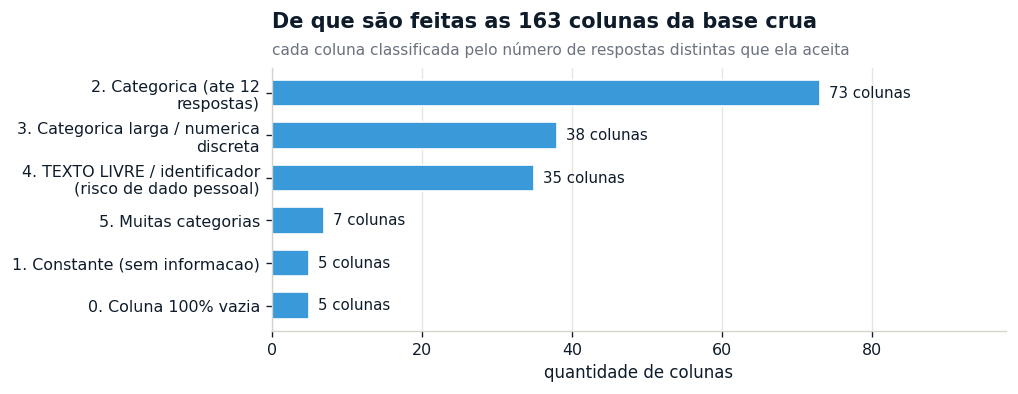

In [ ]:
perfil = []
for c in base.columns:
    s = base[c]
    n_preenchido = int(s.notna().sum())
    n_unicos = int(s.nunique(dropna=True))
    if n_preenchido == 0:
        familia = '0. Coluna 100% vazia'
    elif n_unicos <= 1:
        familia = '1. Constante (sem informacao)'
    elif n_unicos <= 12:
        familia = '2. Categorica (ate 12 respostas)'
    elif n_unicos <= 60:
        familia = '3. Categorica larga / numerica discreta'
    elif n_unicos / max(n_preenchido, 1) > 0.6:
        familia = '4. TEXTO LIVRE / identificador (risco de dado pessoal)'
    else:
        familia = '5. Muitas categorias'
    perfil.append({'coluna': c, 'preenchidas': n_preenchido,
                   'pct_preenchido': 100 * n_preenchido / len(base),
                   'valores_unicos': n_unicos, 'familia': familia})
perfil = pd.DataFrame(perfil).sort_values('pct_preenchido', ascending=False)

resumo_fam = (perfil.groupby('familia')
              .agg(colunas=('coluna', 'size'), preench_medio=('pct_preenchido', 'mean'))
              .round(1).sort_index())
print("=" * 66)
print("RAIO-X 2.2 | AS COLUNAS POR FAMILIA DE COMPORTAMENTO")
print("=" * 66)
print(resumo_fam.to_string())
print("=" * 66)

fig, ax = plt.subplots(figsize=(8.6, 3.4))
ordem = resumo_fam.sort_values('colunas')
barras = ax.barh(quebra(ordem.index, 30), ordem['colunas'], color=SKY, edgecolor='white', height=0.62)
for b, v in zip(barras, ordem['colunas']):
    ax.text(b.get_width() + 1.2, b.get_y() + b.get_height()/2,
            f'{int(v)} coluna' + ('s' if v != 1 else ''),
            va='center', fontsize=9, color=TINTA)
ax.set_xlim(0, ordem['colunas'].max() * 1.34)
enfeita(ax, 'De que são feitas as 163 colunas da base crua',
        'cada coluna classificada pelo número de respostas distintas que ela aceita',
        xlabel='quantidade de colunas', eixo_grade='x')
plt.tight_layout(); plt.show()

**📖 Como ler:** essa contagem é o mapa do trabalho de limpeza.

- As colunas da **família 2** são o material do modelo: perguntas fechadas, poucas respostas possíveis.
- A **família 4** é a zona de risco de privacidade: texto livre, endereço, relato. Ela **não entra**
  no modelo e não pode ser impressa. Voltamos nela em 2.5.
- Colunas **constantes ou 100% vazias** não carregam informação nenhuma e são descarte imediato.

### 2.3 As colunas mais preenchidas e as mais vazias

**🔎 O que vamos fazer:** ver os dois extremos lado a lado. É o jeito mais rápido de perceber
que o preenchimento não é aleatório: ele tem degraus.

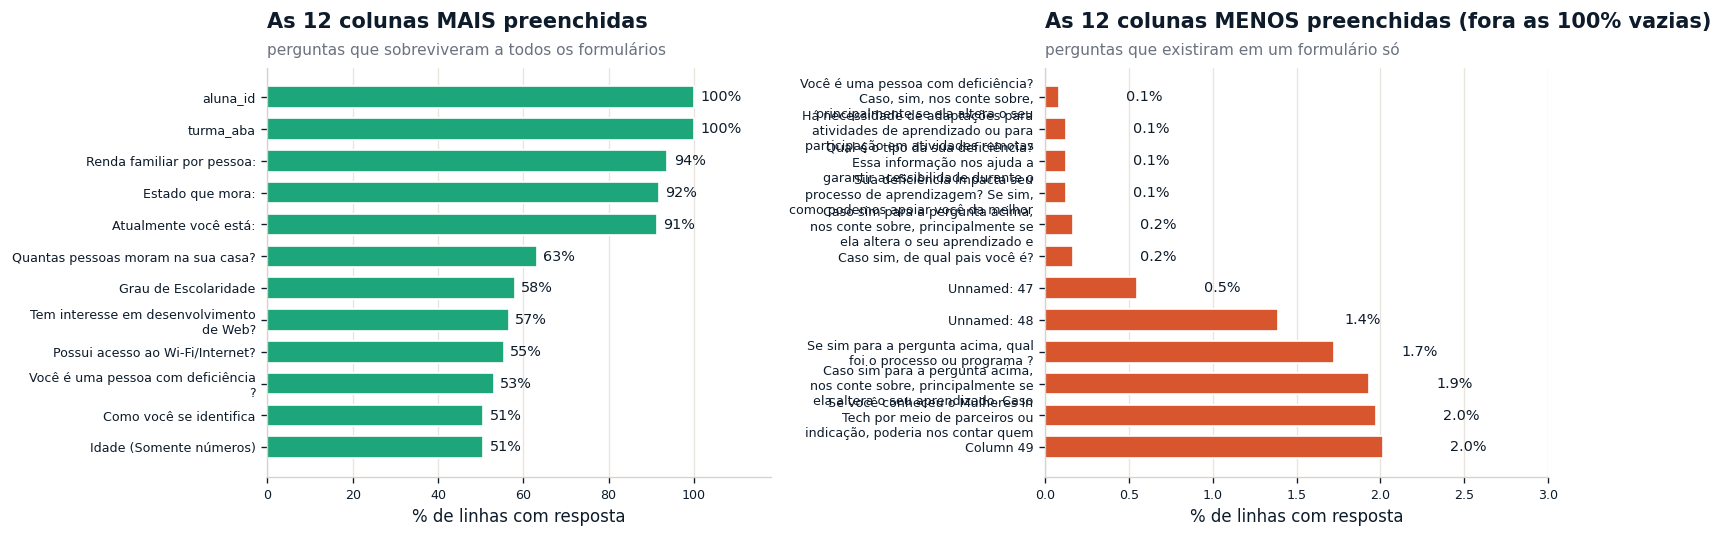

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6))

topo = perfil.nlargest(12, 'pct_preenchido')
b1 = axes[0].barh(quebra(topo['coluna'][::-1], 34), topo['pct_preenchido'][::-1],
                  color=TEAL, edgecolor='white', height=0.68)
for b, v in zip(b1, topo['pct_preenchido'][::-1]):
    axes[0].text(b.get_width() + 1.5, b.get_y() + b.get_height()/2, f'{v:.0f}%',
                 va='center', fontsize=8.6, color=TINTA)
axes[0].set_xlim(0, 118)
enfeita(axes[0], 'As 12 colunas MAIS preenchidas', 'perguntas que sobreviveram a todos os formulários',
        xlabel='% de linhas com resposta', eixo_grade='x')
axes[0].tick_params(labelsize=7.6)

fundo = perfil[perfil['preenchidas'] > 0].nsmallest(12, 'pct_preenchido')
b2 = axes[1].barh(quebra(fundo['coluna'][::-1], 34), fundo['pct_preenchido'][::-1],
                  color=CORAL, edgecolor='white', height=0.68)
for b, v in zip(b2, fundo['pct_preenchido'][::-1]):
    axes[1].text(b.get_width() + 0.4, b.get_y() + b.get_height()/2, f'{v:.1f}%',
                 va='center', fontsize=8.6, color=TINTA)
axes[1].set_xlim(0, max(fundo['pct_preenchido'].max() * 1.45, 3))
enfeita(axes[1], 'As 12 colunas MENOS preenchidas (fora as 100% vazias)',
        'perguntas que existiram em um formulário só', xlabel='% de linhas com resposta', eixo_grade='x')
axes[1].tick_params(labelsize=7.6)

plt.tight_layout(); plt.show()

**📖 Como ler:** o painel da esquerda é a espinha dorsal da base: perguntas que toda turma fez.
O da direita são perguntas de uma edição só. Repare que a escala dos dois é completamente
diferente: à esquerda a régua vai até 100%, à direita mal chega perto disso. **Não compare os dois
gráficos pelo tamanho da barra**, compare pelo número escrito nela. Foi por isso que colocamos o
rótulo em cada barra.

### 2.4 O mapa do vazio: por que as 163 colunas existem

**🔎 O que vamos fazer:** este é o gráfico mais importante do raio-X. Vamos cruzar **coluna × turma**
e pintar o quanto cada pergunta foi preenchida em cada turma.

**A hipótese que ele testa:** se o vazio fosse gente deixando de responder, ele estaria espalhado
por igual. Se o vazio for **formulário diferente por turma**, ele vai aparecer em blocos.

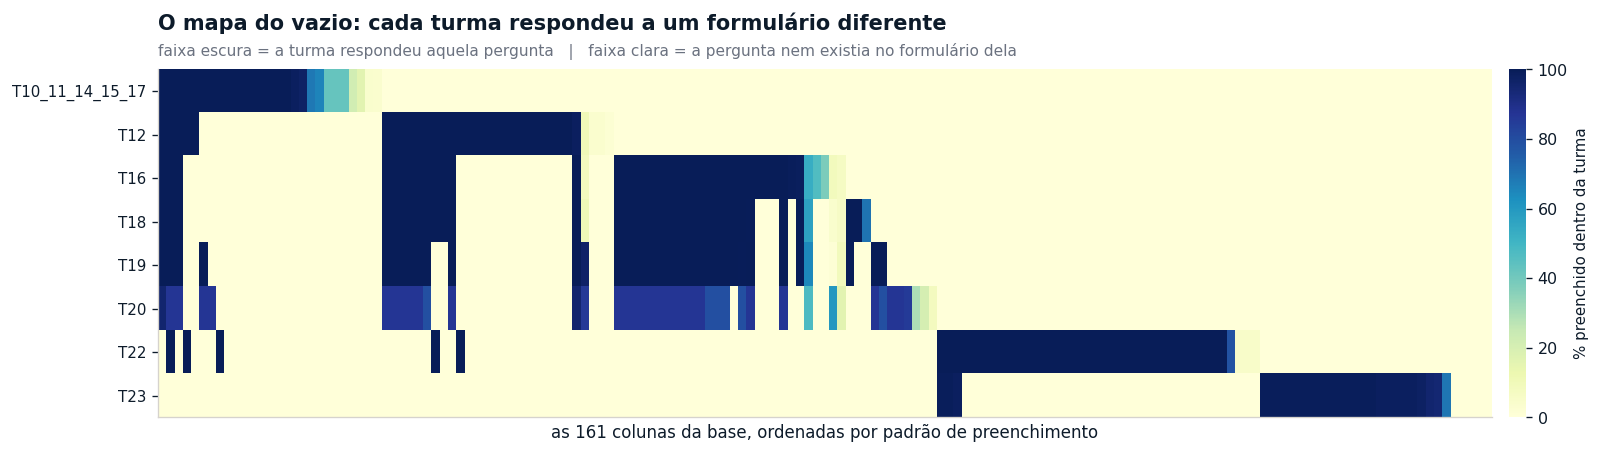

Colunas respondidas por UMA turma so ....... 91
Colunas respondidas por 2 a 4 turmas ....... 35
Colunas respondidas por 5+ turmas .......... 11


In [ ]:
# preenchimento (%) de cada coluna dentro de cada turma
cols_interesse = [c for c in base.columns if c not in ('aluna_id', 'turma_aba')]
mapa = pd.DataFrame({t: base.loc[base['turma_aba'] == t, cols_interesse].notna().mean() * 100
                     for t in base['turma_aba'].dropna().unique()}).T

# ordena colunas pelo padrao de vazio (colunas parecidas ficam vizinhas)
ordem_cols = mapa.T.sort_values(list(mapa.index), ascending=False).index
mapa = mapa[ordem_cols]

fig, ax = plt.subplots(figsize=(13.5, 3.9))
im = ax.imshow(mapa.values, aspect='auto', cmap='YlGnBu', vmin=0, vmax=100)
ax.set_yticks(range(len(mapa.index)))
ax.set_yticklabels(mapa.index, fontsize=9)
ax.set_xticks([]); ax.grid(False)
ax.set_xlabel(f'as {len(ordem_cols)} colunas da base, ordenadas por padrão de preenchimento')
cb = fig.colorbar(im, ax=ax, pad=0.012, fraction=0.03)
cb.set_label('% preenchido dentro da turma', fontsize=9)
cb.outline.set_visible(False)
enfeita(ax, 'O mapa do vazio: cada turma respondeu a um formulário diferente',
        'faixa escura = a turma respondeu aquela pergunta   |   faixa clara = a pergunta nem existia no formulário dela',
        eixo_grade='none')
ax.grid(False)
plt.tight_layout(); plt.show()

# a mesma evidencia em numero
exclusivas = ((mapa > 50).sum(axis=0))
print(f"Colunas respondidas por UMA turma so ....... {int((exclusivas == 1).sum())}")
print(f"Colunas respondidas por 2 a 4 turmas ....... {int(exclusivas.between(2, 4).sum())}")
print(f"Colunas respondidas por 5+ turmas .......... {int((exclusivas >= 5).sum())}")

**📖 Como ler:** o vazio **tem desenho**. Cada faixa horizontal escura é o formulário de uma turma,
e as faixas quase não se sobrepõem. Isso confirma o diagnóstico e muda tudo:

> As 163 colunas não são 163 informações diferentes. São **uma dúzia de perguntas** escritas de
> até cinco jeitos. A base não está suja, ela está **fragmentada**.

E isso define a próxima estação. Se a gente jogasse essa base direto num modelo, cada variável
chegaria 80% vazia e o modelo aprenderia "quem respondeu a pergunta X é da turma Y", que é
exatamente o que **não** queremos aprender. A Estação 3 costura as variantes de volta.

### 2.5 Onde estão os dados pessoais (a checagem de privacidade)

**🔎 O que vamos fazer:** localizar as colunas de risco **sem imprimir nenhum conteúdo delas**.
A gente conta, mede e nomeia a coluna. Nunca mostra a resposta.

In [ ]:
PISTAS = ['endereco', 'endereço', 'cep', 'rua', 'bairro', 'telefone', 'celular', 'whatsapp',
          'e-mail', 'email', 'cpf', 'rg', 'nome completo', 'link', 'linkedin', 'conte', 'relato',
          'por que', 'porque', 'descreva', 'comentario', 'comentário']

def cheira_a_pessoal(nome_col, serie):
    nome = str(nome_col).lower()
    por_nome = any(p in nome for p in PISTAS)
    preench = serie.notna().sum()
    por_forma = preench > 0 and (serie.nunique(dropna=True) / preench) > 0.6 and preench > 30
    return por_nome, por_forma

risco = []
for c in base.columns:
    por_nome, por_forma = cheira_a_pessoal(c, base[c])
    if por_nome or por_forma:
        risco.append({'coluna': str(c)[:70],
                      'motivo': ('nome da pergunta' if por_nome else '') +
                                (' + ' if por_nome and por_forma else '') +
                                ('quase toda resposta é única' if por_forma else ''),
                      'preenchidas': int(base[c].notna().sum())})
risco = pd.DataFrame(risco)

print("=" * 66)
print("RAIO-X 2.5 | COLUNAS COM RISCO DE DADO PESSOAL")
print("=" * 66)
print(f"  Colunas sinalizadas: {len(risco)} de {base.shape[1]}")
print("  Nenhum conteudo dessas colunas e impresso neste notebook.")
print("  Nenhuma delas entra no modelo.")
print("=" * 66)
if len(risco):
    print(risco.head(15).to_string(index=False))
print("\nDECISAO REGISTRADA: o modelo usa apenas variaveis de perfil agregado")
print("(faixa de renda, escolaridade, regiao). Nunca texto livre, nunca contato.")
print("\nDUAS RESSALVAS HONESTAS, para o texto nao prometer mais do que cumpre:")
print("  1. 'Data de nascimento' aparece na lista acima e E usada, mas so para")
print("     calcular a idade. A data em si nunca vira coluna do modelo.")
print("  2. 'aluna_id' e um identificador ANONIMO ja atribuido pela Fly")
print("     (formato 'Aluna 1331'). Ele aparece na fila de prioridade da Estacao 15")
print("     porque a equipe precisa saber de quem esta falando. Confira que ele nao")
print("     virou nome ou e-mail antes de compartilhar qualquer saida.")

RAIO-X 2.5 | COLUNAS COM RISCO DE DADO PESSOAL
  Colunas sinalizadas: 58 de 163
  Nenhum conteudo dessas colunas e impresso neste notebook.
  Nenhuma delas entra no modelo.
                                                                coluna                                         motivo  preenchidas
                                                              aluna_id                    quase toda resposta é única         2380
Caso sim para a pergunta acima, nos conte sobre, principalmente se ela nome da pergunta + quase toda resposta é única           46
       Se sim para a pergunta acima, qual foi o processo ou programa ?                               nome da pergunta           41
Como funciona a situação financeira na sua casa ? (Comente sobre os mo                    quase toda resposta é única         1205
Você é uma pessoa com deficiência? Caso, sim, nos conte sobre, princip                               nome da pergunta            2
Caso sim para a pergunta acima, nos conte

**📖 Como ler:** essa célula é uma **decisão de projeto documentada**, e ela vale ponto na banca.
Um TCC sobre mulheres em situação de vulnerabilidade que imprime endereço de aluna num notebook
público não é um TCC de dados, é um vazamento. A lista acima existe para provar que o grupo sabia
onde estava o risco e escolheu não tocar nele.

---
# 🧵 Estação 3: costurar as 163 colunas em 15 variáveis

**🔎 O que vamos fazer:** transformar o diagnóstico da Estação 2.4 em conserto. Cada **conceito**
(idade, raça, renda...) recebe a lista de **todas as colunas** em que ele pode estar, e a gente
pega, linha a linha, o primeiro valor que não estiver vazio.

**As três ferramentas desta estação:**

| Ferramenta | O que faz | Por que precisa existir |
|---|---|---|
| `coalesce` | percorre as colunas-variantes e devolve o primeiro valor preenchido | mesma pergunta, 5 nomes diferentes |
| `filtra_vocab` | apaga resposta que não pertence àquela pergunta | achamos endereço dentro da coluna de LGBTQIAPN+, formulário desalinhado |
| `norm` | tira espaço, transforma texto vazio em ausente de verdade | `''` e `' '` não são resposta, são ausência disfarçada |

> **O padrão para guardar para a vida:** o mapa de conceitos abaixo é a **documentação viva** da
> base. Chegou turma nova com formulário novo? Adiciona o nome da coluna na lista do conceito e
> o notebook inteiro continua funcionando. É assim que um pipeline sobrevive ao próximo semestre.

In [ ]:
def coalesce(df, colunas):
    """Primeiro valor nao vazio entre as colunas-variantes, linha a linha."""
    existentes = [c for c in colunas if c in df.columns]
    s = pd.Series(np.nan, index=df.index, dtype='object')
    for c in existentes:
        s = s.where(s.notna(), df[c])
    return s

def filtra_vocab(s, permitidos):
    """Resposta fora do vocabulario da pergunta vira vazio (limpa formulario desalinhado)."""
    return s.where(s.isin(permitidos))

def norm(s):
    """Tira espaco e transforma string vazia em ausencia de verdade."""
    s = s.astype('string').str.strip()
    s = s.where(s.notna() & (s != ''))
    return s.astype(object).where(s.notna(), np.nan)

MAPA = {
 'status_aprovacao': ['Aprovadas', 'status_aprovacao', 'Status de aprovação', 'Status'],
 'genero': ['Como você se identifica', 'Qual o seu gênero?',
            'Em relação ao gênero, como você se identifica?'],
 'raca': ['Como você se identifica 2', 'Etnia: Como você se identifica',
          'Como você se identifica?', 'Em relação à raça, como você se identifica?'],
 'lgbt': ['Você faz parte da comunidade LGBTQIA+ ?', 'Você faz parte da comunidade LGBTQIAPN+?',
          'Você faz parte da comunidade LGBTQIAPN+ ?'],
 'idade_txt': ['Idade (Somente números)', 'Qual sua idade?'],
 'nascimento': ['Qual a sua data de nascimento?', 'Data de nascimento'],
 'escolaridade_txt': ['Grau de Escolaridade', 'Grau de escolaridade',
                      'Qual é o seu nível de escolaridade?'],
 'estado_txt': ['Estado que mora:', 'Estado/Região que mora:'],
 'renda_faixa': ['Renda familiar por pessoa:',
                 'Qual é a renda familiar aproximada por pessoa na sua casa?'],
 'pessoas_casa_txt': ['Quantas pessoas moram na sua casa?',
                      'Quantas pessoas moram na sua casa? (somente números)',
                      'Quantas pessoas moram na sua casa?.1'],
 'computador_txt': ['Possui computador?', 'Possui computador em casa?',
                    'Você possui computador para acompanhar as aulas e realizar a atividades do curso?',
                    'Qual dispositivo você pretende usar para acompanhar o curso?'],
 'internet_txt': ['Possui acesso ao Wi-Fi/Internet?', 'Você possui acesso a Internet?',
                  'Qual é a sua forma mais frequente de acesso à internet?'],
 'mae_cuidadora': ['Você possui filhos ou exerce papel de mãe/cuidadora?'],
 'disponibilidade_txt': ['Qual sua disponibilidade verdadeiramente de tempo para estudar e dedicar no curso:',
                         'Quanto tempo você consegue dedicar ao curso por semana?'],
 'deficiencia': ['Você é uma pessoa com deficiência ?', 'Você é uma pessoa com deficiência?'],
}

# variantes de nome GIGANTE (perguntas que comecam com um texto de acolhimento): achamos por prefixo
extras_lgbt = [c for c in base.columns if str(c).startswith('Você faz parte da comunidade LGBTQIA+?')]
MAPA['lgbt'] = MAPA['lgbt'] + [c for c in extras_lgbt if c not in MAPA['lgbt']]
extras_disp = [c for c in base.columns
               if str(c).startswith('A gente sabe que a vida é bem corrida')
               or str(c).startswith('Sabemos que a rotina pode ser corrida')]
MAPA['disponibilidade_txt'] = (MAPA['disponibilidade_txt'][:1] + extras_disp
                               + MAPA['disponibilidade_txt'][1:])

# quantas colunas-variantes cada conceito recolheu (o "antes")
antes = {}
for conceito, variantes in MAPA.items():
    existentes = [c for c in variantes if c in base.columns]
    antes[conceito] = {'n_variantes': len(existentes),
                       'pior_preenchimento': (min([base[c].notna().mean()*100 for c in existentes])
                                              if existentes else 0.0),
                       'melhor_variante': (max([base[c].notna().mean()*100 for c in existentes])
                                           if existentes else 0.0)}

H = pd.DataFrame({'aluna_id': base['aluna_id'], 'turma_aba': base['turma_aba']})
# nome curto da turma (T10, T11, ...), que so existe nas turmas antigas; nas outras fica a aba
H['turma'] = base['Turma'].astype('string').str.extract(r'Turma\s*(\d+)')[0].radd('T').fillna(base['turma_aba'])
for conceito, variantes in MAPA.items():
    H[conceito] = norm(coalesce(base, variantes))

depois = {c: H[c].notna().mean()*100 for c in MAPA}
print(f"{len(MAPA)} conceitos costurados a partir de "
      f"{sum(v['n_variantes'] for v in antes.values())} colunas-variantes.\n")
print(f"{'conceito':22s} {'variantes':>10s} {'melhor sozinha':>15s} {'depois do coalesce':>20s}")
print('-' * 70)
for c in MAPA:
    print(f"{c:22s} {antes[c]['n_variantes']:>10d} "
          f"{antes[c]['melhor_variante']:>14.0f}% {depois[c]:>19.0f}%")

15 conceitos costurados a partir de 40 colunas-variantes.

conceito                variantes  melhor sozinha   depois do coalesce
----------------------------------------------------------------------
status_aprovacao                1             49%                  49%
genero                          3             51%                  94%
raca                            4             51%                  99%
lgbt                            4             51%                  94%
idade_txt                       2             51%                  86%
nascimento                      2              5%                   8%
escolaridade_txt                3             58%                  99%
estado_txt                      2             92%                  92%
renda_faixa                     2             94%                  99%
pessoas_casa_txt                2             63%                  94%
computador_txt                  4             51%                  97%
internet_txt      

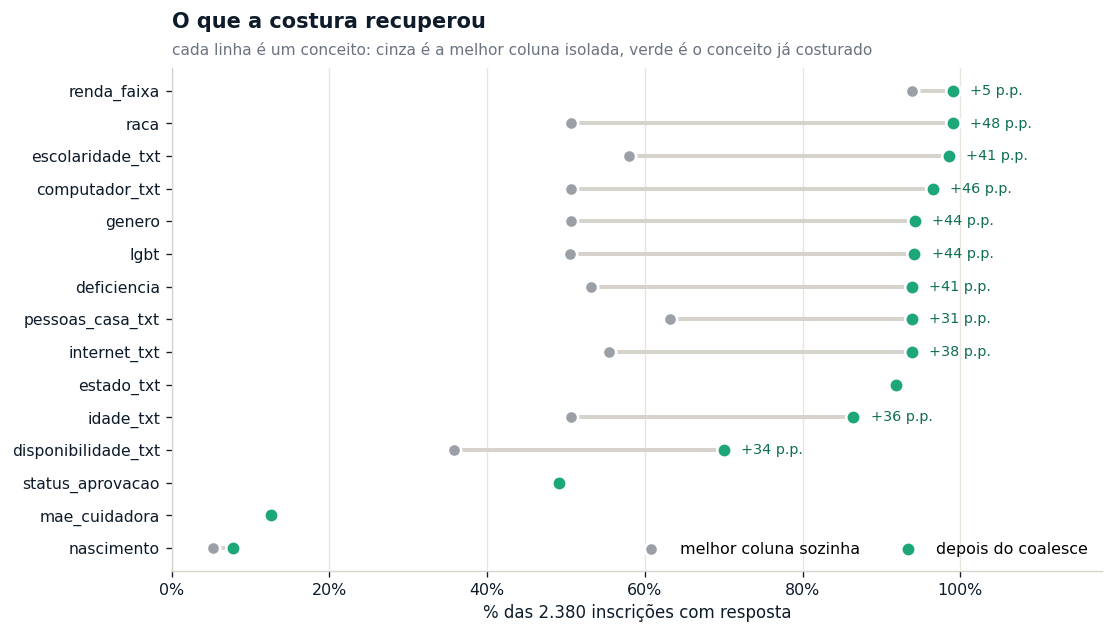

In [ ]:
# o ganho do coalesce, em um grafico
comp = pd.DataFrame({'melhor coluna sozinha': [antes[c]['melhor_variante'] for c in MAPA],
                     'depois do coalesce':    [depois[c] for c in MAPA]}, index=list(MAPA))
comp = comp.sort_values('depois do coalesce')

fig, ax = plt.subplots(figsize=(9.4, 5.4))
y = np.arange(len(comp))
ax.hlines(y, comp['melhor coluna sozinha'], comp['depois do coalesce'],
          color='#d6d3cd', lw=2.4, zorder=1)
ax.scatter(comp['melhor coluna sozinha'], y, s=64, color=CINZA, zorder=3,
           edgecolor='white', linewidth=1.6, label='melhor coluna sozinha')
ax.scatter(comp['depois do coalesce'], y, s=76, color=TEAL, zorder=3,
           edgecolor='white', linewidth=1.6, label='depois do coalesce')
for i, (a, d) in enumerate(zip(comp['melhor coluna sozinha'], comp['depois do coalesce'])):
    if d - a >= 3:
        ax.text(d + 2.2, i, f'+{d-a:.0f} p.p.', va='center', fontsize=8.6, color=TEAL_ESCURO)
ax.set_yticks(y); ax.set_yticklabels(comp.index, fontsize=9.4)
ax.set_xlim(0, 118); ax.xaxis.set_major_formatter(PercentFormatter())
enfeita(ax, 'O que a costura recuperou',
        'cada linha é um conceito: cinza é a melhor coluna isolada, verde é o conceito já costurado',
        xlabel='% das 2.380 inscrições com resposta', eixo_grade='x')
ax.legend(loc='lower right', ncols=2)
plt.tight_layout(); plt.show()

**📖 Como ler:** cada linha é um conceito e o tamanho da linha cinza é o quanto a costura recuperou.
Conceitos como **disponibilidade** e **computador** só existem porque juntamos variantes: sozinha,
nenhuma das colunas originais tinha resposta suficiente para entrar num modelo.

E repare no conceito que **não** melhorou: `mae_cuidadora` tem uma variante só e continua baixíssimo.
Guarde esse nome. Ele é a hipótese H2 do grupo, e a Estação 5 vai mostrar que ele está
estatisticamente morto.

### 3.2 Padronizar cada conceito: de resposta escrita para variável utilizável

**🔎 O que vamos fazer:** um conceito costurado ainda não é uma variável. "Feminino" e "Mulher Cis"
são a mesma resposta escrita de dois jeitos; "3 a 5 horas por dia" é texto, e o modelo precisa de
número. Esta célula faz quatro tipos de conversão, e cada uma está comentada:

1. **Unificar sinônimos** (`Feminino` e `Mulher` viram `Mulher Cis`).
2. **Ordenar o que tem ordem** (escolaridade e renda viram escala crescente, porque a ordem é
   informação de verdade: quem tem pós está *acima* de quem tem médio).
3. **Extrair número de texto** (faixa de horas vira o ponto médio em horas por dia).
4. **Resgatar valor quebrado** (a idade que veio como `27081982`, que é uma data colada; esta é a
   técnica que o grupo já tinha inventado no V10).

In [ ]:
ANO_REF = 2026
H_bruto = H.copy()      # guardamos o "antes" para medir o que a padronizacao vai descartar

# 1) sinonimos e vocabulario fechado
H['genero'] = H['genero'].replace({'Feminino': 'Mulher Cis', 'Mulher': 'Mulher Cis',
                                   'Mulher Trans': 'Mulher Transgênero',
                                   'Não-Binário': 'Não-binárie', 'Não-Binárie': 'Não-binárie'})
H['genero']        = filtra_vocab(H['genero'], ['Mulher Cis', 'Mulher Transgênero', 'Não-binárie', 'Outro'])
H['raca']          = filtra_vocab(H['raca'], ['Preta', 'Parda', 'Branca', 'Indígena', 'Amarela'])
H['lgbt']          = filtra_vocab(H['lgbt'], ['Sim', 'Não', 'Prefiro não responder'])
H['mae_cuidadora'] = filtra_vocab(H['mae_cuidadora'], ['Sim', 'Não'])
H['deficiencia']   = filtra_vocab(H['deficiencia'], ['Sim', 'Não'])

# 2) idade: numero direto OU resgatada da "data colada" OU calculada do nascimento
idade = pd.to_numeric(H['idade_txt'], errors='coerce')
mask_data = idade > 1_000_000                      # ex.: 27081982 = 27/08/1982
n_resgatadas = int(mask_data.sum())
idade.loc[mask_data] = ANO_REF - (idade[mask_data] % 10000)
nasc = pd.to_datetime(H['nascimento'], errors='coerce', dayfirst=True)
n_por_nascimento = int((idade.isna() & nasc.notna()).sum())
idade = idade.where(idade.notna(), ANO_REF - nasc.dt.year)
H['idade'] = idade.where((idade >= 14) & (idade <= 80))   # fora disso e erro de digitacao

# 3) escalas ordenadas (a ordem e informacao)
esc_map = {'Ensino Fundamental Incompleto': 1, 'Ensino Fundamental Completo': 2,
           'Ensino Médio Incompleto': 2, 'Ensino Médio Completo': 3, 'Ensino Técnico': 3,
           'Ensino Superior Incompleto (Graduação)': 4, 'Ensino Superior Incompleto': 4,
           'Ensino Superior Completo (Graduação)': 5, 'Ensino Superior Completo': 5,
           'Pós-graduação': 6, 'Pós-graduação (Especialização, Mestrado ou Doutorado)': 6}
H['escolaridade'] = H['escolaridade_txt'].map(esc_map)

renda_map = {'Menos de 1 salário mínimo por pessoa': 0, 'Menos de 1 salário mínimo': 0,
             'De 1 a 2 salários mínimos por pessoa': 1, 'Entre 1 e 2 salários mínimos': 1,
             'Entre 2 e 3 salários mínimos': 2, 'De 3 a 5 salários mínimos por pessoa': 2,
             'Mais de 3 salários mínimos': 3, 'Mais de 5 salários mínimos por pessoa': 3}
H['renda_ord'] = H['renda_faixa'].map(renda_map)

# 4) faixa de texto -> numero (ponto medio da faixa, em horas por dia)
disp_map = {'Até 1 hora por dia': 0.5, '1 a 2 horas por dia': 1.5, '2 a 3 horas por dia': 2.5,
            '3 a 5 horas por dia': 4.0, '3 horas ou mais por dia': 4.0, 'Mais de 5 horas por dia': 6.0,
            'Somente aos finais de semana': 0.7, 'Até 5 horas': 0.7, '5 a 10 horas': 1.5,
            'Mais de 10 horas': 2.0}
H['disponibilidade_h'] = H['disponibilidade_txt'].map(disp_map)

# 5) equipamento e conexao: resposta aberta -> binaria com regra escrita
def tem_pc(v):
    if pd.isna(v): return np.nan
    v = str(v).lower()
    if 'notebook' in v or 'computador' in v or v == 'sim': return 'Sim'
    if v in ('não', 'nao'): return 'Não'
    return 'Não' if ('celular' in v or 'smartphone' in v or 'tablet' in v) else np.nan
H['tem_computador'] = H['computador_txt'].map(tem_pc)
H['tem_internet']   = H['internet_txt'].map(
    lambda v: np.nan if pd.isna(v) else ('Não' if str(v).strip().lower() in ('não', 'nao') else 'Sim'))

H['pessoas_casa'] = pd.to_numeric(H['pessoas_casa_txt'], errors='coerce')
H['pessoas_casa'] = H['pessoas_casa'].where((H['pessoas_casa'] >= 1) & (H['pessoas_casa'] <= 15))

# 6) estado -> regiao (menos categorias, mais alunas por categoria)
SIGLA = {'AC':'N','AM':'N','AP':'N','PA':'N','RO':'N','RR':'N','TO':'N',
         'AL':'NE','BA':'NE','CE':'NE','MA':'NE','PB':'NE','PE':'NE','PI':'NE','RN':'NE','SE':'NE',
         'DF':'CO','GO':'CO','MT':'CO','MS':'CO',
         'ES':'SE','MG':'SE','RJ':'SE','SP':'SE',
         'PR':'S','RS':'S','SC':'S'}
NOME_UF = {'acre':'AC','amazonas':'AM','amapá':'AP','pará':'PA','rondônia':'RO','roraima':'RR',
           'tocantins':'TO','alagoas':'AL','bahia':'BA','ceará':'CE','maranhão':'MA','paraíba':'PB',
           'pernambuco':'PE','piauí':'PI','rio grande do norte':'RN','sergipe':'SE',
           'distrito federal':'DF','goiás':'GO','mato grosso':'MT','mato grosso do sul':'MS',
           'espírito santo':'ES','minas gerais':'MG','rio de janeiro':'RJ','são paulo':'SP',
           'paraná':'PR','rio grande do sul':'RS','santa catarina':'SC'}

def para_regiao(v):
    if pd.isna(v): return np.nan
    t = str(v).strip()
    if t.upper() in SIGLA: return SIGLA[t.upper()]
    chave = unicodedata.normalize('NFC', t.lower())
    if chave in NOME_UF: return SIGLA[NOME_UF[chave]]
    for uf, sig in NOME_UF.items():
        if uf in chave: return SIGLA[sig]
    return np.nan
H['regiao'] = H['estado_txt'].map(para_regiao)

harm = H[['aluna_id', 'turma_aba', 'turma', 'status_aprovacao', 'genero', 'raca', 'lgbt',
          'mae_cuidadora', 'deficiencia', 'idade', 'escolaridade', 'renda_ord',
          'disponibilidade_h', 'tem_computador', 'tem_internet', 'pessoas_casa', 'regiao']].copy()

# QUANTO A PADRONIZACAO DESCARTOU EM SILENCIO (resposta fora do vocabulario previsto).
# Sem esta conferencia, um rotulo novo de uma turma nova sumiria sem ninguem notar.
PARES = [('genero', 'genero'), ('raca', 'raca'), ('lgbt', 'lgbt'),
         ('deficiencia', 'deficiencia'), ('mae_cuidadora', 'mae_cuidadora'),
         ('escolaridade_txt', 'escolaridade'), ('renda_faixa', 'renda_ord'),
         ('disponibilidade_txt', 'disponibilidade_h'), ('estado_txt', 'regiao')]
print("\nO QUE A PADRONIZACAO DESCARTOU (resposta que nao entrou em nenhuma categoria):")
print(f"{'conceito':20s} {'tinha':>8s} {'ficou':>8s} {'perdeu':>8s}  rotulos mais descartados")
print('-' * 96)
for origem, destino in PARES:
    bruto = H_bruto[origem] if origem in H_bruto.columns else pd.Series(dtype=object)
    limpo = harm[destino] if destino in harm.columns else H[destino]
    bruto = bruto.reindex(limpo.index)
    perdeu = int((bruto.notna() & limpo.isna()).sum())
    exemplos = (bruto[bruto.notna() & limpo.isna()].astype(str).str.slice(0, 26)
                .value_counts().head(3))
    amostra = ' | '.join(f'{k} ({v})' for k, v in exemplos.items()) if len(exemplos) else '-'
    print(f"{destino:20s} {int(bruto.notna().sum()):8d} {int(limpo.notna().sum()):8d} "
          f"{perdeu:8d}  {amostra[:52]}")
print("\nPerda ZERO significa que o vocabulario cobriu todas as respostas.")
print("Perda alta significa que falta um rotulo no mapa, e o conserto e adicionar")
print("esse rotulo ao dicionario da celula acima, nao ignorar a linha.")

print(f"Idades resgatadas de data colada .......... {n_resgatadas}")
print(f"Idades calculadas da data de nascimento ... {n_por_nascimento}")
print(f"\nBASE HARMONIZADA: {harm.shape[0]:,} linhas x {harm.shape[1]} colunas".replace(',', '.'))
print("Esta base PODE dar head: zero dado identificavel.\n")
harm.drop(columns=['aluna_id']).head(6)


O QUE A PADRONIZACAO DESCARTOU (resposta que nao entrou em nenhuma categoria):
conceito                tinha    ficou   perdeu  rotulos mais descartados
------------------------------------------------------------------------------------------------
genero                   2242     2208       34  Masculino (3) | Travesti (3) | Ama de casa (3)
raca                     2358     2340       18  Soltera (4) | Solteira (4) | Casada (2)
lgbt                     2241     2217       24  Simpatizante (2) | Não sei (1) | Prefiro não dizer (
deficiencia              2233     2230        3  Prefiro não responder (2) | Não se o significado (1)
mae_cuidadora             300      287       13  Mulher Cis (12) | Mulher (1)
escolaridade             2345     2064      281  Ensino Técnico Completo (100) | Ensino superior comp
renda_ord                2358     2345       13  +5548991278427 (1) | 95991529676 (1) | +559599172016
disponibilidade_h        1666     1666        0  -
regiao                   21

,turma_aba,turma,status_aprovacao,genero,raca,lgbt,mae_cuidadora,deficiencia,idade,escolaridade,renda_ord,disponibilidade_h,tem_computador,tem_internet,pessoas_casa,regiao
0,T10_11_14_15_17,T10,Não aprovadas,Mulher Cis,Branca,Sim,NaN,Sim,31.0,1.0,0.0,1.5,Sim,Sim,NaN,CO
1,T10_11_14_15_17,T10,Não aprovadas,Mulher Cis,Parda,Não,NaN,Não,17.0,2.0,0.0,4.0,Não,Sim,NaN,NE
2,T10_11_14_15_17,T10,Não aprovadas,Mulher Cis,Parda,Não,NaN,Não,17.0,2.0,0.0,1.5,Não,Sim,NaN,NE
3,T10_11_14_15_17,T10,Não aprovadas,Mulher Cis,Parda,Não,NaN,Não,20.0,2.0,0.0,1.5,Não,Sim,NaN,NE
4,T10_11_14_15_17,T10,NaN,Mulher Cis,Parda,Não,NaN,Não,17.0,2.0,0.0,4.0,Não,Sim,NaN,NE
5,T10_11_14_15_17,T10,Não aprovadas,Não-binárie,Branca,Sim,NaN,Não,18.0,2.0,0.0,1.5,Não,Sim,NaN,NE


**📖 Como ler:** as 163 colunas viraram 15 conceitos com nome em português, valor padronizado e regra
de construção escrita. Da linha de cima até aqui, nenhuma decisão foi automática: **cada mapa acima
é uma escolha do grupo**, e é isso que a banca vai perguntar. Duas escolhas para defender na
apresentação:

- **Escolaridade e renda viraram escala ordenada, não categorias soltas.** Isso assume que a
  distância entre "médio completo" e "superior incompleto" é parecida com a distância entre
  "superior incompleto" e "superior completo". É uma simplificação consciente, e ela existe porque
  com 166 alunas não há espaço para gastar 6 colunas de one-hot num conceito só.
- **Estado virou região.** Com o n que temos, 27 estados dariam categorias de 2 ou 3 alunas, e
  categoria de 3 alunas não ensina nada a um modelo. Cinco regiões dão grupos com tamanho utilizável.

---
# 📖 Estação 4: o dicionário das variáveis

**🔎 O que vamos fazer:** montar a ficha de cada variável: o que ela mede, de que tipo ela é, como
foi construída, quais valores aceita e quanto está preenchida.

**Por que isso é entregável e não burocracia:** o dicionário é o que permite outra pessoa (a Fly,
a banca, a turma do ano que vem) usar essa base sem perguntar nada para o grupo. Sem ele, a
harmonização da Estação 3 é uma caixa-preta que só vocês sabem abrir.

In [ ]:
DICIONARIO = [
 ('idade',             'numérica',   'anos completos em 2026',
  'número direto, ou resgatado de data colada, ou calculado da data de nascimento; válido entre 14 e 80'),
 ('escolaridade',      'ordinal 1-6','maior nível de estudo declarado',
  '1: fundamental incompleto; 2: fundamental completo e médio incompleto; 3: médio completo '
  'e técnico; 4: superior incompleto; 5: superior completo; 6: pós-graduação'),
 ('renda_ord',         'ordinal 0-3','renda familiar POR PESSOA, em salários mínimos',
  '0: "menos de 1 SM"; 1: "de 1 a 2"; 2: "entre 2 e 3" e "de 3 a 5"; 3: "mais de 3" e "mais de 5". '
  'Os formulários usavam faixas diferentes: a equivalência acima é uma escolha do grupo'),
 ('disponibilidade_h', 'numérica',   'horas por DIA que a aluna declarou poder estudar',
  'ponto médio da faixa; formulários que perguntavam por SEMANA foram divididos por 7 '
  '("até 5h/semana" vira 0,7 h/dia). Atenção: só o formulário antigo tinha opções acima de 2 h/dia'),
 ('pessoas_casa',      'numérica',   'quantas pessoas moram na casa',
  'número declarado, válido entre 1 e 15'),
 ('raca',              'categórica', 'autodeclaração de raça/cor',
  'Preta, Parda, Branca, Indígena, Amarela'),
 ('genero',            'categórica', 'autodeclaração de gênero',
  'Mulher Cis, Mulher Transgênero, Não-binárie, Outro'),
 ('lgbt',              'categórica', 'pertence à comunidade LGBTQIAPN+',
  'Sim, Não, Prefiro não responder'),
 ('deficiencia',       'categórica', 'é pessoa com deficiência',
  'Sim, Não'),
 ('mae_cuidadora',     'categórica', 'tem filhos ou exerce papel de mãe/cuidadora',
  'Sim, Não  (pergunta que só existiu em parte dos formulários)'),
 ('tem_computador',    'categórica', 'tem computador ou notebook para acompanhar o curso',
  'Sim; celular ou tablet como único aparelho conta como Não'),
 ('tem_internet',      'categórica', 'tem acesso à internet',
  'Sim, Não'),
 ('regiao',            'categórica', 'região do país onde mora',
  'N, NE, CO, SE, S  (derivada do estado)'),
 ('turma_aba',         'contexto',   'turma/edição em que se inscreveu',
  'NÃO entra no modelo: identifica o grupo, não a pessoa'),
]
dic = pd.DataFrame(DICIONARIO, columns=['variavel', 'tipo', 'o que mede', 'como foi construida'])
dic['% preenchido'] = [round(harm[v].notna().mean()*100) if v in harm.columns else np.nan
                       for v in dic['variavel']]
dic['n com resposta'] = [int(harm[v].notna().sum()) if v in harm.columns else 0
                         for v in dic['variavel']]
dic = dic.sort_values('% preenchido', ascending=False).reset_index(drop=True)
dic

,variavel,tipo,o que mede,como foi construida,% preenchido,n com resposta
0,turma_aba,contexto,turma/edição em que se inscreveu,"NÃO entra no modelo: identifica o grupo, não a...",100,2380
1,renda_ord,ordinal 0-3,"renda familiar POR PESSOA, em salários mínimos","0: ""menos de 1 SM""; 1: ""de 1 a 2""; 2: ""entre 2...",99,2345
2,raca,categórica,autodeclaração de raça/cor,"Preta, Parda, Branca, Indígena, Amarela",98,2340
3,tem_computador,categórica,tem computador ou notebook para acompanhar o c...,Sim; celular ou tablet como único aparelho con...,96,2284
4,tem_internet,categórica,tem acesso à internet,"Sim, Não",94,2233
5,deficiencia,categórica,é pessoa com deficiência,"Sim, Não",94,2230
6,genero,categórica,autodeclaração de gênero,"Mulher Cis, Mulher Transgênero, Não-binárie, O...",93,2208
7,lgbt,categórica,pertence à comunidade LGBTQIAPN+,"Sim, Não, Prefiro não responder",93,2217
8,regiao,categórica,região do país onde mora,"N, NE, CO, SE, S (derivada do estado)",90,2141
9,idade,numérica,anos completos em 2026,"número direto, ou resgatado de data colada, ou...",88,2088


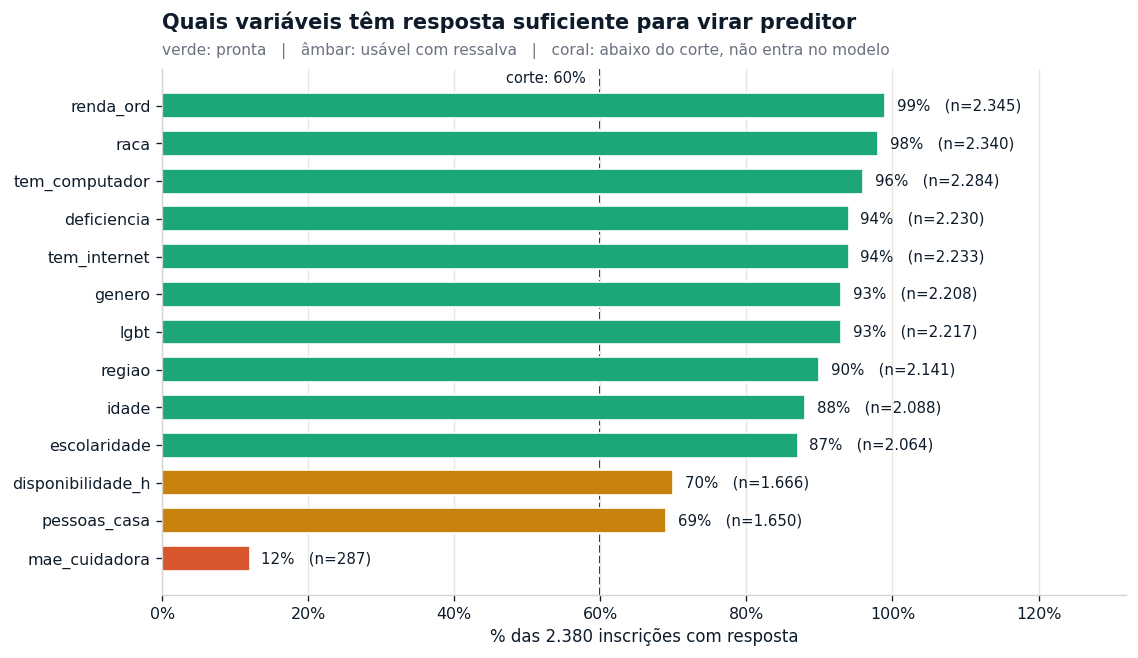

FORA DO MODELO por falta de resposta: ['mae_cuidadora']


In [ ]:
# o mesmo dicionario, visualmente: quem esta pronta para modelar e quem nao esta
LIMITE_USO = 60   # abaixo disso a variavel entra so como contexto, nunca como preditora

d = dic[dic['tipo'] != 'contexto'].sort_values('% preenchido')
cores = [TEAL if p >= 85 else (AMBER if p >= LIMITE_USO else CORAL) for p in d['% preenchido']]

fig, ax = plt.subplots(figsize=(9.6, 5.6))
barras = ax.barh(d['variavel'], d['% preenchido'], color=cores, edgecolor='white', height=0.66)
for b, p, n in zip(barras, d['% preenchido'], d['n com resposta']):
    ax.text(b.get_width() + 1.6, b.get_y() + b.get_height()/2, f'{p:.0f}%   (n={n:,})'.replace(',', '.'),
            va='center', fontsize=9, color=TINTA)
ax.axvline(LIMITE_USO, color=TINTA, lw=1.2, ls='--', zorder=0)
ax.text(LIMITE_USO - 2, len(d) - 0.4, 'corte: 60%', ha='right', fontsize=8.8, color=TINTA)
ax.set_xlim(0, 132); ax.xaxis.set_major_formatter(PercentFormatter())
enfeita(ax, 'Quais variáveis têm resposta suficiente para virar preditor',
        'verde: pronta   |   âmbar: usável com ressalva   |   coral: abaixo do corte, não entra no modelo',
        xlabel='% das 2.380 inscrições com resposta', eixo_grade='x')
plt.tight_layout(); plt.show()

fracas = d[d['% preenchido'] < LIMITE_USO]['variavel'].tolist()
print("FORA DO MODELO por falta de resposta:", fracas if fracas else 'nenhuma')

**📖 Como ler:** a barra coral é o primeiro prego no caixão da hipótese H2. `mae_cuidadora` é
exatamente a variável que a literatura de evasão aponta como uma das mais fortes para mulheres
adultas, e ela é a **menos preenchida da base**, porque a pergunta só apareceu em parte dos
formulários.

Isso não é azar. É a informação mais acionável do TCC inteiro:

> A Fly não deixou de coletar um dado qualquer. Deixou de coletar justamente o dado que mais
> provavelmente explicaria a evasão das alunas dela.

Escreva essa frase no trabalho. Ela vale mais que qualquer F1.

---
# 📊 Estação 5: como cada variável ficou distribuída

**🔎 O que vamos fazer:** olhar **uma variável por vez**, sem cruzar com nada. Isso se chama análise
univariada e é o passo que quase todo mundo pula para correr atrás de correlação.

**Três perguntas que só a univariada responde:**

1. Quem é a aluna típica da Fly? (o retrato do público)
2. Alguma categoria tem tão pouca gente que vai virar ruído no modelo?
3. Alguma variável é quase constante, ou seja, quase todo mundo respondeu a mesma coisa?

A pergunta 3 é decisiva: **variável em que 97% respondem a mesma coisa não consegue separar
ninguém de ninguém**, por melhor que seja a teoria por trás dela.

### 5.1 O retrato do público: todas as variáveis categóricas

**🔎 O que vamos fazer:** um painel com a distribuição de cada variável categórica, em % e com o
n escrito em cada barra.

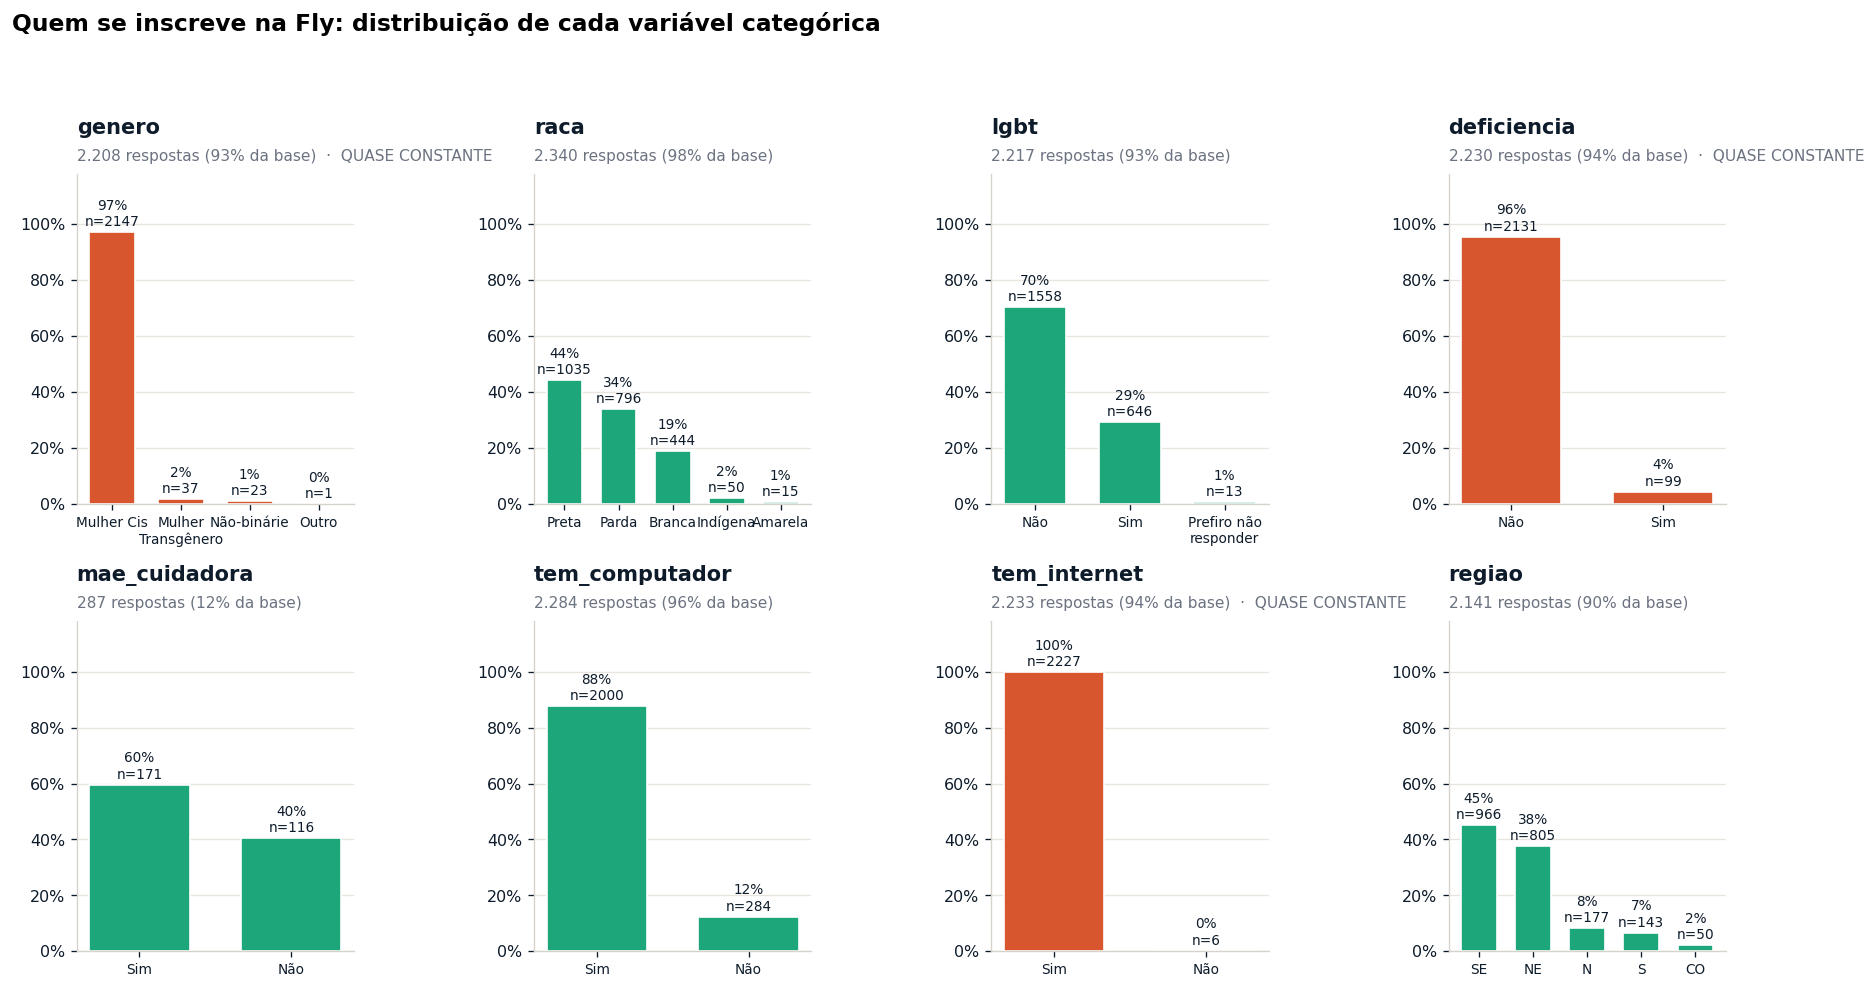

In [ ]:
CATS = ['genero', 'raca', 'lgbt', 'deficiencia', 'mae_cuidadora',
        'tem_computador', 'tem_internet', 'regiao']

fig, axes = plt.subplots(2, 4, figsize=(15.4, 8.2))
for ax, col in zip(axes.ravel(), CATS):
    vc = harm[col].value_counts(dropna=True)
    pct = 100 * vc / vc.sum()
    dominante = pct.max()
    cor = [CORAL if dominante >= 90 else TEAL] * len(vc)
    barras = ax.bar(range(len(vc)), pct.values, color=cor, edgecolor='white', width=0.66)
    for i, (p, n) in enumerate(zip(pct.values, vc.values)):
        ax.text(i, p + 2.2, f'{p:.0f}%\nn={n}', ha='center', fontsize=8.2, color=TINTA)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(quebra(vc.index, 11), fontsize=8.2)
    ax.set_ylim(0, 118)
    ax.yaxis.set_major_formatter(PercentFormatter())
    resp = harm[col].notna().sum()
    aviso = '  ·  QUASE CONSTANTE' if dominante >= 90 else ''
    enfeita(ax, col,
            f'{resp:,} respostas ({100*resp/len(harm):.0f}% da base){aviso}'.replace(',', '.'))
fig.suptitle('Quem se inscreve na Fly: distribuição de cada variável categórica',
             fontsize=14, weight='bold', x=0.006, ha='left', y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.955]); plt.show()

**📖 Como ler:** duas leituras diferentes saem daqui, e é importante não confundir.

**A leitura de impacto social (para a introdução do TCC):** o público da Fly é majoritariamente de
mulheres negras (pretas e pardas somadas), com renda baixa e sem computador próprio em boa parte
dos casos. O programa está acertando o público-alvo dele, e isso merece estar escrito.

**A leitura de modelagem (para a Estação 9):** toda barra marcada como **quase constante** é uma
variável que o modelo não vai conseguir usar. Se 93% das alunas respondem "Não" em `deficiencia`,
o modelo não tem com o que comparar. A variável continua importante para a política pública da Fly,
mas é inútil como preditor **neste conjunto de dados**. Essas duas frases não se contradizem, e
saber diferenciá-las é metade da maturidade estatística de um TCC.

### 5.2 As variáveis numéricas: onde está a massa e onde estão os extremos

**🔎 O que vamos fazer:** histograma com a mediana marcada e uma caixa de resumo. O histograma
mostra o formato, e a mediana mostra o centro sem se deixar puxar por valor extremo.

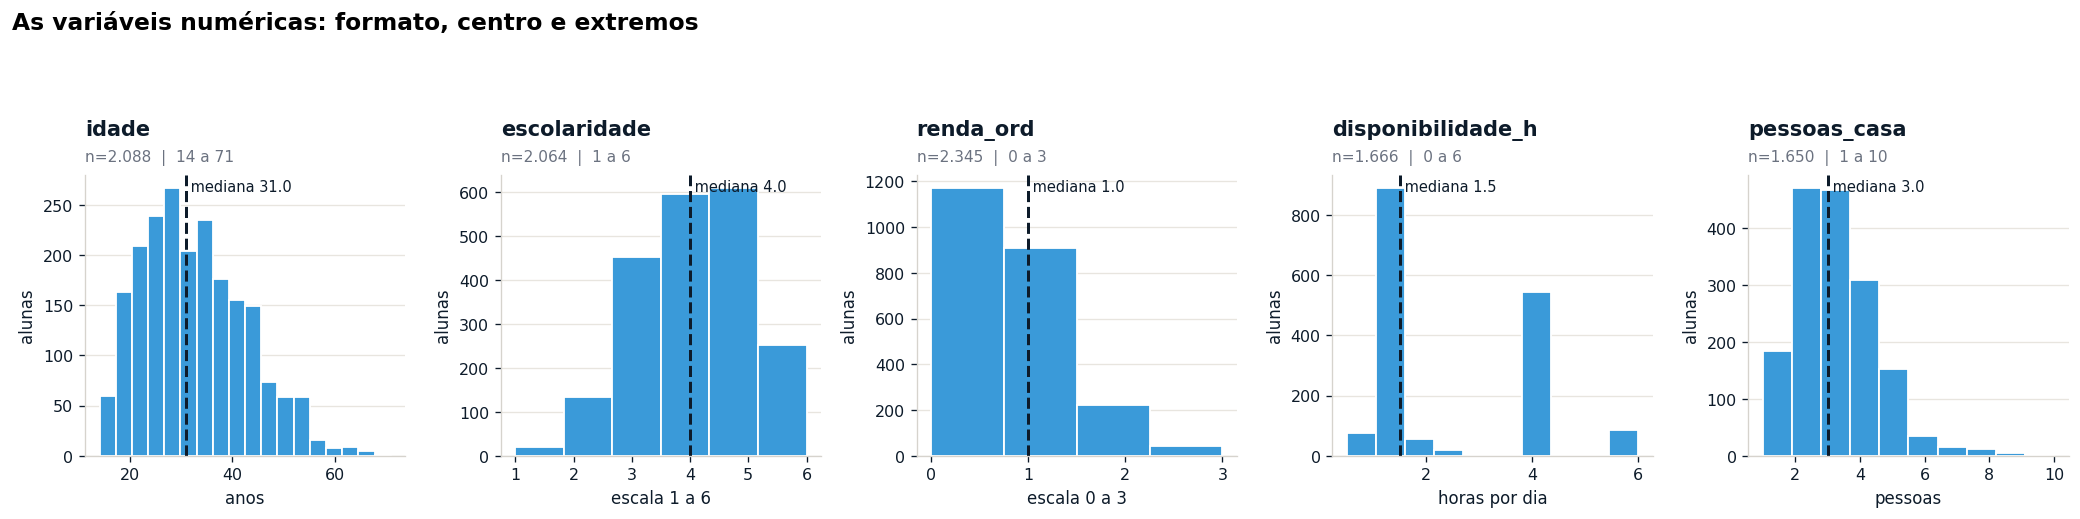

         idade  escolaridade  renda_ord  disponibilidade_h  pessoas_casa
count  2088.00       2064.00    2345.00            1666.00       1650.00
mean     32.59          4.16       0.63               2.54          3.02
std      10.13          1.15       0.73               1.43          1.38
min      14.00          1.00       0.00               0.50          1.00
25%      25.00          3.00       0.00               1.50          2.00
50%      31.00          4.00       1.00               1.50          3.00
75%      40.00          5.00       1.00               4.00          4.00
max      71.00          6.00       3.00               6.00         10.00


In [ ]:
NUMS = [('idade', 'anos', 18), ('escolaridade', 'escala 1 a 6', 6),
        ('renda_ord', 'escala 0 a 3', 4), ('disponibilidade_h', 'horas por dia', 10),
        ('pessoas_casa', 'pessoas', 10)]

fig, axes = plt.subplots(1, 5, figsize=(17.4, 3.9))
for ax, (col, unidade, bins) in zip(axes, NUMS):
    s = harm[col].dropna()
    ax.hist(s, bins=bins, color=SKY, edgecolor='white', linewidth=1.1)
    ax.axvline(s.median(), color=TINTA, lw=1.8, ls='--')
    ax.text(s.median(), ax.get_ylim()[1]*0.94, f' mediana {s.median():.1f}',
            fontsize=8.8, color=TINTA, ha='left')
    enfeita(ax, col, f'n={len(s):,}  |  {s.min():.0f} a {s.max():.0f}'.replace(',', '.'),
            xlabel=unidade, ylabel='alunas')
fig.suptitle('As variáveis numéricas: formato, centro e extremos',
             fontsize=14, weight='bold', x=0.006, ha='left', y=1.10)
plt.tight_layout(); plt.show()

print(harm[[c for c, _, _ in NUMS]].describe().round(2).to_string())

**📖 Como ler:** o histograma da **idade** é o que mais surpreende a banca: o público da Fly não é
"jovem entrando no mercado", é adulta na faixa dos 30, que quase sempre concilia o curso com
trabalho e casa. Isso muda a interpretação de tudo que vem depois, inclusive da variável
`disponibilidade_h`, que é justamente a promessa de tempo feita por quem já tem o dia ocupado.

Repare também que `disponibilidade_h` é **empilhada em poucos valores**. É esperado: ela nasceu de
uma pergunta de faixas, e a gente converteu faixa em ponto médio. Ela é numérica na forma, mas
ordinal na origem, e vale dizer isso no texto.

### 5.3 As categorias raras: o problema que só aparece na hora de modelar

**🔎 O que vamos fazer:** listar toda categoria com menos de 10 alunas. Elas são o motivo mais comum
de um modelo parecer ótimo no treino e desabar no teste.

In [ ]:
raras = []
for col in CATS:
    vc = harm[col].value_counts(dropna=True)
    for cat, n in vc.items():
        if n < 10:
            raras.append({'variavel': col, 'categoria': str(cat), 'n': int(n),
                          '% da variavel': round(100*n/vc.sum(), 1)})
raras = pd.DataFrame(raras, columns=['variavel', 'categoria', 'n', '% da variavel'])
raras = raras.sort_values('n') if len(raras) else raras

print("=" * 62)
print("CATEGORIAS COM MENOS DE 10 ALUNAS NA BASE INTEIRA")
print("=" * 62)
if len(raras):
    print(raras.to_string(index=False))
else:
    print("Nenhuma. Otimo sinal.")
print("=" * 62)
print()
print("POR QUE ISSO IMPORTA:")
print("  o modelo vai separar 75% para treino e 25% para teste. Uma categoria")
print("  com 6 alunas pode cair inteira de um lado so da divisao. O modelo entao")
print("  'aprende' uma regra baseada em 6 pessoas e leva essa regra a serio.")
print()
print("  O ONE-HOT com handle_unknown='ignore' (Estacao 9) protege contra o erro,")
print("  mas nao cria informacao. Categoria rara segue sendo ruido, e a leitura")
print("  correta e: 'nao da para afirmar nada sobre esse grupo com este n'.")

CATEGORIAS COM MENOS DE 10 ALUNAS NA BASE INTEIRA
    variavel categoria  n  % da variavel
      genero     Outro  1            0.0
tem_internet       Não  6            0.3

POR QUE ISSO IMPORTA:
  o modelo vai separar 75% para treino e 25% para teste. Uma categoria
  com 6 alunas pode cair inteira de um lado so da divisao. O modelo entao
  'aprende' uma regra baseada em 6 pessoas e leva essa regra a serio.

  O ONE-HOT com handle_unknown='ignore' (Estacao 9) protege contra o erro,
  mas nao cria informacao. Categoria rara segue sendo ruido, e a leitura
  correta e: 'nao da para afirmar nada sobre esse grupo com este n'.


**📖 Como ler:** aqui mora um cuidado **ético**, não só técnico. Várias dessas categorias raras são
justamente os grupos que a Fly mais quer alcançar: alunas indígenas, mulheres trans, pessoas com
deficiência. Um modelo treinado com 4 ou 6 pessoas de um grupo pode produzir uma regra que
**parece** sobre aquele grupo e é, na verdade, sobre aquelas 6 pessoas.

A decisão do grupo, registrada aqui: **nenhuma conclusão sobre grupo com n abaixo de 10**, nem no
notebook, nem na apresentação, nem que o número pareça convincente.

---
# 🎯 Estação 6: construir e AUDITAR o alvo `evadiu`

**🔎 O que vamos fazer:** o modelo precisa aprender a prever alguma coisa, e essa coisa é a coluna
`evadiu`. Ela não veio pronta: a gente vai **construir** a partir da coluna `Aprovadas` da base, e
depois **auditar** o que construiu, turma por turma.

**Por que auditar o alvo é a parte mais séria do notebook:** se a variável que o modelo tenta prever
estiver mal definida, tudo o que vier depois está errado, mas errado de um jeito silencioso. Os
números continuam saindo bonitos. Um alvo ruim é o defeito mais caro e menos visível de um projeto
de dados.

## A fonte do desfecho e a regra

| Valor em `Aprovadas` (6 grafias) | Situação | `evadiu` |
|---|---|---|
| `Não aprovada`, `Não aprovadas` | não entrou no curso | **fora do universo** (seleção não é evasão) |
| `Formada`, `Formadas` | entrou e concluiu | **0** |
| `Aprovada`, `Aprovadas` | entrou e não consta como formada | **1** |

A frase que a banca vai testar: **evadir não é o mesmo que não ser aprovada.** O universo do modelo
são as alunas que **entraram** no programa. Confundir as duas coisas inflaria a evasão com gente que
nunca começou.


### 6.1 Do status de aprovação ao alvo, com o funil medido

**🔎 O que vamos fazer:** aplicar a regra acima e contar quanto sobra em cada degrau. Cada degrau
é uma perda documentada, não um descarte silencioso.


In [ ]:
alvo = harm.copy()
st = alvo['status_aprovacao'].astype('string').str.strip().str.lower()
REGRA = {'formada': 0.0, 'formadas': 0.0,            # entrou e concluiu
         'aprovada': 1.0, 'aprovadas': 1.0}          # entrou e nao consta como formada
alvo['evadiu'] = st.map(REGRA).astype('float')
alvo['fonte_alvo'] = np.where(alvo['evadiu'].notna(), 'A. coluna Aprovadas (base)', None)

fora = st.isin(['não aprovada', 'não aprovadas']).sum()
nao_mapeado = sorted(set(st.dropna()) - set(REGRA) - {'não aprovada', 'não aprovadas'})
assert not nao_mapeado, f"grafia nova em Aprovadas, atualize a REGRA: {nao_mapeado}"

universo = alvo[alvo['evadiu'].notna()].copy()
universo['evadiu'] = universo['evadiu'].astype(int)
# nas turmas antigas o nome curto da turma (T10, T11, ...) substitui a aba agrupada,
# para que a auditoria por turma e o teste de confundimento enxerguem a turma real
universo['turma_aba'] = universo['turma']
assert universo['aluna_id'].duplicated().sum() == 0, "aluna repetida no universo"

print("=" * 68)
print("O FUNIL: de 2.380 inscricoes ate o universo do modelo")
print("=" * 68)
etapas = [
    ('Inscricoes na base', len(harm)),
    ('Com a coluna Aprovadas preenchida (T10 a T17)', int(st.notna().sum())),
    ('  ... nao aprovadas (fora do universo)', int(fora)),
    ('Entraram no curso: universo do modelo', len(universo)),
]
for nome, v in etapas:
    print(f"  {nome:46s} {v:6,}".replace(',', '.'))
print("=" * 68)

print(f"\nUNIVERSO DO MODELO: {len(universo)} alunas que ENTRARAM e tem desfecho conhecido")
print(f"  evadiu = 1 (aprovada, nao formou) .. {int(universo['evadiu'].sum())}")
print(f"  concluiu = 0 (formada) ............. {int((1-universo['evadiu']).sum())}")
print(f"  taxa de evasao ..................... {universo['evadiu'].mean()*100:.1f}%")
print(f"  alunas repetidas no universo ....... {int(universo['aluna_id'].duplicated().sum())}")

universo.to_parquet('dados/universo_com_alvo.parquet', index=False)


O FUNIL: de 2.380 inscricoes ate o universo do modelo
  Inscricoes na base                              2.380
  Com a coluna Aprovadas preenchida (T10 a T17)   1.170
    ... nao aprovadas (fora do universo)          1.004
  Entraram no curso: universo do modelo             166

UNIVERSO DO MODELO: 166 alunas que ENTRARAM e tem desfecho conhecido
  evadiu = 1 (aprovada, nao formou) .. 66
  concluiu = 0 (formada) ............. 100
  taxa de evasao ..................... 39.8%
  alunas repetidas no universo ....... 0


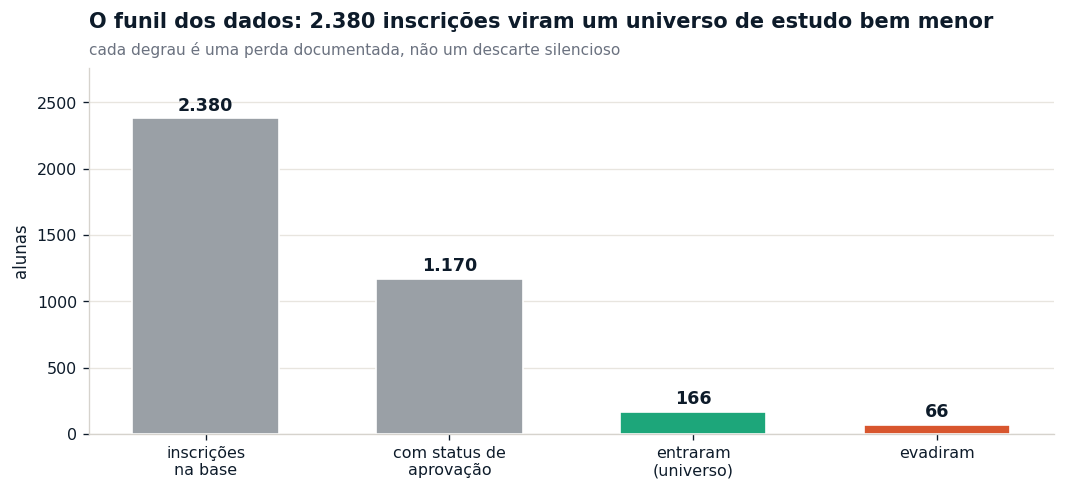

O universo final e 7.0% da base de inscricoes.
A maior parte da perda e SELECAO (nao aprovadas), nao falta de registro:
quem nao entrou no curso nao pode ter evadido dele.


In [ ]:
# o funil, desenhado
rot = ['inscrições\nna base', 'com status de\naprovação', 'entraram\n(universo)', 'evadiram']
val = [len(harm), int(st.notna().sum()), len(universo), int(universo['evadiu'].sum())]
cores_funil = [CINZA, CINZA, TEAL, CORAL]

fig, ax = plt.subplots(figsize=(9.0, 4.2))
barras = ax.bar(rot, val, color=cores_funil, edgecolor='white', width=0.6)
for b, v in zip(barras, val):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(val)*0.025,
            f'{v:,}'.replace(',', '.'), ha='center', fontsize=10.5, weight='bold', color=TINTA)
ax.set_ylim(0, max(val)*1.16)
enfeita(ax, 'O funil dos dados: 2.380 inscrições viram um universo de estudo bem menor',
        'cada degrau é uma perda documentada, não um descarte silencioso', ylabel='alunas')
plt.tight_layout(); plt.show()

print(f"O universo final e {len(universo)/len(harm):.1%} da base de inscricoes.")
print("A maior parte da perda e SELECAO (nao aprovadas), nao falta de registro:")
print("quem nao entrou no curso nao pode ter evadido dele.")


**📖 Como ler:** o número que importa é o último degrau: o universo de alunas que **entraram** e
têm desfecho. Ele é pequeno em relação às inscrições, e isso é um achado do TCC: a maior parte de
quem se inscreve não é aprovada, e as turmas mais novas (12, 16 a 23) ainda não têm nenhum desfecho
registrado na base.

A taxa de evasão que sai daqui tem uma leitura precisa: **entre as alunas que a Fly aprovou nas turmas
10 a 17, qual fração não consta como formada.** É uma conta de três linhas, sem cruzamento de chave,
que qualquer pessoa reproduz a partir do arquivo original.


### 6.2 A auditoria do alvo: a taxa por turma

**🔎 O que vamos fazer:** abrir a taxa de evasão turma a turma. Se ela variar muito entre turmas,
duas coisas podem estar acontecendo ao mesmo tempo: evasão real diferente **e** registro diferente
(uma turma que nunca lançou quem saiu aparece com evasão zero). Separar as duas é impossível só com
a base, então a auditoria serve para **escrever a limitação com número**, não para escondê-la.


AUDITORIA DO ALVO | a taxa de evasao por TURMA
           alunas  evadiram  taxa  % do universo
turma_aba                                       
T14            50        33  66.0           30.1
T17            50        20  40.0           30.1
T15            30        12  40.0           18.1
T10            19         0   0.0           11.4
T11            17         1   5.9           10.2
taxa geral: 39.8%  (n = 166)


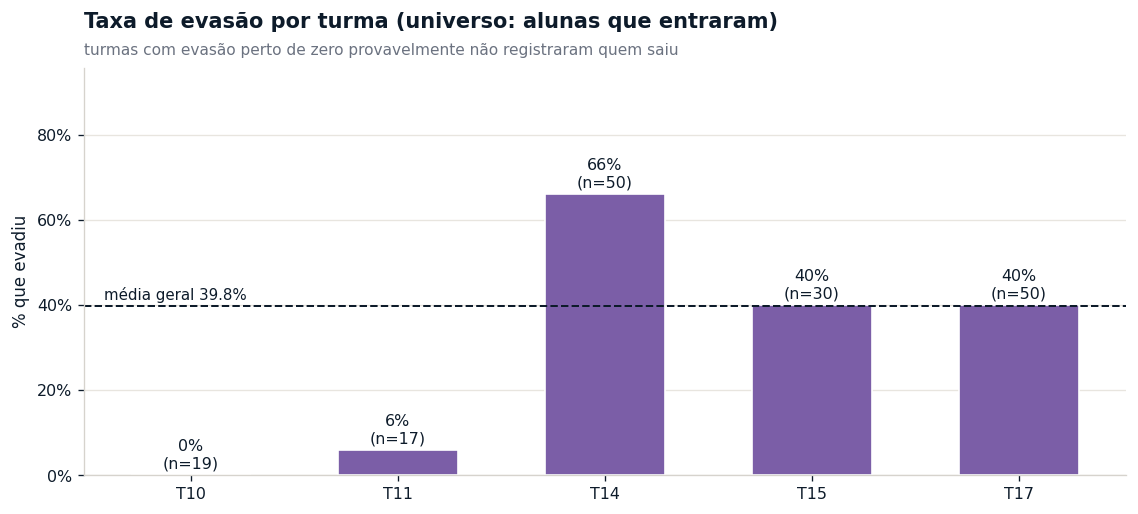

In [ ]:
por_turma = (universo.groupby('turma_aba')['evadiu']
             .agg(alunas='size', evadiram='sum', taxa='mean').sort_values('alunas', ascending=False))
por_turma['taxa'] = (por_turma['taxa'] * 100).round(1)
por_turma['% do universo'] = (100 * por_turma['alunas'] / len(universo)).round(1)
print("=" * 66)
print("AUDITORIA DO ALVO | a taxa de evasao por TURMA")
print("=" * 66)
print(por_turma.to_string())
print("=" * 66)
print(f"taxa geral: {universo['evadiu'].mean()*100:.1f}%  (n = {len(universo)})")

fig, ax = plt.subplots(figsize=(9.6, 4.4))
pt = por_turma.sort_index()
b = ax.bar(pt.index, pt['taxa'], color=PURPLE, edgecolor='white', width=0.58)
for bb, t, n in zip(b, pt['taxa'], pt['alunas']):
    ax.text(bb.get_x()+bb.get_width()/2, t+1.6, f'{t:.0f}%\n(n={n})', ha='center', fontsize=9.5, color=TINTA)
ax.axhline(universo['evadiu'].mean()*100, color=TINTA, ls='--', lw=1.2)
ax.text(-0.42, universo['evadiu'].mean()*100+1.5,
        f"média geral {universo['evadiu'].mean()*100:.1f}%", ha='left', fontsize=9, color=TINTA)
ax.set_ylim(0, max(pt['taxa'].max()*1.45, 20))
ax.yaxis.set_major_formatter(PercentFormatter())
enfeita(ax, 'Taxa de evasão por turma (universo: alunas que entraram)',
        'turmas com evasão perto de zero provavelmente não registraram quem saiu', ylabel='% que evadiu')
plt.tight_layout(); plt.show()


**📖 Como ler:** o alerta mais importante do notebook, e ele precisa estar escrito no TCC com todas
as letras:

> **`evadiu = 1` significa "foi aprovada e não consta como formada".** Isso **não é a mesma coisa**
> que "desistiu": pode incluir aluna cujo registro de conclusão nunca foi lançado. E o contrário também
> vale: uma turma com evasão perto de zero pode ser uma turma em que ninguém lançou quem saiu.

Consequências práticas, que vão para a Estação 8:

1. A taxa geral é uma **medida do que está registrado**, não da evasão vivida. Por isso o notebook
   sempre mostra a taxa com o **n** ao lado e a abertura por turma.
2. Turma e período estão grudados ao registro. Qualquer variável que varie por turma (região, por
   exemplo) pode parecer preditiva sem ser. A Estação 7.4 mede isso em vez de só desconfiar.
3. O modelo pode estar aprendendo, em parte, **como cada turma registrou**, e não o que levou a
   aluna a sair.


### 6.3 Por que o backlog ficou fora desta versão

A Fly enviou também um arquivo de **backlogs** (12 abas, uma por turma, 435 alunas). Uma versão
anterior deste notebook tentou usá-lo como segunda fonte de desfecho, e o que ela mediu é o motivo
de ele ter ficado fora:

| O que foi medido no backlog | Consequência |
|---|---|
| **6 das 12 abas** (312 alunas) não têm nenhuma coluna de status; em metade das abas o cabeçalho veio quebrado (a primeira aluna virou nome de coluna) | o desfecho simplesmente não existe para a maioria |
| Só **90 das 435 chaves** `aluna_id` (21%) casam com a base de inscrições | quem tem desfecho quase nunca tem perfil, e vice-versa |
| A definição de "saiu" é outra (`Desligada`, `Evasão`, assinatura de desligamento) e o recorte que casava concentrava-se numa turma só | misturar as fontes gerava um alvo que o modelo não separava da turma |

**Decisão:** o alvo desta versão vem de uma fonte só, a coluna `Aprovadas` da base, que cobre as
turmas 10 a 17 com uma regra única. O backlog vira **pedido formal à Fly** (Estação 16): mesma chave
nos dois arquivos, cabeçalho na primeira linha e status de saída padronizado. Quando isso chegar, a
Estação 6 recebe a segunda fonte com uma célula a mais, sem mexer no resto.


---
# 🔬 Estação 7: EDA com o alvo, hipótese por hipótese

**🔎 O que vamos fazer:** parar de descrever a base e começar a **testar afirmações**. Cada hipótese
abaixo é uma frase que pode ser falsa, e o trabalho da EDA é dizer se os dados sustentam ou não.

| | Hipótese | O raciocínio por trás | O que esperamos ver |
|---|---|---|---|
| **H1** | Acesso digital precário aumenta a evasão | quem só tem celular não consegue programar | evasão maior em `tem_computador = Não` |
| **H2** | Sobrecarga de cuidado aumenta a evasão | mãe/cuidadora tem menos tempo livre real | evasão maior em `mae_cuidadora = Sim` |
| **H3** | Menos disponibilidade declarada, mais evasão | é a promessa de tempo feita na inscrição | quem evadiu declarou menos horas |
| **H4** | Renda por pessoa menor, mais evasão | precariedade material atrapalha a permanência | evasão cai conforme `renda_ord` sobe |
| **H5** | O perfil demográfico (raça, região, idade) se associa à evasão | desigualdades estruturais não param na porta do curso | diferenças entre grupos |

> ### A regra de ouro desta estação
> Toda diferença vem acompanhada de **barra de incerteza**. Com 166 alunas, uma diferença de
> 10 pontos percentuais entre dois grupos pode ser sorte. Sem a barra, o gráfico mente para quem
> olha rápido, e quem olha rápido é a banca.

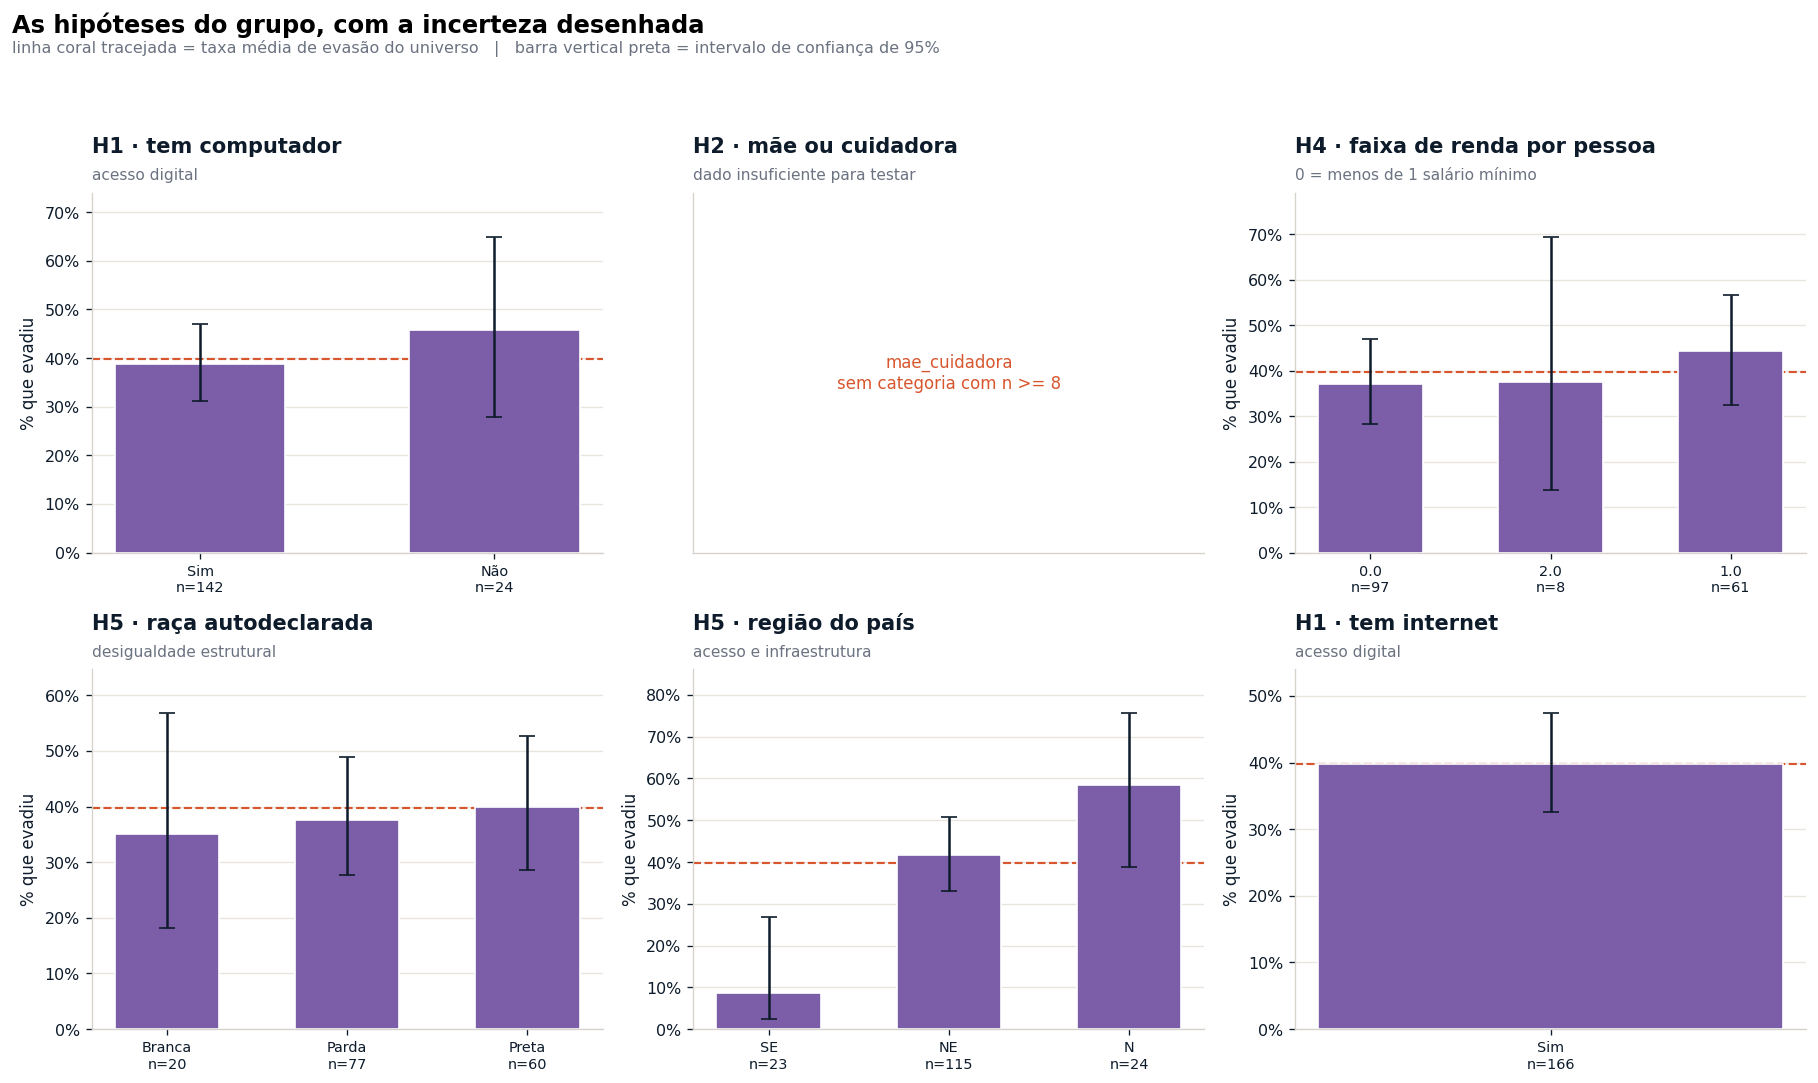

In [ ]:
def ic_wilson(sucessos, n, z=1.96):
    """Intervalo de confianca de 95% para uma proporcao (metodo de Wilson).
    Funciona bem com n pequeno, ao contrario da formula classica."""
    if n == 0: return (np.nan, np.nan)
    p = sucessos / n
    d = 1 + z**2/n
    centro = (p + z**2/(2*n)) / d
    meio = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / d
    return (max(0, centro - meio), min(1, centro + meio))

def taxa_com_ic(df, col, minimo=8):
    """Taxa de evasao por categoria, com n e intervalo de confianca de 95%."""
    linhas = []
    for cat, g in df.dropna(subset=[col]).groupby(col, observed=True):
        n, s = len(g), int(g['evadiu'].sum())
        if n < minimo: continue
        lo, hi = ic_wilson(s, n)
        linhas.append({'categoria': str(cat), 'n': n, 'taxa': 100*s/n,
                       'lo': 100*lo, 'hi': 100*hi})
    df_result = pd.DataFrame(linhas)
    if not df_result.empty:
        return df_result.sort_values('taxa')
    else:
        return df_result

def plota_hipotese(ax, col, titulo, sub, minimo=8):
    t = taxa_com_ic(universo, col, minimo)
    media = universo['evadiu'].mean() * 100
    if len(t) == 0:
        ax.text(0.5, 0.5, f'{col}\nsem categoria com n >= {minimo}', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color=CORAL)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        enfeita(ax, titulo, 'dado insuficiente para testar'); return t
    x = np.arange(len(t))
    ax.bar(x, t['taxa'], color=PURPLE, edgecolor='white', width=0.58, zorder=2)
    ax.errorbar(x, t['taxa'], yerr=[t['taxa']-t['lo'], t['hi']-t['taxa']],
                fmt='none', ecolor=TINTA, elinewidth=1.5, capsize=5, zorder=3)
    ax.axhline(media, color=CORAL, ls='--', lw=1.3, zorder=1)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{r}\nn={n}' for r, n in zip(quebra(t['categoria'], 12), t['n'])],
                       fontsize=8.6)
    ax.set_ylim(0, min(max(t['hi'].max()*1.14, 40), 108))
    ax.yaxis.set_major_formatter(PercentFormatter())
    enfeita(ax, titulo, sub, ylabel='% que evadiu')
    return t

fig, axes = plt.subplots(2, 3, figsize=(15.2, 8.6))
plota_hipotese(axes[0,0], 'tem_computador', 'H1 · tem computador', 'acesso digital')
plota_hipotese(axes[0,1], 'mae_cuidadora',  'H2 · mãe ou cuidadora', 'sobrecarga de cuidado')
plota_hipotese(axes[0,2], 'renda_ord',      'H4 · faixa de renda por pessoa', '0 = menos de 1 salário mínimo')
plota_hipotese(axes[1,0], 'raca',           'H5 · raça autodeclarada', 'desigualdade estrutural')
plota_hipotese(axes[1,1], 'regiao',         'H5 · região do país', 'acesso e infraestrutura')
plota_hipotese(axes[1,2], 'tem_internet',   'H1 · tem internet', 'acesso digital')
fig.suptitle('As hipóteses do grupo, com a incerteza desenhada',
             fontsize=14.5, weight='bold', x=0.006, ha='left', y=1.045)
fig.text(0.006, 1.005, 'linha coral tracejada = taxa média de evasão do universo   |   '
                       'barra vertical preta = intervalo de confiança de 95%',
         fontsize=9.6, color='#6b7280')
plt.tight_layout(rect=[0, 0, 1, 0.985]); plt.show()

**📖 Como ler:** o jeito certo de ler este painel **não** é comparar a altura das barras. É olhar o
tamanho das barras verticais pretas, que são os intervalos de confiança de 95%.

A regra tem dois lados, e o segundo é o que quase todo mundo erra:

- **Se dois intervalos NÃO se sobrepõem, pode afirmar:** os grupos são diferentes.
- **Se eles se sobrepõem, NÃO conclua que os grupos são iguais.** Sobreposição de intervalos é um
  teste conservador: dois intervalos podem se encostar e a diferença ainda ser real. O que a
  sobreposição diz é "este gráfico sozinho não decide", e quem decide é um teste da diferença,
  que é o que a Estação 7.3 faz.

Neste painel praticamente todos os intervalos se sobrepõem, e eles são **largos**. Largura de
intervalo é falta de dado, não falta de efeito.

Compare com o gráfico do V14: lá as mesmas barras apareciam sem incerteza, e uma diferença de
15 pontos parecia um achado. Aqui ela aparece com a margem de erro que ela realmente tem.

**Cuidado com H2:** se o painel de `mae_cuidadora` mostrou "dado insuficiente", é porque a variável
tem poucas respostas no universo, exatamente como a Estação 4 antecipou. A hipótese mais promissora
do grupo **não pôde ser testada**, e isso é conclusão, não lacuna.

### 7.2 As hipóteses numéricas: H3 (disponibilidade) e idade

**🔎 O que vamos fazer:** para variável numérica não dá para fazer barra de taxa. O que faz sentido é
comparar a **distribuição inteira** dos dois grupos e ver o quanto elas se sobrepõem.

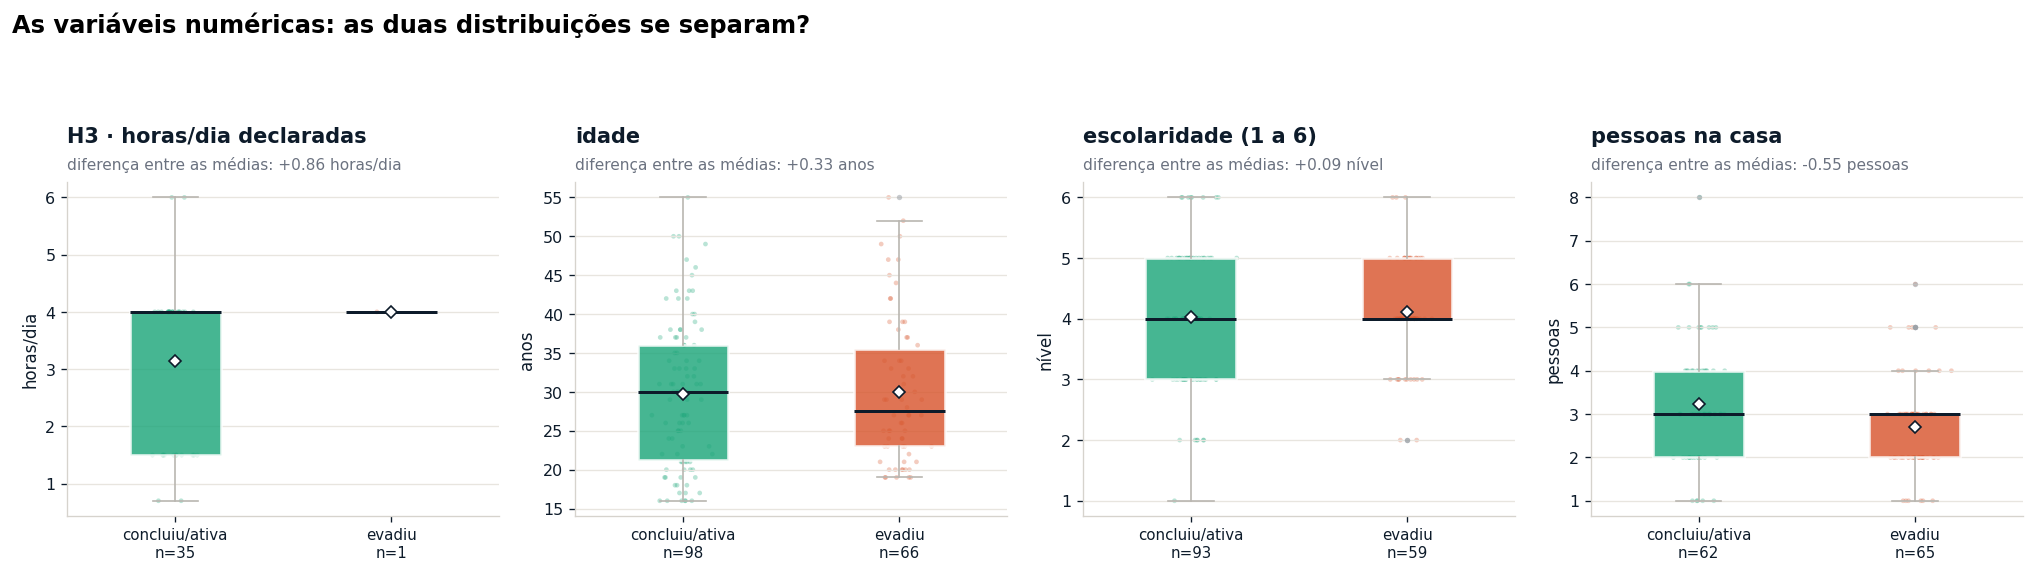

In [ ]:
NUM_TESTE = [('disponibilidade_h', 'H3 · horas/dia declaradas', 'horas/dia'),
             ('idade', 'idade', 'anos'),
             ('escolaridade', 'escolaridade (1 a 6)', 'nível'),
             ('pessoas_casa', 'pessoas na casa', 'pessoas')]

fig, axes = plt.subplots(1, 4, figsize=(17.0, 4.3))
for ax, (col, titulo, unidade) in zip(axes, NUM_TESTE):
    d = universo.dropna(subset=[col])
    g0 = d.loc[d['evadiu'] == 0, col]
    g1 = d.loc[d['evadiu'] == 1, col]
    partes = ax.boxplot([g0, g1], positions=[0, 1], widths=0.42, patch_artist=True,
                        showmeans=True, medianprops=dict(color=TINTA, lw=1.8),
                        meanprops=dict(marker='D', markerfacecolor='white',
                                       markeredgecolor=TINTA, markersize=5),
                        flierprops=dict(marker='o', markersize=3.2, markerfacecolor=CINZA,
                                        markeredgecolor='none', alpha=0.55),
                        whiskerprops=dict(color='#b9b6b0'), capprops=dict(color='#b9b6b0'))
    for p, c in zip(partes['boxes'], [TEAL, CORAL]):
        p.set_facecolor(c); p.set_alpha(0.82); p.set_edgecolor('white'); p.set_linewidth(1.6)
    # os pontos por tras da caixa, com jitter, para a leitora ver o n de verdade
    for pos, g, c in [(0, g0, TEAL), (1, g1, CORAL)]:
        jitter = np.random.normal(pos, 0.055, len(g))
        ax.scatter(jitter, g, s=8, color=c, alpha=0.30, zorder=0, edgecolors='none')
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'concluiu/ativa\nn={len(g0)}', f'evadiu\nn={len(g1)}'], fontsize=9)
    dif = g1.mean() - g0.mean()
    enfeita(ax, titulo, f'diferença entre as médias: {dif:+.2f} {unidade}', ylabel=unidade)
fig.suptitle('As variáveis numéricas: as duas distribuições se separam?',
             fontsize=14.5, weight='bold', x=0.005, ha='left', y=1.10)
plt.tight_layout(); plt.show()

**📖 Como ler:** a caixa vai do primeiro ao terceiro quartil, a linha grossa é a mediana e o losango
branco é a média. Os pontinhos atrás são as alunas de verdade, e eles estão ali de propósito: com
n desse tamanho, é importante ver que cada caixa é feita de poucas dezenas de pessoas.

A pergunta é uma só: **as duas caixas ocupam faixas diferentes?** Quando elas se sobrepõem quase
inteiras, a variável não separa os grupos. Uma diferença de menos de 1 ano na idade média, com
caixas praticamente idênticas, não é sinal, é ruído com nome bonito.

### 7.3 A força da associação: V de Cramér

**🔎 O que vamos fazer:** o qui-quadrado responde "existe associação?" com um sim ou não. Ele não diz
**o tamanho** dela, e com amostra grande qualquer bobagem vira "significativa". O **V de Cramér**
resolve isso: é uma escala de 0 a 1 que mede a força, e não muda de valor só porque a amostra cresceu.

| V de Cramér | Leitura |
|---|---|
| até 0,10 | praticamente nula |
| 0,10 a 0,30 | fraca |
| 0,30 a 0,50 | média |
| acima de 0,50 | forte |

      variavel  n usado  V de Cramer  p-valor          forca                      conclusao
        regiao      164        0.261      NaN          fraca não dá para afirmar com este n
   deficiencia      166        0.066      NaN     quase nula não dá para afirmar com este n
          raca      165        0.000      NaN     quase nula não dá para afirmar com este n
tem_computador      166        0.000    0.511     quase nula não dá para afirmar com este n
          lgbt      165        0.000    0.681     quase nula não dá para afirmar com este n
        genero      165        0.000      NaN     quase nula não dá para afirmar com este n
 mae_cuidadora        0          NaN      NaN n insuficiente não dá para afirmar com este n
  tem_internet        0          NaN      NaN n insuficiente não dá para afirmar com este n

V corrigido por vies (Bergsma): comparavel entre tabelas de tamanhos diferentes.
p indisponivel = alguma casela esperava menos de 5 alunas, o qui-quadrado nao vale ali.


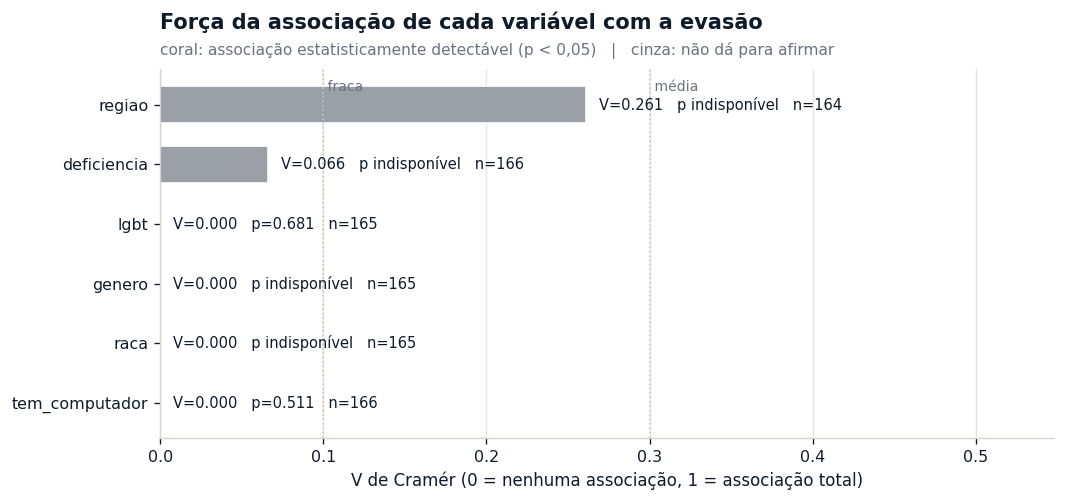

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """V de Cramer com correcao de vies (Bergsma, 2013).

    Sem a correcao, o V cresce sozinho quando a tabela tem mais linhas ou colunas,
    e ai comparar 'raca x evadiu' (5x2) com 'turma x regiao' (8x5) fica invalido.
    Tambem desligamos a correcao de Yates, que o scipy aplica so em tabelas 2x2 e
    encolheria justamente as variaveis Sim/Nao."""
    tabela = pd.crosstab(x, y)
    if tabela.shape[0] < 2 or tabela.shape[1] < 2:
        return np.nan, np.nan, 0
    chi2_stat, p, _, esperado = chi2_contingency(tabela, correction=False)
    if (esperado < 5).mean() > 0.2:        # p-valor do qui-quadrado deixa de valer
        p = np.nan
    n = tabela.values.sum()
    r, k = tabela.shape
    phi2 = chi2_stat / n
    phi2_corr = max(0.0, phi2 - (r-1)*(k-1)/(n-1))
    r_corr = r - (r-1)**2/(n-1)
    k_corr = k - (k-1)**2/(n-1)
    denom = min(r_corr - 1, k_corr - 1)
    if denom <= 0:
        return np.nan, p, n
    return float(np.sqrt(phi2_corr / denom)), p, n

def forca(v):
    return ('forte' if v >= 0.5 else 'média' if v >= 0.3 else 'fraca' if v >= 0.1 else 'quase nula')

res = []
for c in ['tem_computador', 'mae_cuidadora', 'tem_internet', 'raca', 'regiao',
          'lgbt', 'deficiencia', 'genero']:
    sub = universo.dropna(subset=[c])
    v, p, n = cramers_v(sub[c], sub['evadiu'])
    res.append({'variavel': c, 'n usado': n,
                'V de Cramer': round(v, 3) if not np.isnan(v) else np.nan,
                'p-valor': round(p, 3) if not np.isnan(p) else np.nan,
                'forca': forca(v) if not np.isnan(v) else 'n insuficiente',
                'conclusao': ('associação detectável' if (not np.isnan(v) and not np.isnan(p) and p < 0.05)
                              else 'não dá para afirmar com este n')})
res = pd.DataFrame(res).sort_values('V de Cramer', ascending=False, na_position='last')
print(res.to_string(index=False))

r = res.dropna(subset=['V de Cramer']).sort_values('V de Cramer')
print("\nV corrigido por vies (Bergsma): comparavel entre tabelas de tamanhos diferentes.")
print("p indisponivel = alguma casela esperava menos de 5 alunas, o qui-quadrado nao vale ali.")
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cores = [CORAL if (not np.isnan(p) and p < 0.05) else CINZA for p in r['p-valor']]
barras = ax.barh(r['variavel'], r['V de Cramer'], color=cores, edgecolor='white', height=0.62)
for b, v, p, n in zip(barras, r['V de Cramer'], r['p-valor'], r['n usado']):
    ax.text(b.get_width() + 0.008, b.get_y() + b.get_height()/2,
            f'V={v:.3f}   ' + (f'p={p:.3f}' if not np.isnan(p) else 'p indisponível') +
            f'   n={n}', va='center', fontsize=8.8, color=TINTA)
for lim, rot in [(0.1, 'fraca'), (0.3, 'média')]:
    ax.axvline(lim, color='#c9c6c0', lw=1, ls=':')
    ax.text(lim, len(r)-0.58, f' {rot}', fontsize=8.4, color='#6b7280', va='top')
ax.set_xlim(0, max(0.36, r['V de Cramer'].max()*2.1))
enfeita(ax, 'Força da associação de cada variável com a evasão',
        'coral: associação estatisticamente detectável (p < 0,05)   |   cinza: não dá para afirmar',
        xlabel='V de Cramér (0 = nenhuma associação, 1 = associação total)', eixo_grade='x')
plt.tight_layout(); plt.show()

**📖 Como ler:** e aqui está o resultado que explica por que o modelo não ficou bom:

> **Nenhuma variável de perfil da inscrição tem associação sequer média com a evasão.**

Se a variável mais forte da base fica na faixa "fraca", nenhum algoritmo do mundo vai extrair um
modelo forte disso. Modelo não cria informação, ele organiza a informação que existe. O gargalo
deste TCC **não é o algoritmo**, é o conjunto de variáveis disponível.

E cuidado com a variável que aparecer em coral: veja a seção seguinte antes de comemorar.

### 7.4 O teste do confundimento: a variável prevê a aluna ou prevê a turma?

**🔎 O que vamos fazer:** se `regiao` (ou qualquer outra) apareceu associada à evasão, precisamos
checar uma explicação alternativa antes de acreditar: talvez as regiões estejam distribuídas de forma
desigual entre as turmas, e como cada turma tem uma taxa de evasão diferente (Estação 6.3), a região
esteja apenas **carregando o efeito da turma**.

**Isso se chama variável de confundimento**, e é o erro de interpretação mais comum em análise
social. Vamos medir em vez de torcer.

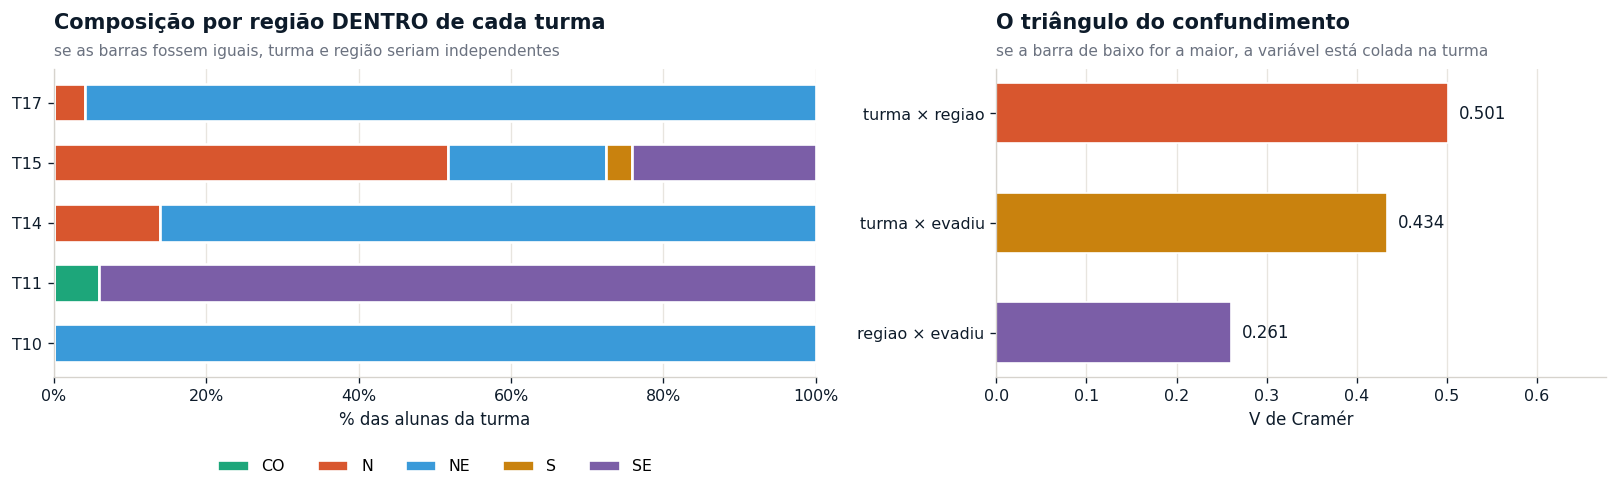

turma x regiao: V = 0.501 (p=nan)

VEREDITO: 'regiao' esta MAIS associada a TURMA do que a evasao.
Ou seja, o efeito aparente pode ser efeito de turma/periodo disfarcado.
Interpretar como causa seria erro. Vai para as limitacoes.


In [ ]:
alvo_col = 'regiao'
tab = pd.crosstab(universo['turma_aba'], universo[alvo_col], normalize='index') * 100
tab_n = pd.crosstab(universo['turma_aba'], universo[alvo_col])
grandes = tab_n.sum(axis=1) >= 10
tab, tab_n = tab[grandes], tab_n[grandes]

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.4), gridspec_kw={'width_ratios': [1.25, 1]})

esq = tab.plot(kind='barh', stacked=True, ax=axes[0], width=0.62,
               color=CATEG[:tab.shape[1]], edgecolor='white', linewidth=1.6, legend=False)
axes[0].set_xlim(0, 100); axes[0].xaxis.set_major_formatter(PercentFormatter())
axes[0].set_ylabel('')
enfeita(axes[0], 'Composição por região DENTRO de cada turma',
        'se as barras fossem iguais, turma e região seriam independentes',
        xlabel='% das alunas da turma', eixo_grade='x')
axes[0].legend(title=None, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncols=5)

v_conf, p_conf, n_conf = cramers_v(universo.dropna(subset=[alvo_col])['turma_aba'],
                                   universo.dropna(subset=[alvo_col])[alvo_col])
v_alvo, p_alvo, _ = cramers_v(universo.dropna(subset=[alvo_col])[alvo_col],
                              universo.dropna(subset=[alvo_col])['evadiu'])
v_turma, p_turma, _ = cramers_v(universo['turma_aba'], universo['evadiu'])

comp = pd.Series({f'{alvo_col} × evadiu': v_alvo,
                  'turma × evadiu': v_turma,
                  f'turma × {alvo_col}': v_conf})
b = axes[1].barh(comp.index, comp.values,
                 color=[PURPLE, AMBER, CORAL], edgecolor='white', height=0.55)
for bb, v in zip(b, comp.values):
    axes[1].text(bb.get_width()+0.012, bb.get_y()+bb.get_height()/2, f'{v:.3f}',
                 va='center', fontsize=10, color=TINTA)
axes[1].set_xlim(0, max(comp.max()*1.35, 0.4))
enfeita(axes[1], 'O triângulo do confundimento',
        'se a barra de baixo for a maior, a variável está colada na turma',
        xlabel='V de Cramér', eixo_grade='x')
plt.tight_layout(); plt.show()

print(f"turma x {alvo_col}: V = {v_conf:.3f} (p={p_conf:.4f})")
if v_conf >= v_alvo:
    print(f"\nVEREDITO: '{alvo_col}' esta MAIS associada a TURMA do que a evasao.")
    print("Ou seja, o efeito aparente pode ser efeito de turma/periodo disfarcado.")
    print("Interpretar como causa seria erro. Vai para as limitacoes.")
else:
    print(f"\nVEREDITO: a associacao de '{alvo_col}' com evasao nao se explica so pela turma.")

**📖 Como ler:** o gráfico da esquerda mostra que as turmas **não** têm a mesma composição regional.
O da direita compara as três associações do triângulo. Quando a barra `turma × região` é a maior das
três, a conclusão é dura e necessária:

> A associação entre região e evasão que apareceu em 7.3 pode ser, na maior parte, o efeito da turma
> e do período. Turmas diferentes tiveram coordenações, formatos e momentos diferentes, e também
> composições regionais diferentes. Sem mais turmas para comparar, os dois efeitos não se separam.

Levar isso para a apresentação é o que impede a banca de perguntar "vocês checaram se não é a turma?"
e receber um silêncio.

---
# ⚠️ Estação 8: as limitações, escritas antes de modelar

**🔎 O que vamos fazer:** listar tudo o que este notebook **não** pode afirmar. Colocamos as
limitações **aqui**, antes do modelo, de propósito: quem lê já entra na parte de modelagem sabendo
o tamanho da régua. Limitação escondida no último slide parece desculpa; limitação declarada antes
parece método.

In [ ]:
n_uni   = len(universo)
n_pos   = int(universo['evadiu'].sum())
n_teste = int(round(n_uni * 0.25))
prev    = universo['evadiu'].mean()
maior_turma = universo['turma_aba'].value_counts(normalize=True).iloc[0]
n_vars = len(['idade', 'escolaridade', 'renda_ord', 'disponibilidade_h', 'pessoas_casa',
              'raca', 'tem_computador', 'tem_internet', 'regiao', 'lgbt', 'deficiencia',
              'genero'])

print("=" * 70)
print("FICHA TECNICA DAS LIMITACOES")
print("=" * 70)
print(f"L1. TAMANHO       universo de {n_uni} alunas, {n_pos} evasoes.")
print(f"                  um conjunto de teste de 25% tem so ~{n_teste} alunas,")
print(f"                  das quais ~{int(n_teste*prev)} evadiram. Um acerto a mais ou a menos")
print(f"                  mexe o recall em ~{100/max(int(n_teste*prev),1):.0f} pontos percentuais.")
print(f"                  DECISAO: validacao cruzada repetida, nunca uma prova unica.")
print()
print( "L2. ALVO          uma fonte so (coluna Aprovadas): evadiu = 1 significa 'aprovada e nao")
print( "                  consta como formada'. Isso pode incluir registro de conclusao faltante,")
print( "                  e uma turma com evasao ~0 pode ser turma que nao lancou quem saiu.")
print( "                  A taxa medida e a taxa REGISTRADA, sempre lida com o n e por turma.")
print()
print(f"L3. CONFUNDIMENTO {maior_turma:.0%} do universo vem de uma unica turma, e as turmas")
print( "                  diferem em periodo, regiao e forma de registro. Efeito de")
print( "                  contexto e efeito de perfil nao se separam com estes dados.")
print()
n_com_status = int(harm['status_aprovacao'].notna().sum())
print(f"L4. COBERTURA     o desfecho existe so nas turmas 10, 11, 14, 15 e 17 ({n_com_status} de")
print(f"                  {len(harm)} inscricoes tem a coluna Aprovadas). As turmas 12 e 16 a 23")
print( "                  nao tem desfecho na base, e o backlog ficou fora (Estacao 6.3).")
print( "                  Quem esta fora pode ser sistematicamente diferente (turmas mais")
print( "                  recentes, outros formularios). Isso e vies de selecao, nao so perda de n.")
print()
print(f"L5. VARIAVEIS     {n_vars} variaveis, todas declaradas NA INSCRICAO, antes do curso comecar.")
print( "                  Nao ha NENHUMA variavel de engajamento (presenca, entrega de")
print( "                  atividade, acesso a plataforma). A literatura de evasao aponta")
print( "                  engajamento como o preditor mais forte, e ele nao existe aqui.")
print()
print( "L6. AUTODECLARADO As respostas sao promessas feitas na inscricao. 'Tenho 3 horas por")
print( "                  dia' e uma intencao, nao uma medida do que aconteceu depois.")
print()
print( "L7. ESCALA        'disponibilidade_h' junta dois formatos de pergunta: um perguntava")
print( "                  horas por DIA (opcoes ate 6h) e outro por SEMANA (convertido")
print( "                  dividindo por 7, teto de 2h/dia). Os dois foram postos na mesma")
print( "                  escala, mas o TETO e diferente, entao um valor acima de 2h/dia so")
print( "                  pode ter vindo do formulario antigo. Ou seja, essa variavel carrega")
print( "                  um pouco de 'qual formulario a aluna respondeu', que e o mesmo eixo")
print( "                  turma/periodo do L3. Se ela aparecer como importante na Estacao 13,")
print( "                  leia com esta ressalva na mao.")
print("=" * 70)

FICHA TECNICA DAS LIMITACOES
L1. TAMANHO       universo de 166 alunas, 66 evasoes.
                  um conjunto de teste de 25% tem so ~42 alunas,
                  das quais ~16 evadiram. Um acerto a mais ou a menos
                  mexe o recall em ~6 pontos percentuais.
                  DECISAO: validacao cruzada repetida, nunca uma prova unica.

L2. ALVO          uma fonte so (coluna Aprovadas): evadiu = 1 significa 'aprovada e nao
                  consta como formada'. Isso pode incluir registro de conclusao faltante,
                  e uma turma com evasao ~0 pode ser turma que nao lancou quem saiu.
                  A taxa medida e a taxa REGISTRADA, sempre lida com o n e por turma.

L3. CONFUNDIMENTO 30% do universo vem de uma unica turma, e as turmas
                  diferem em periodo, regiao e forma de registro. Efeito de
                  contexto e efeito de perfil nao se separam com estes dados.

L4. COBERTURA     o desfecho existe so nas turmas 10, 11, 14, 15 e 17 

**📖 Como ler:** as seis limitações não têm o mesmo peso. **L5 é a decisiva.**

As outras cinco são problemas de quantidade e de qualidade de registro, e todas melhoram sozinhas
conforme a Fly acumula turmas. A L5 é de outra natureza: por mais turmas que se acumulem, um
formulário de inscrição continua sendo uma foto tirada **antes** do curso. Evasão é um processo que
acontece **durante**, e o sinal desse processo (parou de entregar atividade, sumiu por duas semanas,
não acessou a plataforma) não está nesta base porque nunca foi coletado.

Guarde isto para a conclusão do TCC:

> Não estamos falhando em prever a evasão. Estamos descobrindo que ela não é previsível
> **a partir do formulário de inscrição**, e apontando exatamente qual dado a tornaria previsível.

---
# 🧰 Estação 9: preparar os dados sem vazamento

**🔎 O que vamos fazer:** transformar o `universo` em algo que o scikit-learn aceita, sem cometer o
erro mais comum de todos: **vazamento de dados**.

## O que é vazamento, com um exemplo concreto

Uma das variáveis é `idade`, e ela tem valores faltando. A gente vai preencher com a mediana.
A pergunta é: **mediana de quem?**

- ❌ **Errado:** calcular a mediana usando as 166 alunas e só depois separar treino e teste.
  A mediana carrega informação das alunas do teste, o teste deixa de ser uma prova sem consulta,
  e o modelo parece melhor do que é.
- ✅ **Certo:** separar primeiro, calcular a mediana **só no treino** e aplicar esse mesmo número no
  teste. É o que o `Pipeline` garante, inclusive dentro de cada dobra da validação cruzada.

**Por isso todo pré-processamento mora dentro do `Pipeline`.** Não é elegância, é a única forma de a
validação cruzada dizer a verdade.

## Por que separar mesmo com o universo pequeno

Com 166 alunas, o conjunto de teste fica com cerca de 40 pessoas. Isso é pouco para decidir
qualquer coisa. Então a divisão de papéis é esta, e ela está escrita para não haver dúvida depois:

| Conjunto | Para que serve | Para que **não** serve |
|---|---|---|
| **Treino (75%)** | comparar modelos, ajustar hiperparâmetros, escolher o limiar, tudo por validação cruzada | nada além disso |
| **Teste (25%)** | ler o resultado final: métricas, matriz, importância e curva de ganho | escolher modelo, escolher hiperparâmetro ou limiar |

Repare na diferença: o teste é **lido** várias vezes na Estação 13, e isso é legítimo, porque
nenhuma dessas leituras volta atrás para mudar o modelo. O que seria vazamento é **decidir** olhando
o teste, e por isso todas as decisões deste notebook (modelo, hiperparâmetro, limiar) acontecem
antes, por validação cruzada no treino.

In [ ]:
CANDIDATAS_NUM = ['idade', 'escolaridade', 'renda_ord', 'disponibilidade_h', 'pessoas_casa']
CANDIDATAS_CAT = ['raca', 'tem_computador', 'tem_internet', 'regiao', 'lgbt',
                  'deficiencia', 'genero', 'mae_cuidadora']

# ATENCAO: o corte da Estacao 4 foi medido nas 2.380 inscricoes. Quem entra no modelo
# sao as alunas do UNIVERSO, e o universo e dominado pelas turmas antigas, cujo
# formulario tinha menos perguntas. Entao o corte precisa ser recalculado AQUI.
preench_uni = (universo[CANDIDATAS_NUM + CANDIDATAS_CAT].notna().mean() * 100).round(0)
print(f"{'variavel':20s} {'na base':>9s} {'no universo':>13s}   decisao")
print('-' * 62)
for v in CANDIDATAS_NUM + CANDIDATAS_CAT:
    na_base = harm[v].notna().mean() * 100
    no_uni = preench_uni[v]
    ok = no_uni >= LIMITE_USO and universo[v].nunique(dropna=True) >= 2
    motivo = 'entra' if ok else ('abaixo do corte' if no_uni < LIMITE_USO else 'sem variacao')
    print(f"{v:20s} {na_base:8.0f}% {no_uni:12.0f}%   {motivo}")

c_num = [v for v in CANDIDATAS_NUM
         if preench_uni[v] >= LIMITE_USO and universo[v].nunique(dropna=True) >= 2]
c_cat = [v for v in CANDIDATAS_CAT
         if preench_uni[v] >= LIMITE_USO and universo[v].nunique(dropna=True) >= 2]
VARIAVEIS = c_num + c_cat

print(f"\nVariaveis do modelo: {len(VARIAVEIS)}  (escolhidas por CODIGO, nao na mao)")
print("  numericas  :", c_num)
print("  categoricas:", c_cat)
print("\nDELIBERADAMENTE FORA:")
for v in CANDIDATAS_NUM + CANDIDATAS_CAT:
    if v not in VARIAVEIS:
        motivo = "sem variacao no universo (quase todas respondem igual)" if preench_uni[v] >= LIMITE_USO else f"so {preench_uni[v]:.0f}% de resposta DENTRO do universo (corte: {LIMITE_USO}%)"
        print(f"  {v:14s} -> {motivo}")
print("  turma_aba      -> confundida com fonte do desfecho e periodo (Estacao 7.4)")
print("  texto livre    -> risco de dado pessoal (Estacao 2.5)")

# categoria rara AQUI e o que importa: e no universo que a divisao treino/teste acontece
print("\nCATEGORIAS COM MENOS DE 10 ALUNAS NO UNIVERSO (viram ruido no modelo):")
achou_rara = False
for v in c_cat:
    for cat, n in universo[v].value_counts().items():
        if n < 10:
            print(f"  {v:16s} {str(cat)[:26]:28s} n={n}")
            achou_rara = True
if not achou_rara:
    print("  nenhuma")

Xu = universo[VARIAVEIS]
yu = universo['evadiu']

X_tr, X_te, y_tr, y_te = train_test_split(Xu, yu, test_size=0.25,
                                          random_state=SEMENTE, stratify=yu)
print(f"\nTreino: {X_tr.shape[0]} alunas ({y_tr.sum()} evasoes, {y_tr.mean():.1%})")
print(f"Teste : {X_te.shape[0]} alunas ({y_te.sum()} evasoes, {y_te.mean():.1%})")
print("stratify=yu garantiu a MESMA proporcao de evasao nos dois lados.")

preparo = ColumnTransformer([
    ('num', Pipeline([('preencher', SimpleImputer(strategy='median')),
                      ('escala', StandardScaler())]), c_num),
    ('cat', Pipeline([('preencher', SimpleImputer(strategy='constant', fill_value='Nao respondeu')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), c_cat),
])

n_colunas_final = preparo.fit(X_tr).transform(X_tr).shape[1]
print(f"\nDepois do preparo, {len(VARIAVEIS)} variaveis viram {n_colunas_final} colunas numericas.")
print(f"Razao alunas por coluna no treino: {len(X_tr)/n_colunas_final:.1f}")
print("Abaixo de ~10 alunas por coluna, modelo complexo decora. Anotado para a Estacao 11.")

variavel               na base   no universo   decisao
--------------------------------------------------------------
idade                      88%           99%   entra
escolaridade               87%           92%   entra
renda_ord                  99%          100%   entra
disponibilidade_h          70%           22%   abaixo do corte
pessoas_casa               69%           77%   entra
raca                       98%           99%   entra
tem_computador             96%          100%   entra
tem_internet               94%          100%   sem variacao
regiao                     90%           99%   entra
lgbt                       93%           99%   entra
deficiencia                94%          100%   entra
genero                     93%           99%   entra
mae_cuidadora              12%            0%   abaixo do corte

Variaveis do modelo: 10  (escolhidas por CODIGO, nao na mao)
  numericas  : ['idade', 'escolaridade', 'renda_ord', 'pessoas_casa']
  categoricas: ['raca', 'tem_compu

**📖 Como ler:** a última linha é um aviso técnico com consequência prática. Um modelo aprende
ajustando um número por coluna. Se há poucas alunas por coluna, sobra liberdade para o modelo
inventar padrão em cima de coincidência. **Nossa aposta, escrita aqui antes de rodar:** daqui a
duas estações o modelo mais simples vai empatar ou ganhar do mais sofisticado. Se a aposta se
cumprir, ela vira argumento; se falhar, vira uma pergunta interessante para a discussão.

Repare também nas três exclusões declaradas. Cada uma delas veio de uma decisão tomada numa estação
anterior, com evidência. Modelo bom não é o que usa todas as variáveis, é o que sabe justificar
cada uma que entrou e cada uma que ficou de fora.

---
# 📏 Estação 10: escolher a régua ANTES de olhar os resultados

**🔎 O que vamos fazer:** definir com qual métrica vamos julgar os modelos. Isso vem **antes** de
rodar qualquer modelo, de propósito: escolher a métrica depois de ver os números é escolher a
métrica que faz o resultado parecer melhor.

## Os quatro destinos de uma previsão

| | previu: segue | previu: evade |
|---|---|---|
| **real: seguiu** | ✅ Verdadeiro Negativo | ⚠️ **Falso Positivo**: a Fly chama para conversar quem não ia sair |
| **real: evadiu** | ❌ **Falso Negativo**: a aluna evadiu e ninguém foi atrás | ✅ Verdadeiro Positivo |

**Os dois erros não custam a mesma coisa.** Um Falso Positivo custa uma conversa de acolhimento a
mais, que raramente faz mal a alguém. Um Falso Negativo custa uma mulher perdendo a formação sem que
ninguém tenha tentado. **Neste projeto, recall pesa mais que precisão.**

## A armadilha da acurácia, com números deste notebook

Cerca de 1 em cada 3 alunas do universo evadiu. Um modelo que **chuta "ninguém evade" para todo
mundo** acerta aproximadamente 2 em cada 3 casos. Acurácia perto de 67%, e utilidade **zero**: ele
nunca aponta ninguém para a Fly acolher. É por isso que o baseline entra na tabela da próxima
estação. Não para competir, para provar que a acurácia sozinha mente.

## As métricas que vamos usar, e por quê

| Métrica | O que responde | Por que está aqui |
|---|---|---|
| **Recall** (das que evadiram, quantas o modelo achou) | "quantas mulheres a gente conseguiria alcançar?" | é o objetivo social do projeto |
| **Precisão** (das apontadas, quantas evadiram mesmo) | "quanto esforço da equipe é gasto à toa?" | é o custo operacional |
| **F1** | equilíbrio entre as duas | serve para ordenar a tabela |
| **AP / AUC-PR** | qualidade do **ranqueamento** de risco, em todos os limiares de uma vez | **é a métrica principal**, e a explicação vem abaixo |

## Por que AP (average precision) é a métrica principal

As três primeiras dependem de um corte arbitrário: por padrão o modelo chama de "evade" quem tiver
probabilidade acima de 0,5. Esse 0,5 não tem nada de sagrado, e mudar ele muda recall e precisão.

A **AP** resume a curva de precisão-recall inteira, ou seja, avalia se o modelo **ordena bem** as
alunas por risco, independente de onde a gente corte. E ela tem uma propriedade que vale ouro aqui:

> **O valor de AP de um modelo que não aprendeu nada é igual à taxa de evasão da base.**

Ou seja, a AP já vem com o seu próprio ponto de comparação embutido. Se a AP do modelo ficar em cima
da taxa de evasão, o modelo não está ordenando nada: está sorteando.

In [ ]:
AP_ACASO = float(y_tr.mean())     # o piso: AP de quem chuta ao acaso
print("=" * 62)
print("A REGUA DESTE NOTEBOOK")
print("=" * 62)
print(f"  Metrica principal ....... AP (average precision / AUC-PR)")
print(f"  Piso do acaso (AP) ...... {AP_ACASO:.3f}   <- taxa de evasao no treino")
print(f"  Metricas de apoio ....... recall, precisao, F1")
print(f"  Metrica PROIBIDA sozinha  acuracia")
print(f"  Protocolo ............... StratifiedKFold 5 dobras x 10 repeticoes = 50 provas")
print("=" * 62)
print()
print("COMO LER QUALQUER RESULTADO DAQUI PRA FRENTE:")
print(f"  AP proximo de {AP_ACASO:.2f} .... o modelo NAO ordena risco melhor que sorteio")
print(f"  AP em torno de {AP_ACASO+0.10:.2f} .... sinal fraco, util so para priorizar fila")
print(f"  AP acima de {AP_ACASO+0.25:.2f} ...... sinal util de verdade")
print()
print("RESSALVA IMPORTANTE, para nao errar a leitura la na frente:")
print(f"  {AP_ACASO:.2f} e o piso TEORICO, valido para uma amostra grande. Com universo pequeno")
print("  e com busca de hiperparametros, o acaso costuma tirar nota ACIMA desse piso.")
print("  A Estacao 14 mede o piso de verdade por embaralhamento, e e ELE que decide.")

CV = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEMENTE)
METRICAS = {'AP': 'average_precision', 'F1': 'f1', 'recall': 'recall',
            'precisao': 'precision', 'acuracia': 'accuracy'}

A REGUA DESTE NOTEBOOK
  Metrica principal ....... AP (average precision / AUC-PR)
  Piso do acaso (AP) ...... 0.395   <- taxa de evasao no treino
  Metricas de apoio ....... recall, precisao, F1
  Metrica PROIBIDA sozinha  acuracia
  Protocolo ............... StratifiedKFold 5 dobras x 10 repeticoes = 50 provas

COMO LER QUALQUER RESULTADO DAQUI PRA FRENTE:
  AP proximo de 0.40 .... o modelo NAO ordena risco melhor que sorteio
  AP em torno de 0.50 .... sinal fraco, util so para priorizar fila
  AP acima de 0.65 ...... sinal util de verdade

RESSALVA IMPORTANTE, para nao errar a leitura la na frente:
  0.40 e o piso TEORICO, valido para uma amostra grande. Com universo pequeno
  e com busca de hiperparametros, o acaso costuma tirar nota ACIMA desse piso.
  A Estacao 14 mede o piso de verdade por embaralhamento, e e ELE que decide.


**📖 Como ler:** as três faixas acima são o gabarito que a gente combinou **antes** de ver qualquer
resultado. Quando a tabela da próxima estação aparecer, não vai ter espaço para negociar o que
significa "bom". Isso se chama pré-registro da análise, é prática padrão em pesquisa séria, e é
raríssimo num TCC. Vale ponto.

Note também o protocolo: **5 dobras vezes 10 repetições, ou seja, 50 provas diferentes** para cada
modelo. Com universo pequeno, uma prova só é loteria. Cinquenta provas mostram não só a média, mas
o quanto o resultado balança, e o quanto ele balança é uma informação tão importante quanto a média.

---
# 🥊 Estação 11: comparar os modelos (e por que exatamente estes cinco)

**🔎 O que vamos fazer:** rodar cinco modelos sob o mesmo protocolo e comparar. Cada um está aqui por
um motivo diferente, e a coluna "por que está na disputa" é o que a banca vai perguntar.

| Modelo | Como ele pensa | Por que está na disputa |
|---|---|---|
| **Baseline** | chuta sempre a classe mais comum | é a régua: quem não vencer dele não serve para nada |
| **Regressão Logística** | soma pesos, um por variável | poucos parâmetros, sofre menos com n pequeno, e cada peso é lido em português |
| **Árvore rasa** | perguntas encadeadas de sim/não | a regra sai legível e pode virar checklist da equipe da Fly |
| **Random Forest** | centenas de árvores votando | captura interação entre variáveis (renda **e** falta de computador juntos) |
| **Gradient Boosting** | árvores que corrigem o erro da anterior | o mais potente da lista, e o que mais decora quando o n é pequeno |

**A hipótese técnica desta estação:** com cerca de 5 alunas por coluna (Estação 9), o esperado é que os
modelos simples ganhem. Se o Gradient Boosting vencer por muito, é sinal de decoreba, não de talento.

> **Regra do notebook:** o vencedor é escolhido **por código**, pela maior AP média, e a variável
> `campeao` passa a valer para todas as estações seguintes. Nenhum gráfico daqui pra frente mostra
> um modelo diferente do que venceu.

In [ ]:
modelos = {
    'Baseline (mais comum)': DummyClassifier(strategy='most_frequent'),
    'Regressao Logistica':   LogisticRegression(max_iter=2000, class_weight='balanced',
                                                random_state=SEMENTE),
    'Arvore rasa':           DecisionTreeClassifier(max_depth=3, min_samples_leaf=8,
                                                    class_weight='balanced', random_state=SEMENTE),
    'Random Forest':         RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=5,
                                                    class_weight='balanced', random_state=SEMENTE),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=150, learning_rate=0.05,
                                                        max_depth=2, random_state=SEMENTE),
}

resultados, dobras = [], {}
for nome, m in modelos.items():
    fluxo = Pipeline([('preparo', preparo), ('modelo', m)])
    cv = cross_validate(fluxo, X_tr, y_tr, cv=CV, scoring=METRICAS, n_jobs=-1)
    dobras[nome] = cv['test_AP']
    resultados.append({'modelo': nome,
                       **{f'{k}': cv[f'test_{k}'].mean() for k in METRICAS},
                       'AP_desvio': cv['test_AP'].std()})

tab = (pd.DataFrame(resultados).set_index('modelo')
       .sort_values('AP', ascending=False).round(3))
tab['AP vs acaso'] = (tab['AP'] - AP_ACASO).round(3)
print(f"MEDIA DE 50 PROVAS POR MODELO   |   piso do acaso (AP) = {AP_ACASO:.3f}\n")
print(tab[['AP', 'AP_desvio', 'AP vs acaso', 'F1', 'recall', 'precisao', 'acuracia']].to_string())

campeao = tab.index[0]
print(f"\n>>> CAMPEAO POR CODIGO: {campeao}  (AP = {tab.loc[campeao,'AP']:.3f})")
print(">>> Todas as estacoes seguintes usam ESTE modelo, e nenhum outro.")

MEDIA DE 50 PROVAS POR MODELO   |   piso do acaso (AP) = 0.395

                          AP  AP_desvio  AP vs acaso     F1  recall  precisao  acuracia
modelo                                                                                 
Regressao Logistica    0.525      0.091        0.130  0.510   0.568     0.477     0.577
Random Forest          0.523      0.097        0.128  0.483   0.524     0.462     0.562
Gradient Boosting      0.477      0.084        0.082  0.360   0.331     0.419     0.553
Arvore rasa            0.455      0.047        0.060  0.513   0.642     0.444     0.542
Baseline (mais comum)  0.395      0.010       -0.000  0.000   0.000     0.000     0.605

>>> CAMPEAO POR CODIGO: Regressao Logistica  (AP = 0.525)
>>> Todas as estacoes seguintes usam ESTE modelo, e nenhum outro.


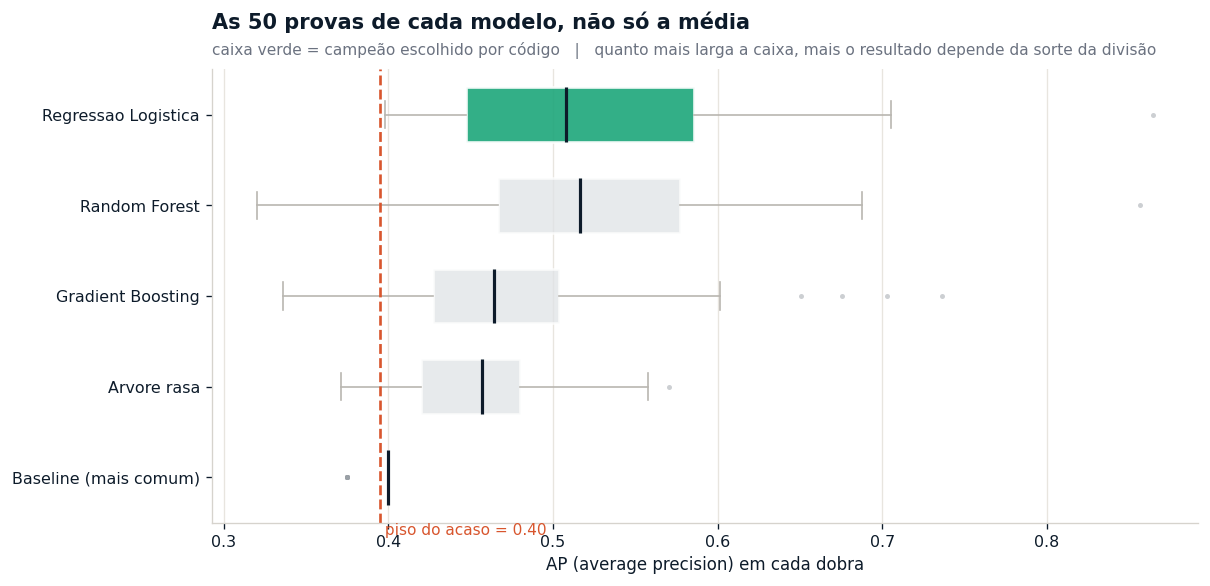

O campeao (Regressao Logistica) variou de AP 0.40 a 0.86 entre as 50 provas.
Essa largura E o resultado: com este universo, o desempenho depende de quais
alunas caem no treino. Reportar so a media seria esconder metade da verdade.


In [ ]:
# a distribuicao das 50 provas de cada modelo: a media sozinha esconde o balanco
ordem = tab.index[::-1]
fig, ax = plt.subplots(figsize=(10.2, 5.0))
cx = ax.boxplot([dobras[m] for m in ordem], vert=False, widths=0.6, patch_artist=True,
                medianprops=dict(color=TINTA, lw=1.9),
                whiskerprops=dict(color='#b9b6b0'), capprops=dict(color='#b9b6b0'),
                flierprops=dict(marker='o', markersize=3, markerfacecolor=CINZA,
                                markeredgecolor='none', alpha=0.5))
for caixa, m in zip(cx['boxes'], ordem):
    e = (m == campeao)
    caixa.set_facecolor(TEAL if e else '#dfe3e6')
    caixa.set_alpha(0.9 if e else 0.75)
    caixa.set_edgecolor('white'); caixa.set_linewidth(1.6)
ax.axvline(AP_ACASO, color=CORAL, lw=1.6, ls='--')
ax.text(AP_ACASO, 0.42, f' piso do acaso = {AP_ACASO:.2f}',
        color=CORAL, fontsize=9.2, va='center')
ax.set_yticklabels(ordem)
enfeita(ax, 'As 50 provas de cada modelo, não só a média',
        'caixa verde = campeão escolhido por código   |   quanto mais larga a caixa, mais o resultado depende da sorte da divisão',
        xlabel='AP (average precision) em cada dobra', eixo_grade='x')
plt.tight_layout(); plt.show()

pior, melhor_d = dobras[campeao].min(), dobras[campeao].max()
print(f"O campeao ({campeao}) variou de AP {pior:.2f} a {melhor_d:.2f} entre as 50 provas.")
print("Essa largura E o resultado: com este universo, o desempenho depende de quais")
print("alunas caem no treino. Reportar so a media seria esconder metade da verdade.")

**📖 Como ler:** três leituras, na ordem de importância.

**1. Todo mundo ganha do baseline em AP, e isso já era esperado**, porque o baseline nem ordena
risco. O que interessa é a distância até a **linha coral**: é ela, e não o baseline, que separa
"aprendeu alguma coisa" de "está sorteando".

**2. A largura das caixas é enorme.** Um mesmo modelo tira notas muito diferentes dependendo de quais
alunas caíram no treino. Essa é a assinatura visual de um universo pequeno, e é o motivo de o
notebook nunca reportar um número sozinho sem dizer o quanto ele balança.

**3. Se o modelo mais simples venceu, a hipótese da Estação 9 se confirmou.** Com poucos dados por
coluna, sofisticação não compra desempenho, compra decoreba. Registrar essa previsão antes do
resultado, e depois mostrar que ela se cumpriu, é argumento forte de banca.

---
# 🎛️ Estação 12: afinar o campeão e escolher o limiar pelo custo real

**🔎 O que vamos fazer:** duas coisas, nesta ordem.

1. **Afinar os hiperparâmetros do campeão** com busca em grade, sempre por validação cruzada no
   treino.
2. **Escolher o limiar de decisão**, que é a parte que quase todo TCC esquece e que, aqui, muda mais
   o resultado do que qualquer hiperparâmetro.

## Por que o limiar importa mais que o modelo

O modelo não devolve "evade" ou "não evade". Ele devolve uma **probabilidade**. Alguém precisa
decidir a partir de que número a Fly liga para a aluna. O padrão do scikit-learn é 0,5, e esse valor
é uma convenção sem nenhuma relação com este projeto.

Quem deveria escolher o limiar é a **operação**, não o algoritmo:

- Se a equipe consegue conversar com 20 alunas por turma, o limiar sai da capacidade da equipe.
- Se o objetivo é **não perder ninguém**, escolhe-se o limiar que entrega o recall desejado, e
  paga-se em falso positivo.

Neste notebook a meta é explícita: **alcançar pelo menos 80% de quem evadiu**, porque o custo de um
Falso Negativo (uma mulher perdendo a formação) é maior que o de um Falso Positivo (uma conversa
a mais). O limiar é escolhido **no treino**, por validação cruzada, e só depois aplicado no teste.

In [ ]:
GRADES = {
 'Regressao Logistica': [
     {'modelo__penalty': ['l2'], 'modelo__C': [0.01, 0.05, 0.1, 0.5, 1, 5],
      'modelo__solver': ['lbfgs']},
     {'modelo__penalty': ['l1'], 'modelo__C': [0.05, 0.1, 0.5, 1],
      'modelo__solver': ['liblinear']}],
 'Arvore rasa': {'modelo__max_depth': [2, 3, 4], 'modelo__min_samples_leaf': [5, 8, 12, 20]},
 'Random Forest': {'modelo__n_estimators': [300], 'modelo__max_depth': [3, 4, 5],
                   'modelo__min_samples_leaf': [3, 5, 8], 'modelo__max_features': ['sqrt', 0.5]},
 'Gradient Boosting': {'modelo__n_estimators': [100, 200], 'modelo__learning_rate': [0.03, 0.05, 0.1],
                       'modelo__max_depth': [1, 2, 3]},
 'Baseline (mais comum)': {'modelo__strategy': ['most_frequent', 'prior']},
}

fluxo_campeao = Pipeline([('preparo', preparo), ('modelo', modelos[campeao])])
busca = GridSearchCV(fluxo_campeao, GRADES[campeao],
                     cv=StratifiedKFold(5, shuffle=True, random_state=SEMENTE),
                     scoring='average_precision', n_jobs=-1, refit=True)
busca.fit(X_tr, y_tr)
melhor = busca.best_estimator_

print(f"CAMPEAO AFINADO: {campeao}")
for k, v in busca.best_params_.items():
    print(f"   {k.replace('modelo__',''):22s} = {v}")
print(f"\nAP na validacao cruzada: {busca.best_score_:.3f}   (piso do acaso: {AP_ACASO:.3f})")
print(f"Ganho sobre o acaso ....: {busca.best_score_ - AP_ACASO:+.3f}")

CAMPEAO AFINADO: Regressao Logistica
   C                      = 5
   penalty                = l2
   solver                 = lbfgs

AP na validacao cruzada: 0.521   (piso do acaso: 0.395)
Ganho sobre o acaso ....: +0.125


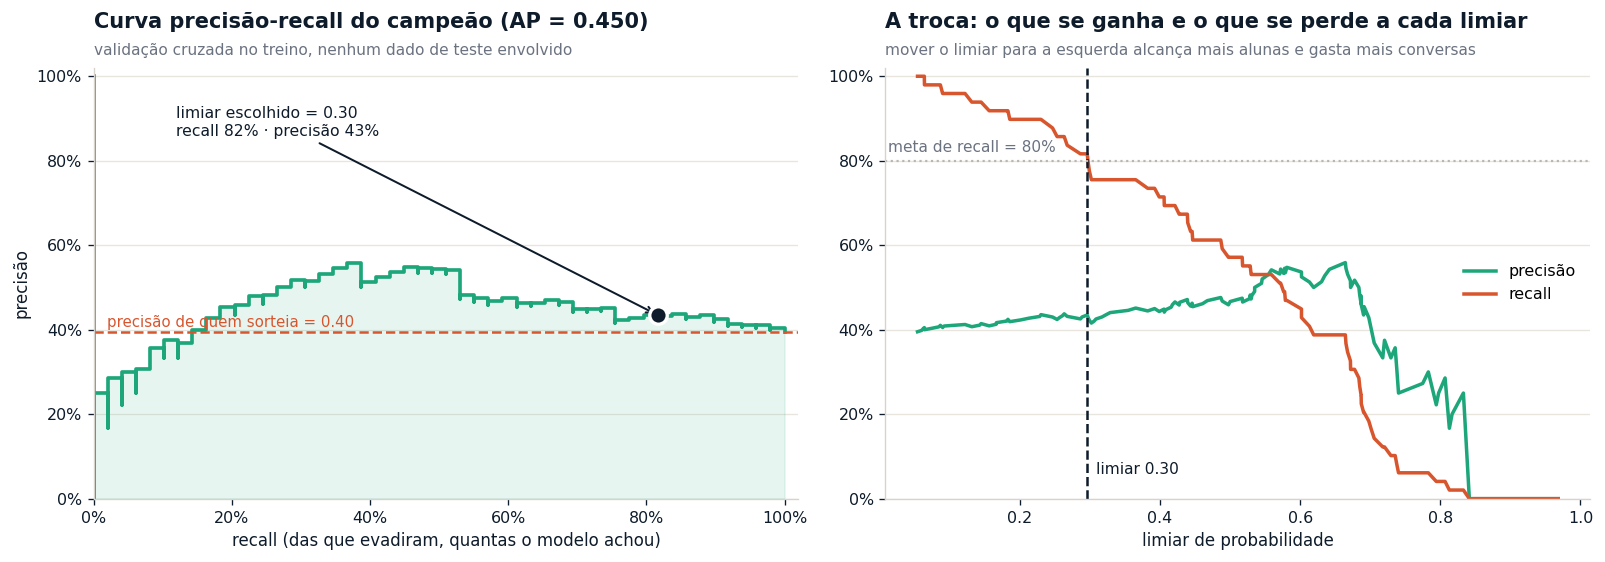

LIMIAR ESCOLHIDO: 0.296
   e o MAIOR limiar que ainda entrega recall >= 80% no treino,
   ou seja, o que alcanca a meta gastando o MENOR numero de conversas.
Nesse ponto: recall 82% | precisao 43%

TRADUCAO OPERACIONAL: para cada 10 alunas que a equipe da Fly for procurar,
cerca de 4 teriam evadido mesmo. As outras recebem uma conversa a mais.


In [ ]:
# probabilidades honestas: cada aluna do treino avaliada por um modelo que NAO a viu
prob_cv = cross_val_predict(melhor, X_tr, y_tr,
                            cv=StratifiedKFold(5, shuffle=True, random_state=SEMENTE),
                            method='predict_proba')[:, 1]

prec, rec, lim = precision_recall_curve(y_tr, prob_cv)
ap_cv = average_precision_score(y_tr, prob_cv)

META_RECALL = 0.80
ok = rec[:-1] >= META_RECALL
LIMIAR = float(lim[ok][-1]) if ok.any() else 0.5
i_esc = int(np.argmin(np.abs(lim - LIMIAR)))

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.8))

axes[0].step(rec, prec, where='post', color=TEAL, lw=2.2)
axes[0].fill_between(rec, prec, step='post', color=TEAL, alpha=0.10)
axes[0].axhline(AP_ACASO, color=CORAL, ls='--', lw=1.5)
axes[0].text(0.02, AP_ACASO + 0.012, f'precisão de quem sorteia = {AP_ACASO:.2f}',
             color=CORAL, fontsize=9)
axes[0].scatter([rec[i_esc]], [prec[i_esc]], s=110, color=TINTA, zorder=5,
                edgecolor='white', linewidth=2)
axes[0].annotate(f'limiar escolhido = {LIMIAR:.2f}\nrecall {rec[i_esc]:.0%} · precisão {prec[i_esc]:.0%}',
                 xy=(rec[i_esc], prec[i_esc]), xytext=(0.12, 0.86), fontsize=9.4, color=TINTA,
                 arrowprops=dict(arrowstyle='->', color=TINTA, lw=1.2))
axes[0].set_xlim(0, 1.02); axes[0].set_ylim(0, 1.02)
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
enfeita(axes[0], f'Curva precisão-recall do campeão (AP = {ap_cv:.3f})',
        'validação cruzada no treino, nenhum dado de teste envolvido',
        xlabel='recall (das que evadiram, quantas o modelo achou)',
        ylabel='precisão')

axes[1].plot(lim, prec[:-1], color=TEAL, lw=2.1, label='precisão')
axes[1].plot(lim, rec[:-1], color=CORAL, lw=2.1, label='recall')
axes[1].axvline(LIMIAR, color=TINTA, ls='--', lw=1.5)
axes[1].axhline(META_RECALL, color='#b9b6b0', ls=':', lw=1.3)
axes[1].text(LIMIAR + 0.012, 0.06, f'limiar {LIMIAR:.2f}', fontsize=9.2, color=TINTA)
axes[1].text(0.012, META_RECALL + 0.02, f'meta de recall = {META_RECALL:.0%}',
             fontsize=9.2, color='#6b7280')
axes[1].set_ylim(0, 1.02); axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
enfeita(axes[1], 'A troca: o que se ganha e o que se perde a cada limiar',
        'mover o limiar para a esquerda alcança mais alunas e gasta mais conversas',
        xlabel='limiar de probabilidade', ylabel='')
axes[1].legend(loc='center right')
plt.tight_layout(); plt.show()

print(f"LIMIAR ESCOLHIDO: {LIMIAR:.3f}")
print(f"   e o MAIOR limiar que ainda entrega recall >= {META_RECALL:.0%} no treino,")
print( "   ou seja, o que alcanca a meta gastando o MENOR numero de conversas.")
print(f"Nesse ponto: recall {rec[i_esc]:.0%} | precisao {prec[i_esc]:.0%}")
print(f"\nTRADUCAO OPERACIONAL: para cada 10 alunas que a equipe da Fly for procurar,")
print(f"cerca de {prec[i_esc]*10:.0f} teriam evadido mesmo. As outras recebem uma conversa a mais.")

**📖 Como ler:** o gráfico da esquerda tem uma linha coral que é o coração da avaliação. Ela marca a
precisão de quem **sorteia**. Se a curva verde passar rente a ela, o modelo não está ordenando risco.
Quanto mais alto a curva se mantém à medida que anda para a direita, mais o modelo consegue empurrar
quem evadiu para o topo da fila.

O gráfico da direita é o que se leva para a reunião com a Fly. Ele não fala de algoritmo, fala de
**escolha de política**: mover a linha tracejada para a esquerda alcança mais alunas e gasta mais
tempo da equipe. Não existe resposta técnica para onde colocar essa linha. Existe uma decisão da
instituição, e o notebook oferece a conta de cada opção.

Repare no que **não** fizemos: não olhamos o conjunto de teste nem uma vez para escolher esse limiar.
Se tivéssemos escolhido o limiar olhando o teste, o resultado final seria maquiado.

---
# 🔍 Estação 13: o diagnóstico do campeão

**🔎 O que vamos fazer:** agora sim, abrir o teste. Aplicamos o modelo afinado com o limiar escolhido
no treino e olhamos os quatro destinos, o que o modelo aprendeu e o quanto dá para confiar nas
probabilidades que ele devolve.

**Nada aqui volta atrás para mudar o modelo.** Todas as decisões já foram tomadas. E vale repetir o
tamanho: o teste tem cerca de 40 alunas, então **cada número desta estação é a leitura de uma
única divisão** e balança bastante. Os quatro gráficos que vêm a seguir trazem esse aviso no
subtítulo, de propósito.

In [ ]:
prob_te = melhor.predict_proba(X_te)[:, 1]
p_final = (prob_te >= LIMIAR).astype(int)

metricas_te = {
    'AP':       average_precision_score(y_te, prob_te),
    'recall':   recall_score(y_te, p_final, zero_division=0),
    'precisao': precision_score(y_te, p_final, zero_division=0),
    'F1':       f1_score(y_te, p_final, zero_division=0),
    'acuracia': accuracy_score(y_te, p_final),
}
print("=" * 60)
print(f"PROVA FINAL NO TESTE | {campeao} | limiar {LIMIAR:.2f}")
print("=" * 60)
for k, v in metricas_te.items():
    print(f"  {k:10s} {v:.3f}")
print(f"  {'AP do acaso':10s} {y_te.mean():.3f}   <- comparar a AP com ESTE numero")
print("=" * 60)
print(f"\nATENCAO AO TAMANHO: o teste tem {len(y_te)} alunas, {int(y_te.sum())} delas evadiram.")
print(f"Uma unica aluna a mais ou a menos muda o recall em {100/int(y_te.sum()):.0f} pontos percentuais.")
print("Por isso a decisao ja foi tomada na validacao cruzada. Isto aqui e conferencia, nao veredito.")

PROVA FINAL NO TESTE | Regressao Logistica | limiar 0.30
  AP         0.634
  recall     1.000
  precisao   0.548
  F1         0.708
  acuracia   0.667
  AP do acaso 0.405   <- comparar a AP com ESTE numero

ATENCAO AO TAMANHO: o teste tem 42 alunas, 17 delas evadiram.
Uma unica aluna a mais ou a menos muda o recall em 6 pontos percentuais.
Por isso a decisao ja foi tomada na validacao cruzada. Isto aqui e conferencia, nao veredito.


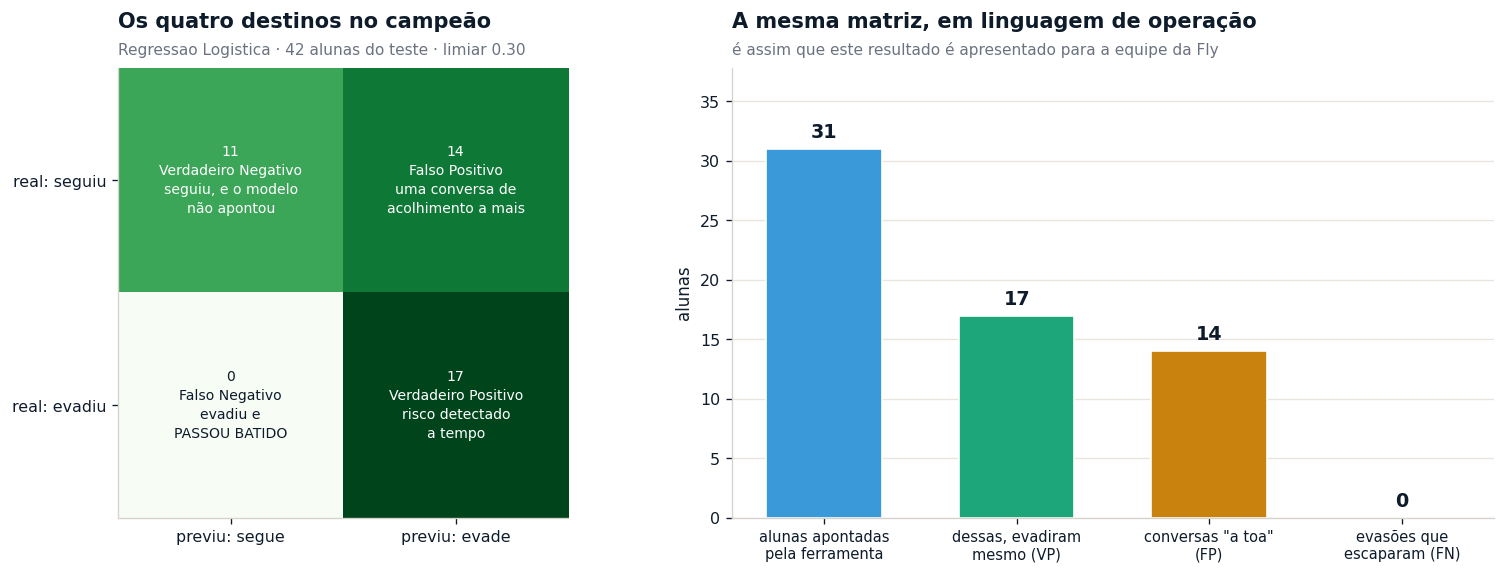

De 17 evasoes no teste, o modelo apontou 17 antes de acontecerem.
Para isso, a equipe conversaria com 31 alunas, das quais 14 nao iam sair.
E 0 evasao(oes) ainda assim passaria(m) batido(s).


In [ ]:
cm = confusion_matrix(y_te, p_final)
rot = [['Verdadeiro Negativo\nseguiu, e o modelo\nnão apontou',
        'Falso Positivo\numa conversa de\nacolhimento a mais'],
       ['Falso Negativo\nevadiu e\nPASSOU BATIDO',
        'Verdadeiro Positivo\nrisco detectado\na tempo']]

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.9), gridspec_kw={'width_ratios': [1, 1.05]})

im = axes[0].imshow(cm, cmap='Greens', vmin=0, vmax=cm.max())
axes[0].grid(False)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{cm[i,j]}\n{rot[i][j]}", ha='center', va='center', fontsize=8.4,
                     linespacing=1.45,
                     color='white' if cm[i, j] > cm.max()*0.55 else TINTA)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['previu: segue', 'previu: evade'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['real: seguiu', 'real: evadiu'])
enfeita(axes[0], 'Os quatro destinos no campeão',
        f'{campeao} · {len(y_te)} alunas do teste · limiar {LIMIAR:.2f}', eixo_grade='none')
axes[0].grid(False)

# a leitura operacional dos mesmos numeros
vn, fp, fn, vp = cm.ravel()
itens = ['alunas apontadas\npela ferramenta', 'dessas, evadiram\nmesmo (VP)',
         'conversas "a toa"\n(FP)', 'evasões que\nescaparam (FN)']
vals = [fp + vp, vp, fp, fn]
cores = [SKY, TEAL, AMBER, CORAL]
b = axes[1].bar(itens, vals, color=cores, edgecolor='white', width=0.6)
for bb, v in zip(b, vals):
    axes[1].text(bb.get_x()+bb.get_width()/2, v + max(vals)*0.03, str(v),
                 ha='center', fontsize=11.5, weight='bold', color=TINTA)
axes[1].set_ylim(0, max(vals)*1.22)
axes[1].tick_params(axis='x', labelsize=8.8)
enfeita(axes[1], 'A mesma matriz, em linguagem de operação',
        'é assim que este resultado é apresentado para a equipe da Fly', ylabel='alunas')
plt.tight_layout(); plt.show()

print(f"De {int(y_te.sum())} evasoes no teste, o modelo apontou {vp} antes de acontecerem.")
print(f"Para isso, a equipe conversaria com {fp+vp} alunas, das quais {fp} nao iam sair.")
print(f"E {fn} evasao(oes) ainda assim passaria(m) batido(s).")

### 13.2 O que o campeão aprendeu

**🔎 O que vamos fazer:** abrir o modelo. Usamos **importância por permutação**, que funciona para
qualquer modelo: embaralha-se uma variável de cada vez e mede-se o quanto a AP piora. Se piorar
muito, aquela variável estava sendo usada de verdade.

**Por que permutação e não a importância que vem de brinde no modelo:** as importâncias internas de
árvores favorecem variáveis com muitas categorias, e os coeficientes só existem em modelo linear.
A permutação mede a mesma coisa para todos, na métrica que a gente escolheu, e por isso é comparável.

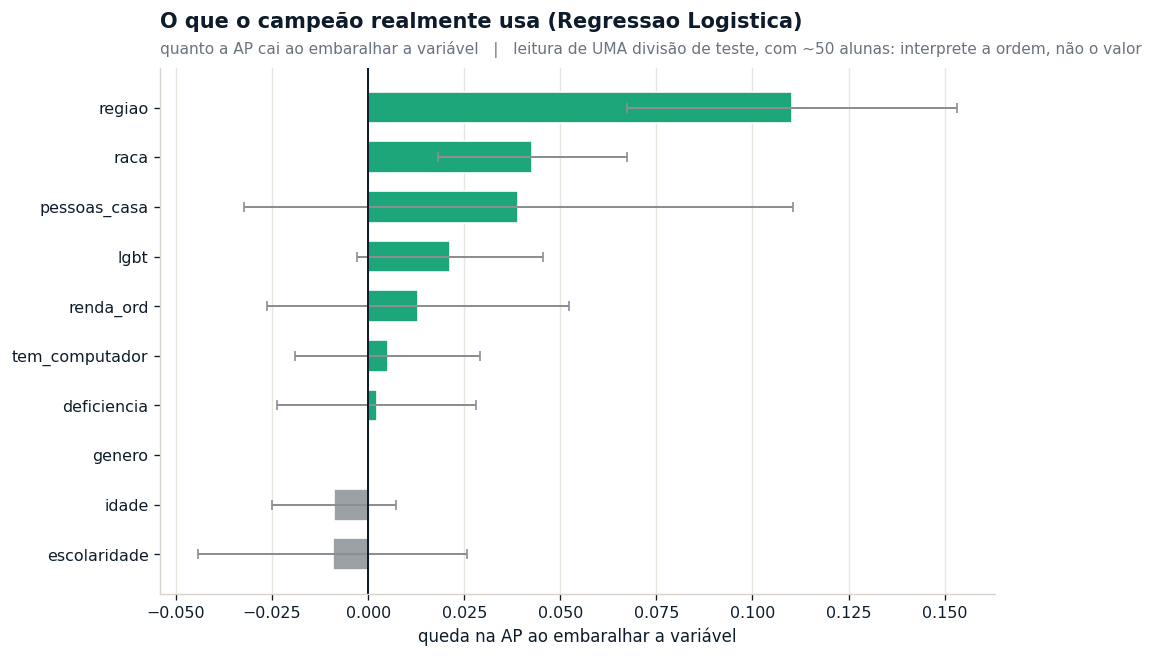

Variaveis cuja contribuicao e maior que a propria incerteza: ['raca', 'regiao']


In [ ]:
imp = permutation_importance(melhor, X_te, y_te, n_repeats=40,
                             random_state=SEMENTE, scoring='average_precision', n_jobs=-1)
ip = (pd.DataFrame({'variavel': VARIAVEIS, 'queda_media': imp.importances_mean,
                    'desvio': imp.importances_std})
      .sort_values('queda_media'))

fig, ax = plt.subplots(figsize=(9.4, 5.6))
cores = [TEAL if v > 0 else CINZA for v in ip['queda_media']]
ax.barh(ip['variavel'], ip['queda_media'], xerr=ip['desvio'], color=cores, edgecolor='white',
        height=0.64, error_kw=dict(ecolor='#8a8f94', elinewidth=1.2, capsize=3))
ax.axvline(0, color=TINTA, lw=1.2)
enfeita(ax, f'O que o campeão realmente usa ({campeao})',
        'quanto a AP cai ao embaralhar a variável   |   leitura de UMA divisão de teste, com ~50 alunas: interprete a ordem, não o valor',
        xlabel='queda na AP ao embaralhar a variável', eixo_grade='x')
plt.tight_layout(); plt.show()

uteis = ip[ip['queda_media'] - ip['desvio'] > 0]['variavel'].tolist()
print("Variaveis cuja contribuicao e maior que a propria incerteza:",
      uteis if uteis else "NENHUMA")
if not uteis:
    print("\nLeitura honesta: nenhuma variavel isolada se sustenta acima do ruido.")
    print("O pouco de sinal que existe esta espalhado, nao concentrado.")

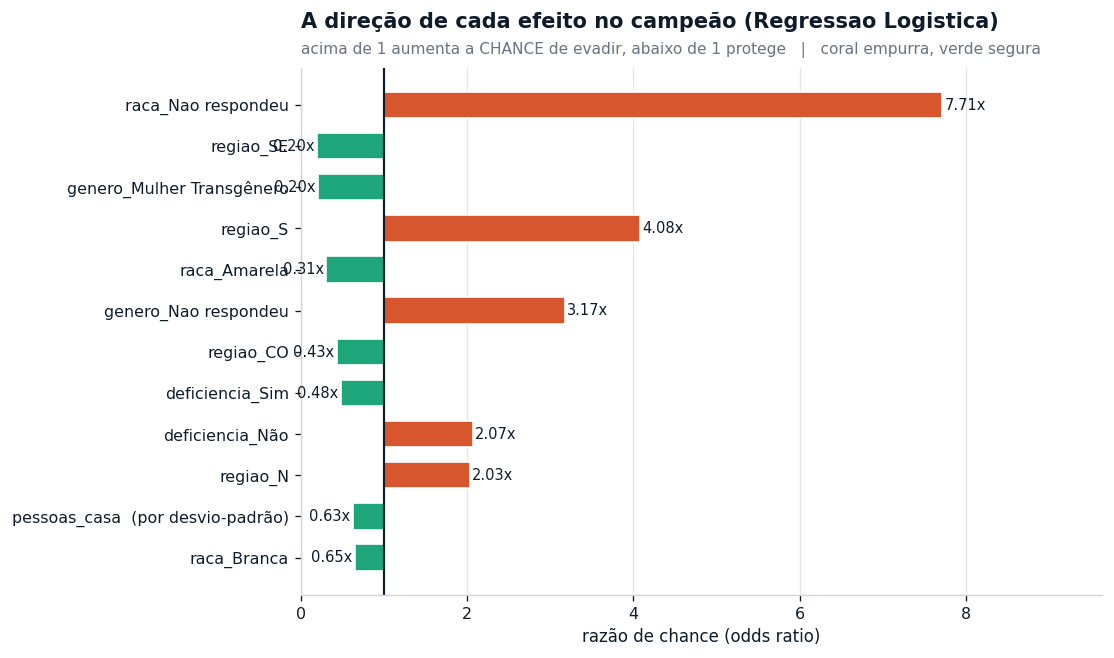

COMO LER, e aqui tem duas armadilhas:
  1. Isto e razao de CHANCE (odds), nao de probabilidade. 1,30x NAO significa
     '30% mais provavel'. Chance e p/(1-p), e com evasao perto de 1/3 a diferenca
     entre as duas leituras e grande. Diga 'aumenta a chance em 30%'.
  2. As variaveis numericas passaram por padronizacao, entao o valor delas e o
     efeito de UM DESVIO-PADRAO a mais (por isso o rotulo avisa). Nas categoricas,
     e o efeito de pertencer aquela categoria em vez da categoria de referencia.

E a ressalva que vale mais que as duas: com o sinal fraco medido na Estacao 7,
estes numeros indicam DIRECAO, nao magnitude confiavel. Nao virem politica sozinhos.

ATENCAO: com o sinal fraco medido na Estacao 7, estes numeros indicam DIRECAO,
nao magnitude confiavel. Nao virem politica publica sozinhos.


In [ ]:
# se o campeao for linear, da para ler a DIRECAO de cada efeito (o que a permutacao nao mostra)
estimador = melhor.named_steps['modelo']
if hasattr(estimador, 'coef_'):
    nomes = melhor.named_steps['preparo'].get_feature_names_out()
    nomes = [n.replace('num__', '').replace('cat__', '') for n in nomes]
    coef = pd.Series(estimador.coef_[0], index=nomes)
    top = coef.reindex(coef.abs().sort_values().index).tail(12)
    razao = np.exp(top)          # razao de chance: mais facil de explicar que log-odds
    # numerica foi padronizada, entao o efeito e por DESVIO-PADRAO, nao por "ter a caracteristica"
    eh_num = [n.split('_')[0] in [c.split('_')[0] for c in c_num] or n in c_num for n in top.index]
    rotulos = [f'{n}  (por desvio-padrão)' if e else n for n, e in zip(top.index, eh_num)]

    fig, ax = plt.subplots(figsize=(9.4, 5.6))
    ax.barh(rotulos, razao.values - 1,
            color=[CORAL if v > 1 else TEAL for v in razao.values],
            edgecolor='white', height=0.64, left=1)
    ax.axvline(1, color=TINTA, lw=1.3)
    for i, v in enumerate(razao.values):
        ax.text(v + (0.03 if v >= 1 else -0.03), i, f'{v:.2f}x',
                va='center', ha='left' if v >= 1 else 'right', fontsize=8.8, color=TINTA)
    ax.set_xlim(0, max(razao.max()*1.25, 1.6))
    enfeita(ax, f'A direção de cada efeito no campeão ({campeao})',
            'acima de 1 aumenta a CHANCE de evadir, abaixo de 1 protege   |   coral empurra, verde segura',
            xlabel='razão de chance (odds ratio)', eixo_grade='x')
    plt.tight_layout(); plt.show()
    print("COMO LER, e aqui tem duas armadilhas:")
    print("  1. Isto e razao de CHANCE (odds), nao de probabilidade. 1,30x NAO significa")
    print("     '30% mais provavel'. Chance e p/(1-p), e com evasao perto de 1/3 a diferenca")
    print("     entre as duas leituras e grande. Diga 'aumenta a chance em 30%'.")
    print("  2. As variaveis numericas passaram por padronizacao, entao o valor delas e o")
    print("     efeito de UM DESVIO-PADRAO a mais (por isso o rotulo avisa). Nas categoricas,")
    print("     e o efeito de pertencer aquela categoria em vez da categoria de referencia.")
    print()
    print("E a ressalva que vale mais que as duas: com o sinal fraco medido na Estacao 7,")
    print("estes numeros indicam DIRECAO, nao magnitude confiavel. Nao virem politica sozinhos.")
    print("\nATENCAO: com o sinal fraco medido na Estacao 7, estes numeros indicam DIRECAO,")
    print("nao magnitude confiavel. Nao virem politica publica sozinhos.")
else:
    print(f"O campeao ({campeao}) nao e linear, entao nao ha coeficiente para ler.")
    print("A leitura de direcao fica com a EDA da Estacao 7, e a de uso com a permutacao acima.")

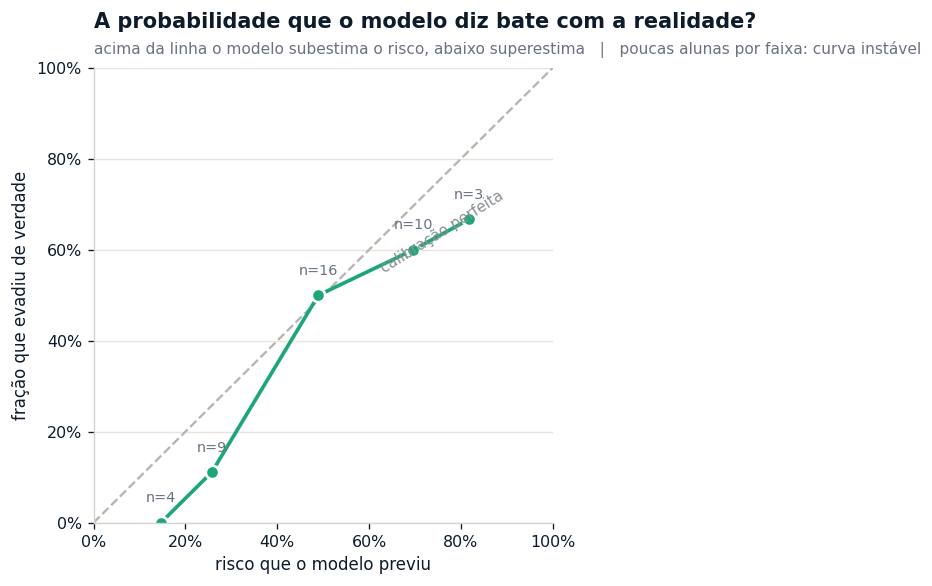

Brier score do modelo ......... 0.197
Brier de quem chuta a taxa da base (40% para todo mundo): 0.241
Quanto menor, melhor. Se o modelo nao ficar ABAIXO da segunda linha, as
probabilidades dele valem menos que repetir a taxa media para todas.

Por que isso importa neste projeto: se a ferramenta for usada para PRIORIZAR fila,
basta ordenar direito. Se alguem for dizer a uma aluna 'voce tem 70% de risco',
a probabilidade precisa ser calibrada, e com este n ela nao e.


In [ ]:
# calibracao: quando o modelo diz "40% de risco", 40% daquelas alunas evadem mesmo?
faixas = np.linspace(0, 1, 6)
centros, obs, tamanhos = [], [], []
for a, b in zip(faixas[:-1], faixas[1:]):
    m = (prob_te >= a) & (prob_te < b if b < 1 else prob_te <= 1)
    if m.sum() >= 3:
        centros.append(prob_te[m].mean()); obs.append(y_te.values[m].mean()); tamanhos.append(int(m.sum()))

fig, ax = plt.subplots(figsize=(6.6, 5.0))
ax.plot([0, 1], [0, 1], color='#b9b6b0', ls='--', lw=1.4)
ax.text(0.62, 0.55, 'calibração perfeita', rotation=32, fontsize=9, color='#8a8f94')
ax.plot(centros, obs, marker='o', color=TEAL, lw=2.2, markersize=8,
        markeredgecolor='white', markeredgewidth=1.6)
for x, y_, n in zip(centros, obs, tamanhos):
    ax.text(x, y_ + 0.045, f'n={n}', ha='center', fontsize=8.6, color='#6b7280')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0)); ax.yaxis.set_major_formatter(PercentFormatter(1.0))
enfeita(ax, 'A probabilidade que o modelo diz bate com a realidade?',
        'acima da linha o modelo subestima o risco, abaixo superestima   |   poucas alunas por faixa: curva instável',
        xlabel='risco que o modelo previu', ylabel='fração que evadiu de verdade')
plt.tight_layout(); plt.show()

brier_base = float(y_te.mean() * (1 - y_te.mean()))
print(f"Brier score do modelo ......... {brier_score_loss(y_te, prob_te):.3f}")
print(f"Brier de quem chuta a taxa da base ({y_te.mean():.0%} para todo mundo): {brier_base:.3f}")
print("Quanto menor, melhor. Se o modelo nao ficar ABAIXO da segunda linha, as")
print("probabilidades dele valem menos que repetir a taxa media para todas.")
print("\nPor que isso importa neste projeto: se a ferramenta for usada para PRIORIZAR fila,")
print("basta ordenar direito. Se alguem for dizer a uma aluna 'voce tem 70% de risco',")
print("a probabilidade precisa ser calibrada, e com este n ela nao e.")

**📖 Como ler:** a calibração responde a uma pergunta diferente da acurácia. Um modelo pode ordenar
bem e ainda assim errar o nível: dizer "70%" para um grupo em que só 40% evade. Com poucas alunas por
faixa (veja os `n=` no gráfico), essa curva é instável por construção.

A decisão de uso que sai daqui é direta e deve estar no TCC:

> A saída do modelo deve ser usada como **ordem de prioridade** ("procurar estas primeiro"),
> nunca como **número dito para a pessoa** ("você tem 70% de risco de evadir").

A segunda forma é imprecisa e, num contexto de mulheres em vulnerabilidade, é também cruel.

---
# 🧪 Estação 14: o teste de honestidade

**🔎 O que vamos fazer:** o teste mais importante do notebook, e o que quase nenhum TCC faz.

**A pergunta:** o resultado do campeão é melhor do que o que sairia de dados **sem nenhuma relação**
com a evasão?

**Como responder:** embaralhamos o alvo. Cada aluna fica com o desfecho de outra pessoa, aleatoriamente.
Por construção, não sobra nenhuma relação verdadeira entre perfil e evasão. Aí refazemos **a busca em
grade inteira** e anotamos a melhor AP. Repetimos isso muitas vezes.

**Por que refazer a busca inteira, e não só treinar de novo:** o modelo de verdade já é o vencedor de
uma disputa entre várias combinações de hiperparâmetros, e ser o melhor de várias tentativas já dá
uma vantagem por sorte. Se o acaso não passar pela mesma disputa, a comparação fica torta a favor do
modelo. Este é o detalhe que faz um teste de embaralhamento valer ou não valer, e é por isso que
esta célula demora alguns minutos.

Isso constrói a **distribuição do acaso**: a nota que um modelo tira quando não há nada para aprender.
Se a nota real cair dentro dessa distribuição, o que o modelo achou foi coincidência.

Cada rodada leva 1.0s. Vamos fazer 114 rodadas (~2.0 min).
Quanto mais rodadas, mais fina fica a medida do acaso. 40 ja resolve a leitura.

   20/114 embaralhamentos...
   40/114 embaralhamentos...
   60/114 embaralhamentos...
   80/114 embaralhamentos...
   100/114 embaralhamentos...


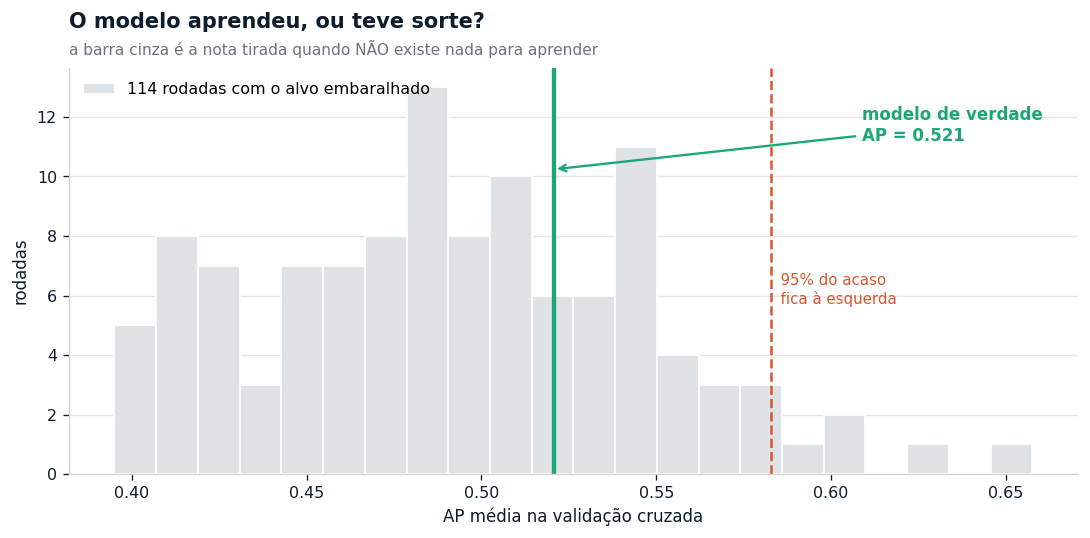


AP do modelo de verdade ......... 0.5206
AP media do acaso ............... 0.4930
AP do acaso no percentil 95 ..... 0.5829
p-valor empirico ................ 0.3217

REPARE: o acaso NAO tira zero. Ele tira em media 0.493, bem acima
do piso teorico de 0.395 que a Estacao 10 usou como referencia. Com universo
pequeno e busca em grade, sempre sobra alguma combinacao que se sai bem por sorte.
A regua de verdade e o percentil 95 medido aqui: 0.583.

VEREDITO: o desempenho do modelo esta DENTRO do que o acaso produz.
Com estas variaveis e este universo, nao da para afirmar que o modelo aprendeu.
Isso NAO e fracasso do grupo: e a medida honesta do que a base permite,
e e exatamente o argumento para a Estacao 16.


In [ ]:
# CUIDADO METODOLOGICO: o modelo de verdade passou por uma busca em grade, ou seja,
# ele ja ficou com a MELHOR combinacao entre varias. Se o acaso rodar sem essa busca,
# a comparacao e injusta a favor do modelo. Entao cada embaralhamento refaz a busca
# inteira. Isso deixa a celula lenta (alguns minutos), e a lentidao e o preco da honestidade.
import time

ap_real = float(busca.best_score_)      # o melhor da grade, no dado de verdade
rng = np.random.default_rng(SEMENTE)

def uma_rodada_do_acaso(semente_dobra):
    """Embaralha o alvo e refaz a busca em grade INTEIRA, igualzinho ao modelo real."""
    y_shuf = pd.Series(rng.permutation(y_tr.values), index=y_tr.index)
    b = GridSearchCV(fluxo_campeao, GRADES[campeao],
                     cv=StratifiedKFold(5, shuffle=True, random_state=semente_dobra),
                     scoring='average_precision', n_jobs=-1, refit=False)
    b.fit(X_tr, y_shuf)
    return float(b.best_score_)

# quantas rodadas cabem em ~2 minutos? medimos 3 e calculamos, para o notebook nunca travar.
ORCAMENTO_SEGUNDOS = 120
t0 = time.time()
ap_acaso = [uma_rodada_do_acaso(1000 + i) for i in range(3)]
por_rodada = (time.time() - t0) / 3
N_EMBARALHAMENTOS = int(np.clip(ORCAMENTO_SEGUNDOS / max(por_rodada, 1e-6), 40, 300))
print(f"Cada rodada leva {por_rodada:.1f}s. Vamos fazer {N_EMBARALHAMENTOS} rodadas "
      f"(~{por_rodada*N_EMBARALHAMENTOS/60:.1f} min).")
print("Quanto mais rodadas, mais fina fica a medida do acaso. 40 ja resolve a leitura.\n")

for i in range(3, N_EMBARALHAMENTOS):
    ap_acaso.append(uma_rodada_do_acaso(1000 + i))
    if (i + 1) % 20 == 0:
        print(f"   {i+1}/{N_EMBARALHAMENTOS} embaralhamentos...")
ap_acaso = np.array(ap_acaso)

p_emp = (np.sum(ap_acaso >= ap_real) + 1) / (N_EMBARALHAMENTOS + 1)

fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.hist(ap_acaso, bins=min(26, max(8, N_EMBARALHAMENTOS // 5)), color='#dfe3e6',
        edgecolor='white', linewidth=1.1,
        label=f'{N_EMBARALHAMENTOS} rodadas com o alvo embaralhado')
ax.axvline(ap_real, color=TEAL, lw=2.6)
ax.annotate(f'modelo de verdade\nAP = {ap_real:.3f}', xy=(ap_real, ax.get_ylim()[1]*0.75),
            xytext=(ap_real + (ap_acaso.std() or 0.01)*1.6, ax.get_ylim()[1]*0.82),
            fontsize=10, color=TEAL, weight='bold',
            arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.4))
ax.axvline(np.percentile(ap_acaso, 95), color=CORAL, ls='--', lw=1.5)
ax.text(np.percentile(ap_acaso, 95), ax.get_ylim()[1]*0.42,
        '  95% do acaso\n  fica à esquerda', fontsize=9, color=CORAL)
enfeita(ax, 'O modelo aprendeu, ou teve sorte?',
        'a barra cinza é a nota tirada quando NÃO existe nada para aprender',
        xlabel='AP média na validação cruzada', ylabel='rodadas')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

print(f"\nAP do modelo de verdade ......... {ap_real:.4f}")
print(f"AP media do acaso ............... {ap_acaso.mean():.4f}")
print(f"AP do acaso no percentil 95 ..... {np.percentile(ap_acaso, 95):.4f}")
print(f"p-valor empirico ................ {p_emp:.4f}")
print()
print(f"REPARE: o acaso NAO tira zero. Ele tira em media {ap_acaso.mean():.3f}, bem acima")
print(f"do piso teorico de {AP_ACASO:.3f} que a Estacao 10 usou como referencia. Com universo")
print("pequeno e busca em grade, sempre sobra alguma combinacao que se sai bem por sorte.")
print(f"A regua de verdade e o percentil 95 medido aqui: {np.percentile(ap_acaso, 95):.3f}.")
print()
if p_emp < 0.05:
    print("VEREDITO: o modelo tira nota melhor do que o acaso conseguiria.")
    print("Existe sinal real nos dados, mesmo que fraco. O ranqueamento de risco tem valor.")
else:
    print("VEREDITO: o desempenho do modelo esta DENTRO do que o acaso produz.")
    print("Com estas variaveis e este universo, nao da para afirmar que o modelo aprendeu.")
    print("Isso NAO e fracasso do grupo: e a medida honesta do que a base permite,")
    print("e e exatamente o argumento para a Estacao 16.")

**📖 Como ler:** este gráfico é o que transforma "o modelo deu 0,45, é bom ou ruim?" numa pergunta
respondível. A barra cinza é o **acaso medido neste conjunto de dados específico**, com estas
variáveis e este tamanho de amostra, não um número de livro.

Qualquer que seja o veredito, ele é uma conquista do trabalho:

- **Se a linha verde está fora da massa cinza:** existe sinal real, ainda que fraco, e a ferramenta
  de priorização se justifica com ressalvas.
- **Se ela está dentro:** o notebook demonstrou, com método, que o formulário de inscrição não
  carrega informação suficiente. Isso é um resultado negativo **bem medido**, e resultado negativo
  bem medido é ciência. O que não é ciência é apresentar um F1 de 0,60 sem nunca ter perguntado o
  que o acaso daria.

---
# 📦 Estação 15: o que sai disso na prática

**🔎 O que vamos fazer:** empacotar o resultado em três coisas que a Fly consegue usar: a lista de
prioridade, o modelo salvo e a ficha técnica que acompanha o modelo.

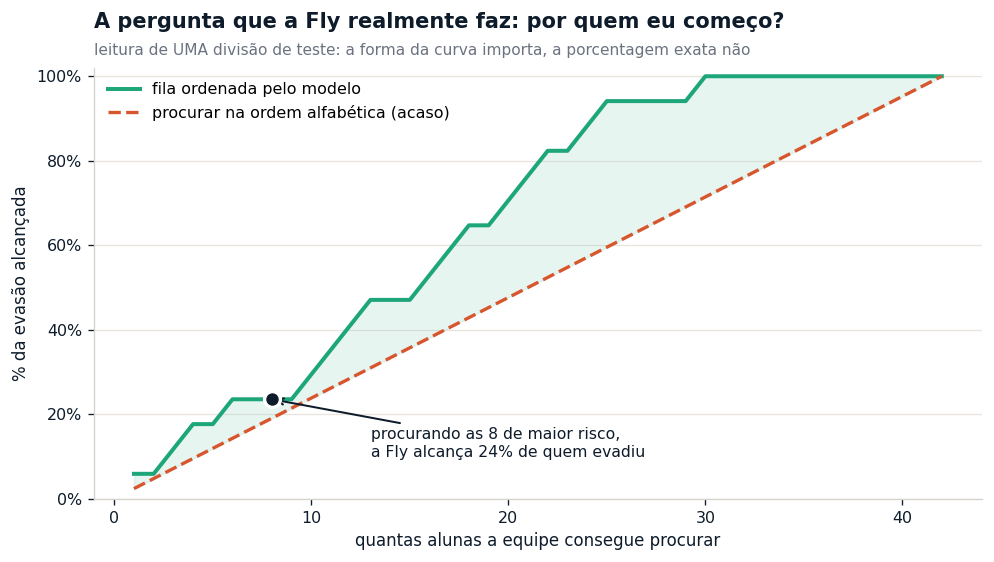

AVISO: os numeros desta curva vem de uma unica divisao de teste com poucas dezenas
de alunas. Leve para a Fly a FORMA da curva (o modelo separa ou nao separa),
nunca a porcentagem exata como promessa de desempenho.

As 10 primeiras da fila de prioridade (identificador anonimo):
 posicao   aluna_id turma    risco apontada  desfecho_real
       1  Aluna 516   T14 0.835658      sim         evadiu
       2  Aluna 763   T17 0.809861      sim concluiu/ativa
       3 Aluna 2151   T15 0.806945      sim         evadiu
       4 Aluna 1892   T15 0.778042      sim         evadiu
       5 Aluna 1879   T17 0.769318      sim concluiu/ativa
       6  Aluna 217   T15 0.732815      sim         evadiu
       7  Aluna 626   T17 0.691276      sim concluiu/ativa
       8  Aluna 381   T15 0.685505      sim concluiu/ativa
       9   Aluna 74   T14 0.684828      sim concluiu/ativa
      10 Aluna 2189   T17 0.675719      sim         evadiu


In [ ]:
lista = pd.DataFrame({
    'aluna_id': universo.loc[X_te.index, 'aluna_id'].values,
    'turma': universo.loc[X_te.index, 'turma_aba'].values,
    'risco': prob_te,
    'apontada': np.where(p_final == 1, 'sim', 'não'),
    'desfecho_real': np.where(y_te.values == 1, 'evadiu', 'concluiu/ativa'),
}).sort_values('risco', ascending=False).reset_index(drop=True)
lista['posicao'] = np.arange(1, len(lista) + 1)

# quanto a fila ordenada realmente ajuda, comparada com sortear a mesma quantidade
k = np.arange(1, len(lista) + 1)
acerto_modelo = np.cumsum(lista['desfecho_real'].eq('evadiu').values) / lista['desfecho_real'].eq('evadiu').sum()
acerto_acaso = k / len(lista)

fig, ax = plt.subplots(figsize=(8.4, 4.8))
ax.plot(k, acerto_modelo, color=TEAL, lw=2.4, label='fila ordenada pelo modelo')
ax.plot(k, acerto_acaso, color=CORAL, lw=2.0, ls='--', label='procurar na ordem alfabética (acaso)')
ax.fill_between(k, acerto_acaso, acerto_modelo, where=acerto_modelo >= acerto_acaso,
                color=TEAL, alpha=0.10)
n20 = max(int(0.2*len(lista)), 1)
ax.scatter([n20], [acerto_modelo[n20-1]], s=90, color=TINTA, zorder=5, edgecolor='white', linewidth=2)
ax.annotate(f'procurando as {n20} de maior risco,\na Fly alcança {acerto_modelo[n20-1]:.0%} de quem evadiu',
            xy=(n20, acerto_modelo[n20-1]), xytext=(n20 + len(lista)*0.12, max(acerto_modelo[n20-1]-0.28, 0.1)),
            fontsize=9.4, color=TINTA, arrowprops=dict(arrowstyle='->', color=TINTA, lw=1.2))
ax.set_ylim(0, 1.02); ax.yaxis.set_major_formatter(PercentFormatter(1.0))
enfeita(ax, 'A pergunta que a Fly realmente faz: por quem eu começo?',
        'leitura de UMA divisão de teste: a forma da curva importa, a porcentagem exata não',
        xlabel='quantas alunas a equipe consegue procurar',
        ylabel='% da evasão alcançada')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

print("AVISO: os numeros desta curva vem de uma unica divisao de teste com poucas dezenas")
print("de alunas. Leve para a Fly a FORMA da curva (o modelo separa ou nao separa),")
print("nunca a porcentagem exata como promessa de desempenho.\n")
print("As 10 primeiras da fila de prioridade (identificador anonimo):")
print(lista.head(10)[['posicao', 'aluna_id', 'turma', 'risco', 'apontada', 'desfecho_real']]
      .to_string(index=False))

**📖 Como ler:** este é o gráfico para o slide final da apresentação, porque ele responde à pergunta
da instituição em vez de à pergunta do algoritmo. A equipe da Fly nunca vai conseguir falar com todo
mundo. A pergunta dela é "com quem eu falo primeiro?", e a distância entre a linha verde e a
tracejada é **exatamente** o valor que a ferramenta entrega, medido em mulheres alcançadas.

Se as duas linhas estiverem coladas, a resposta honesta é: neste momento, ordenar pelo modelo é
equivalente a ordenar por ordem alfabética. E aí a entrega do TCC deixa de ser a ferramenta e passa
a ser a Estação 16.

In [ ]:
import joblib, json, datetime

joblib.dump({'modelo': melhor, 'limiar': LIMIAR, 'variaveis': VARIAVEIS},
            'dados/modelo_evasao_G4.joblib')

ficha = {
    'projeto': 'Evasao Fly - Grupo Ada Lovelace (G4) - Turma Fly diversiData',
    'data': str(datetime.date.today()),
    'pergunta': 'prever risco de evasao a partir do formulario de inscricao',
    'universo': int(len(universo)),
    'evasoes': int(universo['evadiu'].sum()),
    'taxa_evasao': round(float(universo['evadiu'].mean()), 3),
    'variaveis': VARIAVEIS,
    'modelo_campeao': campeao,
    'hiperparametros': {k.replace('modelo__', ''): str(v) for k, v in busca.best_params_.items()},
    'metrica_principal': 'average precision (AUC-PR)',
    'AP_validacao_cruzada': round(float(busca.best_score_), 3),
    'AP_do_acaso': round(float(AP_ACASO), 3),
    'p_valor_embaralhamento': round(float(p_emp), 4),
    'limiar_operacional': round(float(LIMIAR), 3),
    'metricas_no_teste': {k: round(float(v), 3) for k, v in metricas_te.items()},
    'uso_permitido': 'ordenar fila de prioridade para acolhimento',
    'uso_proibido': ['informar risco individual a aluna',
                     'decidir desligamento, bolsa ou selecao',
                     'conclusao sobre grupo com menos de 10 alunas'],
    'fonte_do_alvo': 'coluna Aprovadas da base de inscricoes (turmas 10 a 17); backlogs fora desta versao',
    'limitacoes': ['universo pequeno', 'alvo de uma fonte so: aprovada sem registro de formatura',
                   'turma confundida com periodo, regiao e forma de registro',
                   'desfecho existe so nas turmas 10 a 17',
                   'nenhuma variavel de engajamento durante o curso'],
}
with open('dados/ficha_do_modelo.json', 'w', encoding='utf-8') as f:
    json.dump(ficha, f, ensure_ascii=False, indent=2)

print("FICHA TECNICA DO MODELO (model card)\n")
print(json.dumps(ficha, ensure_ascii=False, indent=2))
print("\nArquivos gerados:")
for f_ in sorted(os.listdir('dados')):
    print(f"   dados/{f_:32s} {os.path.getsize(os.path.join('dados', f_))/1024:8.0f} KB")

FICHA TECNICA DO MODELO (model card)

{
  "projeto": "Evasao Fly - Grupo Ada Lovelace (G4) - Turma Fly diversiData",
  "data": "2026-09-08",
  "pergunta": "prever risco de evasao a partir do formulario de inscricao",
  "universo": 166,
  "evasoes": 66,
  "taxa_evasao": 0.398,
  "variaveis": [
    "idade",
    "escolaridade",
    "renda_ord",
    "pessoas_casa",
    "raca",
    "tem_computador",
    "regiao",
    "lgbt",
    "deficiencia",
    "genero"
  ],
  "modelo_campeao": "Regressao Logistica",
  "hiperparametros": {
    "C": "5",
    "penalty": "l2",
    "solver": "lbfgs"
  },
  "metrica_principal": "average precision (AUC-PR)",
  "AP_validacao_cruzada": 0.521,
  "AP_do_acaso": 0.395,
  "p_valor_embaralhamento": 0.3217,
  "limiar_operacional": 0.296,
  "metricas_no_teste": {
    "AP": 0.634,
    "recall": 1.0,
    "precisao": 0.548,
    "F1": 0.708,
    "acuracia": 0.667
  },
  "uso_permitido": "ordenar fila de prioridade para acolhimento",
  "uso_proibido": [
    "informar risco 

**📖 Como ler:** a ficha técnica (o *model card*) é o que faz este trabalho ser reutilizável e
auditável. Ela viaja junto com o arquivo `.joblib`, e traz os dois campos que quase nenhum modelo em
produção no Brasil tem escritos: **uso permitido** e **uso proibido**.

O campo `uso_proibido` não é decoração. Um modelo que ordena risco de evasão, se usado para decidir
desligamento ou corte de bolsa, transforma uma ferramenta de acolhimento em máquina de exclusão,
e faz isso justamente com as alunas mais vulneráveis, que são as que ele mais aponta. Escrever a
proibição no arquivo é o que impede que a próxima pessoa a abrir esse `.joblib` use sem saber.

---
# 🚀 Estação 16: o que fazer com este resultado

**🔎 O que vamos fazer:** transformar as limitações medidas em pedidos concretos, com prazo e
responsável. Esta é a estação que converte "o modelo ficou fraco" em plano de trabalho.

## Parte 1: o pedido de dados para a Fly (o que muda o jogo)

O notebook mediu que o gargalo não é o algoritmo, é o conjunto de variáveis. Então o pedido é
específico, e está em ordem de impacto esperado:

| # | O que pedir | Por que isso muda tudo | Esforço da Fly |
|---|---|---|---|
| 1 | **Presença e entrega de atividade, por semana e por aluna** | evasão é um processo que acontece durante o curso; é o preditor mais forte na literatura e não existe nesta base | médio: já existe em alguma planilha ou plataforma |
| 2 | **A MESMA chave `aluna_id`** na base de inscrições e nos backlogs | hoje só 21% cruzam, e por isso o backlog ficou fora desta versão; corrigir isso multiplica o universo de estudo sem coletar nada novo | baixo: é padronização |
| 3 | **Status de saída padronizado**, com data e motivo em lista fechada | separa "desistiu", "foi desligada" e "ainda cursando", que hoje viram o mesmo `evadiu = 1` | baixo |
| 4 | **A pergunta de mãe/cuidadora em TODOS os formulários** | é a hipótese mais promissora do grupo e a variável menos preenchida da base | baixo |
| 5 | **Backlogs com cabeçalho na primeira linha** | cada aba quebrada custou alunas e exigiu um detector inteiro | baixo |

## Parte 2: o que o grupo ainda pode fazer com os dados de hoje

1. **Incorporar os backlogs como segunda fonte** assim que a Fly padronizar chave e status
   (pedido 2, 3 e 5 acima). A Estação 6 já está pronta para receber a fonte B com uma célula a mais,
   e comparar as duas fontes vira uma **análise de sensibilidade** do alvo.
2. **Testar um alvo alternativo** em que "Aprovada sem registro de formatura" saia do `evadiu = 1` e
   vire categoria própria. Comparar os dois alvos mede o tamanho do problema em vez de só apontá-lo.
3. **Levar a curva da Estação 15 para a Fly** e perguntar quantas alunas a equipe consegue procurar
   por turma. Esse número define o limiar, e aí o limiar passa a ser uma decisão da instituição.

## Parte 3: a camada de IA generativa (o entregável que falta)

O modelo entrega uma **ordem de prioridade**. A camada de IA generativa entrega a **conversa**:
para cada aluna da fila, um roteiro curto de acolhimento que a equipe da Fly usa como ponto de
partida, escrito a partir das variáveis dela (sem números de risco, sem rótulo).

Três regras para essa camada, coerentes com tudo que este notebook mediu:

- ela **nunca** diz uma probabilidade para a aluna;
- ela **nunca** menciona raça, orientação ou deficiência como motivo de contato;
- ela sugere apoio concreto (empréstimo de equipamento, turma em outro horário, rede de cuidado),
  porque o objetivo do projeto é remover barreira, não classificar pessoa.

---
# ✅ O resumo do capítulo 2

**O que este notebook provou, em cinco frases:**

1. As 163 colunas eram uma dúzia de perguntas escritas de cinco jeitos, e a costura documentada na
   Estação 3 recuperou variáveis que sozinhas seriam inutilizáveis.
2. Só uma fração pequena das inscrições chega ao fim do funil com perfil **e** desfecho, e a maior
   perda é de padronização de chave, não de dado inexistente.
3. O alvo `evadiu` é uma mistura de duas definições, e a fonte majoritária confunde evasão com
   registro faltante. A taxa medida é um teto.
4. Nenhuma variável do formulário de inscrição tem associação mais que fraca com a evasão, e o teste
   de embaralhamento da Estação 14 diz, com método, o quanto disso é sinal e o quanto é acaso.
5. O gargalo é a ausência de dados de engajamento durante o curso. Este notebook não descobriu quem
   evade: descobriu **qual dado a Fly precisa passar a coletar** para que a pergunta tenha resposta.

**A frase do projeto:**

> Cada Falso Negativo é uma mulher que a gente poderia ter acolhido antes.
> O modelo existe para chegar ANTES da evasão, nunca para rotular ninguém. 💛